# 0. Title Block — AI Tools in Developers’ Workflows

**Project 44 · Technology, AI & the Digital World**

**Authors:** Mustari Ifthe (2023331050) and Md. Meheduz Zaman (2023331064)  
**Dataset:** Stack Overflow Developer Survey, 2023–2025  
**Source:** [Official survey archive](https://github.com/StackExchange/Survey/tree/main/packages/archive)  
**Date:** 3 October 2026

### Abstract

We examine how developers’ use of AI tools, sentiment and trust differed across three Stack Overflow survey releases. Schema harmonization, complete-case summaries, chi-square tests with Cramér’s V, and a Mann–Whitney comparison connect the descriptive and inferential questions. The files contain 203,812 responses. Among respondents who answered the AI-use question, current use rose from 44.38% in 2023 (n=87,973) to 78.50% in 2025 (n=33,720). Favorable sentiment fell from 76.28% (n=61,501) to 59.72% (n=33,467). Bangladesh respondents reported higher use in each year, although the valid samples were much smaller: 490, 324 and 194. Experience was associated with use within each release, with Cramér’s V of 0.1411, 0.1491 and 0.0843. These results describe the people who took part in the survey. Changing questions, missing answers and voluntary participation limit what we can infer about developers more broadly.

## 1. Problem Understanding

AI tools are increasingly common in software development, but using a tool does not necessarily mean trusting its output or feeling positive about it. We examine these measures separately and compare respondents across years, experience groups, roles and countries.

> **Main goal:** Describe how developers in the Stack Overflow surveys used and felt about AI tools from 2023 to 2025, and compare Bangladesh respondents with the global sample.

We define adoption as **current use of AI tools in the development process**. Respondents who only plan to use AI are not counted as current users.

### Descriptive and comparative questions (RQ1–RQ6)

1. How did current AI use change from 2023 to 2025?
2. How does use differ across experience groups within each year?
3. Which AI products or models were selected most often in each release?
4. How does sentiment vary by experience and year?
5. How does current use differ across the largest developer role groups?
6. How do Bangladesh respondents compare with the global sample?

### Inferential questions (RQ7–RQ8)

7. Is current AI use associated with experience band within each survey year?
8. In 2025, do current users and nonusers have different work-experience distributions?

The tests assess associations among respondents. They cannot establish that experience causes AI adoption or that AI use changes career outcomes.

## 2. Understanding the Dataset

- **Publisher:** Stack Overflow / Stack Exchange, Inc.
- **Collection method:** Voluntary online annual developer survey, promoted through Stack Overflow properties, email/newsletters and social channels; respondents self-select into participation. See the official methodology links below.
- **Time period:** 2023, 2024, and 2025 survey releases.
- **One row means:** One respondent’s released survey record for one survey year.
- **License/terms:** Survey database published under ODbL 1.0; individual cell contents under DbCL 1.0. Attribution and share-alike terms apply to adapted databases.

> **IMPORTANT CLARIFICATION — what this data is not:** It is not a probability sample, not a panel following the same people over time, not a census of developers, and not evidence that AI use causes productivity or career outcomes. The global sample includes Bangladesh respondents, so those groups overlap.

Question design changes across years. `AISelect` and `AISent` are available across all three releases, but detailed AI products differ: 2023 has separate AI search and AI developer product fields; 2024 combines those categories; 2025 asks about LLM models and adds agent/workflow topics. We keep those product summaries year-specific.

### Cross-year comparability at a glance

| Concept | 2023 source | 2024 source | 2025 source | Harmonized field / representation | Caveat |
|---|---|---|---|---|---|
| Current AI use | `AISelect` | `AISelect` | `AISelect` | `ai_use_binary`, `ai_use_h` | 2025 splits Yes by frequency; plans are noncurrent |
| Sentiment | `AISent` | `AISent` | `AISent` | `AISent`, `sentiment_score`, `favorable_sentiment` | All releases contain Indifferent and Unsure; routing can differ |
| Experience | `YearsCodePro` | `YearsCodePro` | `WorkExp` | `experience_input`, `experience_source`, `experience_years`, `experience_band` | Professional coding becomes professional work; not identical constructs |
| AI tools/models | `AISearchHaveWorkedWith`, `AIDevHaveWorkedWith` | `AISearchDevHaveWorkedWith` | `AIModelsHaveWorkedWith` | Year/question-specific indicators, `tool_count` | Separate products, combined products and models; counts are not a common time series |
| Main role | `DevType` | `DevType` | `DevType` | `DevType`, `role__…` | Single-choice main role in these schemas; lists change |
| Country | `Country` | `Country` | `Country` | `Country`; Bangladesh selection mask | Self-reported residence; Global includes Bangladesh |
| Trust in output | `AIBen` | `AIAcc` | `AIAcc` | `trust_accuracy_h` | Matching names alone would select the wrong 2023 construct |

The full code-backed AI schema crosswalk is built in Section 5 before cleaning or analysis. The source is the [official archive and licence notice](https://github.com/StackExchange/Survey/tree/main/packages/archive); release pages are listed in the references.

## 3. Importing Python Libraries

Install the packages in `requirements.txt` if they are not already available in your Python environment.

In [1]:
# Optional install cell (run in a notebook only if your environment permits package installation):
# %pip install -r requirements.txt


In [2]:
from pathlib import Path
import csv, sys, platform, json, hashlib, re, html
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import statsmodels
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from download_data import ensure_data

SEED = 42
np.random.seed(SEED)
csv.field_size_limit(10_000_000)
sns.set_theme(style='whitegrid')
ROOT = Path('.')
YEARS = [2023, 2024, 2025]
ALPHA = 0.05
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
def p_text(p):
    return '< 1e-300 (numerical underflow)' if p == 0 else f'{p:.4g}'
def interpret(text):
    display(Markdown(text))
def finish_figure(name):
    plt.tight_layout()
    plt.savefig(RESULTS / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()
    plt.close()
print('Python', sys.version.split()[0], '| Platform', platform.platform())
versions = {lib.__name__:lib.__version__ for lib in [np,pd,scipy,statsmodels,matplotlib,sns]}
print(versions)

Python 3.14.5 | Platform macOS-27.0-arm64-arm-64bit-Mach-O
{'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'statsmodels': '0.15.0', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'}


## 4. Data Collection and Import

The raw CSV copies are stored with this notebook at `data/raw/<year>/`. The primary source is the official Stack Overflow survey archive. The fallback official raw-file URL pattern is shown below; it can be used in a browser or with `curl` when network access is available. The files are large, so this notebook reads the saved raw copy and never overwrites it.

Example fallback: `https://media.githubusercontent.com/media/StackExchange/Survey/main/packages/archive/2025/results.csv` and corresponding `schema.csv`; use year 2023, 2024, or 2025.

In [3]:
# Show the acquisition code used by the fallback, then verify the local files.
display(Markdown('```python\n' + (ROOT / 'download_data.py').read_text() + '\n```'))
ensure_data(ROOT)

```python
"""Fetch missing official Stack Overflow CSVs and verify recorded sizes and hashes."""
from pathlib import Path
import hashlib
import json
import urllib.request


def ensure_data(root=Path('.')):
    """Keep existing verified files; download missing files atomically, failing on mismatch."""
    root = Path(root)
    manifest = json.loads((root / 'data' / 'manifest.json').read_text())
    for item in manifest:
        destination = root / item['relative_path']
        if not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            temporary = destination.with_suffix('.csv.part')
            print(f"Downloading {item['year']} {item['filename']} from the official archive")
            try:
                request = urllib.request.Request(item['source_url'], headers={'User-Agent': 'Project44-SurveyAnalysis'})
                with urllib.request.urlopen(request, timeout=120) as response, temporary.open('wb') as output:
                    while chunk := response.read(1024 * 1024):
                        output.write(chunk)
                if temporary.stat().st_size != item['bytes']:
                    raise ValueError('Downloaded byte size differs from the recorded release; review before using it.')
                with temporary.open('rb') as stream:
                    checksum = hashlib.file_digest(stream, 'sha256').hexdigest()
                if checksum != item['sha256']:
                    raise ValueError('Official archive content differs from the recorded release; review before using it.')
                temporary.replace(destination)
            except Exception as error:
                temporary.unlink(missing_ok=True)
                raise RuntimeError(f"Download/verification failed. Place {item['filename']} in {destination.parent}. "
                                   f"Official source: {item['source_url']}. Reason: {error}") from error
        if destination.stat().st_size != item['bytes']:
            raise ValueError(f'{destination} differs from the recorded byte size; do not use an incomplete or changed file.')
        with destination.open('rb') as stream:
            checksum = hashlib.file_digest(stream, 'sha256').hexdigest()
        if checksum != item['sha256']:
            raise ValueError(f'{destination} differs from the recorded SHA-256; do not run analysis on unverified replacements.')
    print('All six official CSVs match the byte sizes and SHA-256 hashes in data/manifest.json.')


if __name__ == '__main__':
    ensure_data(Path(__file__).resolve().parent)

```

All six official CSVs match the byte sizes and SHA-256 hashes in data/manifest.json.


### Load the saved survey files

`raw_df` is the concatenation of the official files with a release-year field. It is not cleaned or modified after import. All transformation work begins with `df = raw_df.copy()`.


In [4]:
raw_by_year, schema_by_year, file_summary = {}, {}, []
manifest = json.loads((ROOT/'data'/'manifest.json').read_text())
for item in manifest:
    file = ROOT/item['relative_path']
    assert file.stat().st_size == item['bytes'], f'File size differs from recorded release: {file}'
    with file.open('rb') as stream:
        checksum = hashlib.file_digest(stream, 'sha256').hexdigest()
    assert checksum == item['sha256'], f'File differs from recorded release: {file}'
for year in YEARS:
    folder = ROOT/'data'/'raw'/str(year)
    raw_by_year[year] = pd.read_csv(folder/'survey_results_public.csv', dtype='string', keep_default_na=False, low_memory=False)
    schema_by_year[year] = pd.read_csv(folder/'survey_results_schema.csv', dtype='string', keep_default_na=False, low_memory=False)
    r = raw_by_year[year]
    file_summary.append({'year':year, 'rows':len(r), 'columns':r.shape[1],
        'public_file':str(folder/'survey_results_public.csv'), 'schema_file':str(folder/'survey_results_schema.csv')})
file_summary = pd.DataFrame(file_summary)
display(file_summary)
raw_df = pd.concat([r.assign(SurveyYear=y) for y,r in raw_by_year.items()], ignore_index=True, sort=False)
raw_fingerprint = pd.util.hash_pandas_object(raw_df, index=True).sum()
df = raw_df.copy()
print('Combined raw_df:', raw_df.shape)
expected_checks=[]
for y,r in raw_by_year.items():
    countries=r['Country'].replace({'NA':pd.NA,'':pd.NA}).dropna()
    expected_checks.append({'year':y,'actual_rows':len(r),'actual_columns':r.shape[1],
        'countries_observed':countries.nunique(),'Bangladesh_country_n':int(countries.eq('Bangladesh').sum())})
display(pd.DataFrame(expected_checks))
interpret('**Release check.** The 2024 dimensions match 65,437 × 114; 2023 has 89,184 rows. '
          'The official 2025 profile displays 49,019 responses, whereas this official archive file has 49,191 × 172 and 177 observed countries. '
          'The published 62 questions refer to survey questions, not expanded CSV columns. '
          'Bangladesh country counts in the archive are 327 (2024) and 220 (2025), versus 325 and 219 on the official profile pages. '
          'We retain the verified archive records and do not guess a filter to force website totals. Exact URLs, bytes and SHA-256 hashes are in `data/manifest.json`.')

,year,rows,columns,public_file,schema_file
0,2023,89184,84,data/raw/2023/survey_results_public.csv,data/raw/2023/survey_results_schema.csv
1,2024,65437,114,data/raw/2024/survey_results_public.csv,data/raw/2024/survey_results_schema.csv
2,2025,49191,172,data/raw/2025/survey_results_public.csv,data/raw/2025/survey_results_schema.csv


Combined raw_df: (203812, 246)


,year,actual_rows,actual_columns,countries_observed,Bangladesh_country_n
0,2023,89184,84,185,490
1,2024,65437,114,185,327
2,2025,49191,172,177,220


**Release check.** The 2024 dimensions match 65,437 × 114; 2023 has 89,184 rows. The official 2025 profile displays 49,019 responses, whereas this official archive file has 49,191 × 172 and 177 observed countries. The published 62 questions refer to survey questions, not expanded CSV columns. Bangladesh country counts in the archive are 327 (2024) and 220 (2025), versus 325 and 219 on the official profile pages. We retain the verified archive records and do not guess a filter to force website totals. Exact URLs, bytes and SHA-256 hashes are in `data/manifest.json`.

## 5. Data Understanding

Before choosing variables, we inspect each file’s size, first and last rows, a sample drawn with seed 42, data types and summary statistics. We then read the schemas and build a crosswalk so that matching column names are not mistaken for matching questions.

In [5]:
print('shape:', raw_df.shape)
preview = ['SurveyYear','ResponseId','Country','Age','DevType','YearsCodePro','WorkExp','AISelect','AISent','AIAcc','AIBen','YearsCode']
# A compact preview avoids dumping long free-text fields; raw_df retains every source column.
display(raw_df[preview].head())
display(raw_df[preview].tail())
display(raw_df[preview].sample(n=5, random_state=42))
display(raw_df[preview].dtypes.astype(str).to_frame('dtype'))
display(raw_df.dtypes.astype(str).value_counts().rename_axis('dtype').to_frame('columns'))
raw_df.info()
display(raw_df[preview].describe(include='all').T)

shape: (203812, 246)


,SurveyYear,ResponseId,Country,Age,DevType,YearsCodePro,WorkExp,AISelect,AISent,AIAcc,AIBen,YearsCode
0,2023,1,NA,18-24 years old,NA,NA,NA,NA,NA,NA,NA,NA
1,2023,2,United States of America,25-34 years old,"Senior Executive (C-Suite, VP, etc.)",9,10,Yes,Indifferent,Other (please explain),Somewhat distrust,18
2,2023,3,United States of America,45-54 years old,"Developer, back-end",23,23,"No, and I don't plan to",NA,NA,NA,27
3,2023,4,United States of America,25-34 years old,"Developer, front-end",7,7,"No, and I don't plan to",NA,NA,NA,12
4,2023,5,Philippines,25-34 years old,"Developer, full-stack",4,6,Yes,Very favorable,Increase productivity;Greater efficiency;Speed...,Somewhat trust,6


,SurveyYear,ResponseId,Country,Age,DevType,YearsCodePro,WorkExp,AISelect,AISent,AIAcc,AIBen,YearsCode
203807,2025,49187,NA,18-24 years old,NA,<NA>,NA,NA,NA,NA,<NA>,NA
203808,2025,49188,NA,45-54 years old,NA,<NA>,25,NA,NA,NA,<NA>,NA
203809,2025,49189,Italy,35-44 years old,"Architect, software or solutions",<NA>,17,"Yes, I use AI tools monthly or infrequently",Favorable,Neither trust nor distrust,<NA>,31
203810,2025,49190,NA,25-34 years old,NA,<NA>,2,NA,NA,NA,<NA>,NA
203811,2025,49191,NA,18-24 years old,Student,<NA>,NA,NA,NA,NA,<NA>,6


,SurveyYear,ResponseId,Country,Age,DevType,YearsCodePro,WorkExp,AISelect,AISent,AIAcc,AIBen,YearsCode
97771,2024,8588,Canada,18-24 years old,Data scientist or machine learning specialist,5,6,Yes,Indifferent,Somewhat trust,Increase productivity;Greater efficiency,14
15962,2023,15963,Netherlands,35-44 years old,"Developer, back-end",10,10,"No, but I plan to soon",Favorable,NA,Somewhat trust,16
184930,2025,30310,Israel,18-24 years old,Cybersecurity or InfoSec professional,<NA>,3,"No, and I don't plan to",Unfavorable,Highly distrust,<NA>,8
119120,2024,29937,Italy,55-64 years old,"Developer, full-stack",25,NA,"No, and I don't plan to",NA,NA,NA,40
47278,2023,47279,United States of America,55-64 years old,"Developer, back-end",25,NA,Yes,Favorable,Other (please explain);Speed up learning,Neither trust nor distrust,25


,dtype
SurveyYear,int64
ResponseId,string
Country,string
Age,string
DevType,string
YearsCodePro,string
WorkExp,string
AISelect,string
AISent,string
AIAcc,string


,columns
dtype,
string,245
int64,1


<class 'pandas.DataFrame'>
RangeIndex: 203812 entries, 0 to 203811
Columns: 246 entries, ResponseId to AIOpen
dtypes: int64(1), string(245)
memory usage: 382.5 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SurveyYear,203812.0,NaN,NaN,NaN,2023.803775,0.800271,2023.0,2023.0,2024.0,2024.0,2025.0
ResponseId,203812,89184,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,203812,195,United States of America,36975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,203812,8,25-34 years old,73677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DevType,203812,50,"Developer, full-stack",56346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearsCodePro,154621,53,NA,36875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WorkExp,203812,74,NA,87682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AISelect,203812,7,Yes,76704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AISent,203812,7,Favorable,64341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIAcc,203812,66,NA,94619,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
MISSING = {'', 'NA', 'N/A', 'nan'}
def as_clean_strings(series):
    result=series.astype('string').str.strip()
    return result.mask(result.isin(MISSING))
def parse_experience(series):
    """Parse source years, using 0.5 for <1 and 51 for >50; keep failed parses missing."""
    numeric=series.replace({'Less than 1 year':'0.5','More than 50 years':'51'})
    return pd.to_numeric(numeric,errors='coerce')

def plain_question(text):
    return html.unescape(re.sub(r'<[^>]+>', ' ', str(text))).strip()

def response_schema_name(column, schema_names):
    matches=[name for name in schema_names if column==name or column.startswith(name)]
    return max(matches,key=len) if matches else None
cross=[]
core = ['AISelect','AISent','AIAcc','AIBen','AIComplex','AIThreat','AIToolCurrently Using']
for y in YEARS:
    sch=schema_by_year[y]
    names=sch.qname.dropna().astype(str).unique().tolist()
    ai_columns=[col for col in raw_by_year[y] if col.startswith(('AI','SOAI','AgentUses'))]
    for col in sorted(set(ai_columns+core)):
        present=col in raw_by_year[y]
        schema_name=response_schema_name(col,names)
        matched=sch[sch.qname.eq(schema_name)] if schema_name else pd.DataFrame()
        vals=as_clean_strings(raw_by_year[y][col]).dropna() if present else pd.Series(dtype='string')
        # Do not expose open-ended answers as answer options.
        free_text = (not matched.empty and matched['type'].eq('TE').any()) or col.endswith(('Entry','Write')) or col in {'SOAI','AIOpen'}
        if free_text: options='Open text; observed text is not a fixed option list.'
        elif vals.str.contains(';',regex=False).any():
            options='; '.join(sorted({t.strip() for v in vals for t in v.split(';') if t.strip()}))
        else: options='; '.join(sorted(vals.unique()))
        cross.append({'year':y,'response_column':col,'exists':present,'schema_name':schema_name,
                      'question':' | '.join(dict.fromkeys(plain_question(v) for v in matched.get('question',[]))),
                      'observed_options':options})
crosswalk=pd.DataFrame(cross)
with pd.option_context('display.max_rows',200,'display.max_colwidth',100):
    display(crosswalk)
crosswalk.to_csv(RESULTS/'schema_crosswalk.csv',index=False)
# The schemas contain question text/types, but not complete enumerated options.
# Observed CSV answers therefore supplement the schemas; unobserved allowed options cannot be inferred.
option_records=[]
for y in YEARS:
    for col in ['AISelect','AISent','AIAcc','AIBen']:
        if col in raw_by_year[y]:
            for answer,n in as_clean_strings(raw_by_year[y][col]).value_counts().items():
                option_records.append({'year':y,'column':col,'answer':answer,'n':int(n)})
answer_options=pd.DataFrame(option_records)
display(answer_options[answer_options.column.isin(['AISelect','AISent'])])

# Read the exact experience definitions from each schema, rather than equating names.
experience_questions=[]
for y in YEARS:
    field='WorkExp' if y==2025 else 'YearsCodePro'
    schema=schema_by_year[y]
    question=' | '.join(dict.fromkeys(plain_question(v) for v in schema.loc[schema.qname.eq(field),'question']))
    assert question
    experience_questions.append({'Year':y,'Source field':field,'Schema question':question})
display(pd.DataFrame(experience_questions))


,year,response_column,exists,schema_name,question,observed_options
0,2023,AIAcc,True,AIAcc,"For the AI tools you use as part of your development workflow, what are the MOST important benef...",Greater efficiency; Improve accuracy in coding; Improve collaboration; Increase productivity; Ot...
1,2023,AIBen,True,AIBen,How much do you trust the accuracy of the output from AI tools as part of your development workf...,Highly distrust; Highly trust; Neither trust nor distrust; Somewhat distrust; Somewhat trust
2,2023,AIComplex,False,NaN,,
3,2023,AIDevHaveWorkedWith,True,AIDev,"Which AI-powered developer tools did you use regularly over the past year, and which do you wa...",AWS CodeWhisperer; Adrenaline; Codeium; GitHub Copilot; Mintlify; Replit Ghostwriter; Rubber Duc...
4,2023,AIDevWantToWorkWith,True,AIDev,"Which AI-powered developer tools did you use regularly over the past year, and which do you wa...",AWS CodeWhisperer; Adrenaline; Codeium; GitHub Copilot; Mintlify; Replit Ghostwriter; Rubber Duc...
5,2023,AINextNeither different nor similar,True,AINext,"Thinking about how your workflow and process changes over time, how similar or different do you ...",Collaborating with teammates; Committing and reviewing code; Debugging and getting help; Deploym...
6,2023,AINextSomewhat different,True,AINext,"Thinking about how your workflow and process changes over time, how similar or different do you ...",Collaborating with teammates; Committing and reviewing code; Debugging and getting help; Deploym...
7,2023,AINextSomewhat similar,True,AINext,"Thinking about how your workflow and process changes over time, how similar or different do you ...",Collaborating with teammates; Committing and reviewing code; Debugging and getting help; Deploym...
8,2023,AINextVery different,True,AINext,"Thinking about how your workflow and process changes over time, how similar or different do you ...",Collaborating with teammates; Committing and reviewing code; Debugging and getting help; Deploym...
9,2023,AINextVery similar,True,AINext,"Thinking about how your workflow and process changes over time, how similar or different do you ...",Collaborating with teammates; Committing and reviewing code; Debugging and getting help; Deploym...


,year,column,answer,n
0,2023,AISelect,Yes,39042
1,2023,AISelect,"No, and I don't plan to",26221
2,2023,AISelect,"No, but I plan to soon",22710
3,2023,AISent,Favorable,29863
4,2023,AISent,Very favorable,17050
5,2023,AISent,Indifferent,10147
6,2023,AISent,Unsure,2471
7,2023,AISent,Unfavorable,1698
8,2023,AISent,Very unfavorable,272
74,2024,AISelect,Yes,37662


,Year,Source field,Schema question
0,2023,YearsCodePro,"NOT including education, how many years have y..."
1,2024,YearsCodePro,"NOT including education, how many years have y..."
2,2025,WorkExp,How many years of professional work experience...


### Key variables and comparability

| Column | Meaning | Comparability or limitation |
|---|---|---|
| `ResponseId` | Released respondent record ID | Unique within year; no individual tracking across years |
| `SurveyYear` | Source release | Added at import; 2023–2025 only |
| `AISelect` | Current use in development | 2025 splits affirmative responses by frequency |
| `AISent` | Stance toward AI tools | All three files contain `Indifferent` and `Unsure` |
| `AIAcc` | Benefits hoped for (2023); trust (2024–25) | Same column name changes meaning |
| `AIBen` | Trust (2023); benefits hoped for (2024) | Absent from 2025 |
| `trust_accuracy_h` | Harmonized trust item | 2023 `AIBen`; 2024–25 `AIAcc` |
| `YearsCodePro` | Professional **coding** experience | Available in 2023–24 |
| `WorkExp` | Professional **work** experience in 2025 | Broader wording; zero-experience answers instructed to be blank |
| `Country` | Where respondent lives | Self-reported; unavailable for some released records. |
| `Age` | Age band | Prefer-not-to-say excluded from age analysis |
| `DevType` | Main job/role | Single-choice in all three schemas; no semicolon role responses observed |
| `AIDevHaveWorkedWith` | 2023 AI development products | Separate from `AISearchHaveWorkedWith` |
| `AISearchDevHaveWorkedWith` | 2024 combined AI products | Different list/prompt from 2023 |
| `AIModelsHaveWorkedWith` | 2025 LLM models | Models rather than products; 2025-only |

**Experience choice.** Use within-year experience bands. Retain a source label (`professional coding` or `professional work`) and do not claim an exact experience trend across 2024–25. A blank 2025 answer cannot distinguish zero experience from nonresponse, so it stays missing.

**Sentiment choice.** Show the full distribution and report favorable share both with and without `Indifferent`. `Indifferent` appears in 2023, 2024 **and** 2025. We therefore retain it in the main comparison and show how the favorable share changes when it is excluded. Matching observed labels do not prove that routing or presentation stayed the same.

**Interpreting the survey.** A shift across years describes different responding samples. Voluntary participation, changes in question design and missing answers limit generalization to all developers.

**Understanding one survey row:** One row is one respondent in one release, and `ResponseId` must be combined with year. These are separate annual samples, so changes in percentages do not show the same people adopting AI. A blank AI answer is nonresponse, not evidence of nonuse.


### Student Checkpoint

- **What does one row represent?** One released respondent record from one survey year, not a tool use event.
- **Can ResponseId identify the same developer in different years?** No. `(SurveyYear, ResponseId)` identifies a released record; the survey provides no person-level cross-year linkage.
- **Why is missing AISelect not “No”?** An unanswered or routed item gives no evidence of nonuse. Only the explicit response labels determine current/noncurrent status.
- **What is the major comparability challenge?** Questions can change meaning even when their column names match. Experience changes from professional coding years to professional work years in 2025, and the tool questions change from products to models.
- **Are Bangladesh and Global separate samples?** No. Bangladesh respondents are part of Global; the comparison is descriptive and overlapping.
- **What does a zero tool indicator mean?** The question was answered, but that option was not selected. An entirely unanswered question produces NA choice indicators.

## 6. Data-Quality Assessment

We inspect exact duplicate rows, duplicate response IDs within each year, missing values and percentages, a missingness chart, and likely invalid values in key fields. Since the concatenated yearly files have different columns, a respondent ID is only checked within its source year.

In [7]:
quality_rows, missing_rows = [], []
for y,r in raw_by_year.items():
    ids=as_clean_strings(r.ResponseId)
    quality_rows.append({'year':y,'rows':len(r),'duplicate_full_rows':int(r.duplicated().sum()),
        'missing_ids':int(ids.isna().sum()),'duplicate_nonmissing_ids':int(ids.dropna().duplicated().sum()),
        'semicolon_role_rows':int(as_clean_strings(r.DevType).str.contains(';',regex=False,na=False).sum())})
    for col in r:
        miss=as_clean_strings(r[col]).isna()
        missing_rows.append({'year':y,'column':col,'missing_n':int(miss.sum()),'missing_pct':100*miss.mean()})
quality_table=pd.DataFrame(quality_rows)
missing_report=pd.DataFrame(missing_rows)
display(quality_table)
with pd.option_context('display.max_rows',500):
    display(missing_report.sort_values(['year','missing_pct'],ascending=[True,False]))
missing_report.to_csv(RESULTS/'missingness.csv',index=False)


# Assess validity before transforming the analysis copy, using the declared rules.
quality_summary_rows=[]
validity_rows=[]
for y,r in raw_by_year.items():
    q=quality_table[quality_table.year.eq(y)].iloc[0]
    source='WorkExp' if y==2025 else 'YearsCodePro'
    input_years=as_clean_strings(r[source])
    numeric_years=parse_experience(input_years)
    valid_years=numeric_years.between(0,70) & (numeric_years.mod(1).eq(0) | input_years.eq('Less than 1 year'))
    invalid_n=int((numeric_years.notna() & ~valid_years).sum())
    failed_n=int((input_years.notna() & numeric_years.isna()).sum())
    sentiment=as_clean_strings(r.AISent)
    unexpected_sentiment=set(sentiment.dropna())-{'Very unfavorable','Unfavorable','Indifferent','Favorable','Very favorable','Unsure'}
    assert not unexpected_sentiment, unexpected_sentiment
    use=as_clean_strings(r.AISelect)
    valid_use_labels=({'Yes', "No, and I don't plan to", 'No, but I plan to soon'} if y<2025 else
                     {'Yes, I use AI tools daily','Yes, I use AI tools weekly','Yes, I use AI tools monthly or infrequently',
                      "No, and I don't plan to",'No, but I plan to soon'})
    assert set(use.dropna())<=valid_use_labels
    validity_rows.append({'year':y,'experience_source':source,'invalid_range_or_fraction_n':invalid_n,
                          'failed_parse_n':failed_n,'unknown_AISelect_n':len(set(use.dropna())-valid_use_labels),
                          'unknown_AISent_n':len(unexpected_sentiment)})
    quality_summary_rows.extend([
        {'Quality dimension':'Completeness','Check':f'{y}: AISelect missing',
         'Result':f'{use.isna().sum():,}/{len(r):,} ({use.isna().mean()*100:.2f}%)',
         'Analytical consequence':'Use item-specific complete cases; never infer No from missing'},
        {'Quality dimension':'Uniqueness','Check':f'{y}: duplicate rows / IDs / missing IDs',
         'Result':f'{int(q.duplicate_full_rows)} / {int(q.duplicate_nonmissing_ids)} / {int(q.missing_ids)}',
         'Analytical consequence':'No record removals; IDs are unique only within release'},
        {'Quality dimension':'Validity','Check':f'{y}: {source} range/fraction / failed parse',
         'Result':f'{invalid_n} / {failed_n}',
         'Analytical consequence':'Set invalid derived experience to NA; preserve source and record'},
        {'Quality dimension':'Consistency','Check':f'{y}: source AI labels / semicolon role rows',
         'Result':f'All observed AI labels mapped / {int(q.semicolon_role_rows)}',
         'Analytical consequence':'Validate exact maps; DevType uses single-choice indicators'},
    ])
quality_summary_rows.append({'Quality dimension':'Cross-year schema differences','Check':'Experience, trust, product/model questions',
    'Result':'Different constructs/names documented in schema crosswalk',
    'Analytical consequence':'Use source labels and within-year comparisons; keep product/model blocks separate'})
quality_summary=pd.DataFrame(quality_summary_rows)
display(pd.DataFrame(validity_rows))
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(quality_summary)
quality_summary.to_csv(RESULTS/'quality_summary.csv',index=False)

,year,rows,duplicate_full_rows,missing_ids,duplicate_nonmissing_ids,semicolon_role_rows
0,2023,89184,0,0,0,0
1,2024,65437,0,0,0,0
2,2025,49191,0,0,0,0


,year,column,missing_n,missing_pct
61,2023,AINextVery similar,86563,97.061132
60,2023,AINextSomewhat similar,82946,93.005472
59,2023,AINextNeither different nor similar,82585,92.600691
58,2023,AINextVery different,76523,85.803507
44,2023,AIDevWantToWorkWith,69597,78.037540
57,2023,AIToolNot interested in Using,68115,76.375807
62,2023,AINextSomewhat different,65881,73.870874
43,2023,AIDevHaveWorkedWith,63280,70.954431
55,2023,AIToolInterested in Using,56401,63.241164
56,2023,AIToolCurrently Using,53047,59.480400


,year,experience_source,invalid_range_or_fraction_n,failed_parse_n,unknown_AISelect_n,unknown_AISent_n
0,2023,YearsCodePro,0,0,0,0
1,2024,YearsCodePro,0,0,0,0
2,2025,WorkExp,42,0,0,0


,Quality dimension,Check,Result,Analytical consequence
0,Completeness,2023: AISelect missing,"1,211/89,184 (1.36%)",Use item-specific complete cases; never infer No from missing
1,Uniqueness,2023: duplicate rows / IDs / missing IDs,0 / 0 / 0,No record removals; IDs are unique only within release
2,Validity,2023: YearsCodePro range/fraction / failed parse,0 / 0,Set invalid derived experience to NA; preserve source and record
3,Consistency,2023: source AI labels / semicolon role rows,All observed AI labels mapped / 0,Validate exact maps; DevType uses single-choice indicators
4,Completeness,2024: AISelect missing,"4,530/65,437 (6.92%)",Use item-specific complete cases; never infer No from missing
5,Uniqueness,2024: duplicate rows / IDs / missing IDs,0 / 0 / 0,No record removals; IDs are unique only within release
6,Validity,2024: YearsCodePro range/fraction / failed parse,0 / 0,Set invalid derived experience to NA; preserve source and record
7,Consistency,2024: source AI labels / semicolon role rows,All observed AI labels mapped / 0,Validate exact maps; DevType uses single-choice indicators
8,Completeness,2025: AISelect missing,"15,471/49,191 (31.45%)",Use item-specific complete cases; never infer No from missing
9,Uniqueness,2025: duplicate rows / IDs / missing IDs,0 / 0 / 0,No record removals; IDs are unique only within release


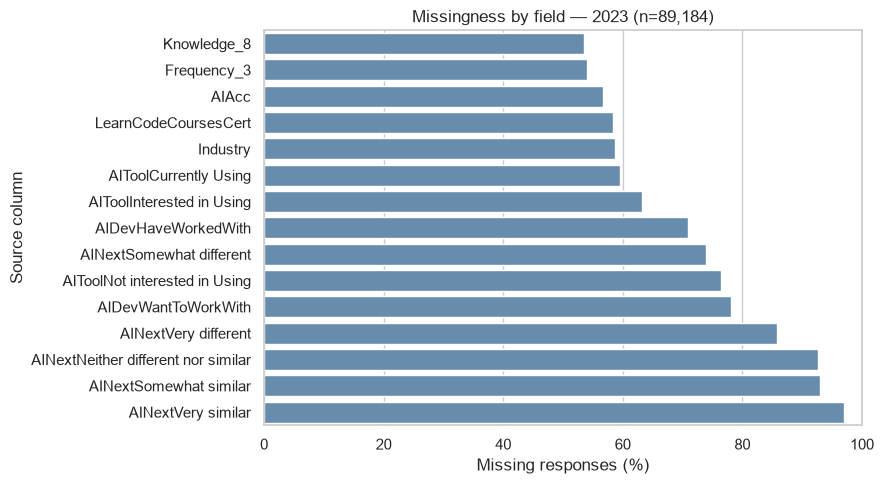

**Interpretation.** These bars show the fifteen highest missing percentages in 2023. In 2023, the displayed highest-missing field is `AINextVery similar` (97.1% missing). Optional and routed questions may explain these gaps; unanswered items are excluded only from analyses requiring them.

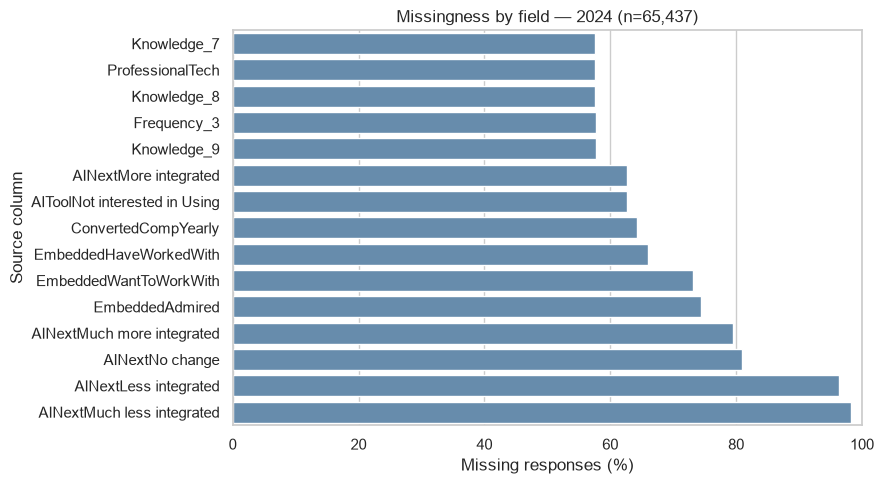

**Interpretation.** These bars show the fifteen highest missing percentages in 2024. In 2024, the displayed highest-missing field is `AINextMuch less integrated` (98.2% missing). Optional and routed questions may explain these gaps; unanswered items are excluded only from analyses requiring them.

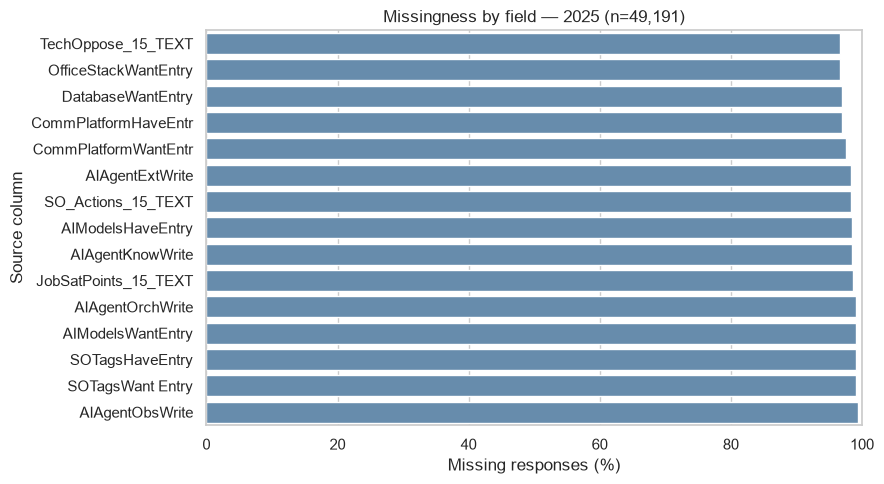

**Interpretation.** These bars show the fifteen highest missing percentages in 2025. In 2025, the displayed highest-missing field is `AIAgentObsWrite` (99.5% missing). Optional and routed questions may explain these gaps; unanswered items are excluded only from analyses requiring them.

In [8]:
for y in YEARS:
    m=missing_report[missing_report.year.eq(y)].nlargest(15,'missing_pct').sort_values('missing_pct')
    plt.figure(figsize=(9,5))
    ax=sns.barplot(data=m,x='missing_pct',y='column',color='#5b8db8')
    ax.set(title=f'Missingness by field — {y} (n={len(raw_by_year[y]):,})',xlabel='Missing responses (%)',ylabel='Source column',xlim=(0,100))
    finish_figure(f'missingness_{y}')
    interpret(f'**Interpretation.** These bars show the fifteen highest missing percentages in {y}. In {y}, the displayed highest-missing field is `{m.iloc[-1]["column"]}` '
              f'({m.iloc[-1]["missing_pct"]:.1f}% missing). Optional and routed questions may explain these gaps; '
              'unanswered items are excluded only from analyses requiring them.')

### What the missing values mean

Some survey questions are optional or shown only to particular respondents. A missing answer can therefore reflect a skipped question, survey routing or nonresponse. We exclude it from the relevant analysis rather than count it as “No.” Response IDs are checked within each release, since the same ID in two years does not identify the same person.


The quality table separates record-level problems from item-level problems: no duplicate records or IDs require removal, while missing AI answers reduce the denominators. The reported experience validity failures affect the derived experience field only. Differences in missingness can reflect question routing as well as respondent choices, so complete-case results may describe a selected subset.

## 7. Data Cleaning

### 7.1 Recognize missing answers

**Problem:** Blanks and missing-value labels can look like categories. **Action:** Convert `'', NA, N/A, nan` to missing values in the analysis copy. **Reason:** Unanswered questions must remain separate from explicit No. **Validation:** Compare source and derived missingness in Section 8 and verify the raw fingerprint.

### 7.2 Trim category labels

**Problem:** Whitespace can break exact matching. **Action:** Strip leading/trailing spaces with `as_clean_strings`. **Reason:** Match recorded options consistently without changing their meaning. **Validation:** Source-to-derived maps and unknown-category assertions must pass.

### 7.3 Check duplicate records and IDs

**Problem:** Duplicate records would count respondents twice. **Action:** Check exact rows and within-year IDs; remove only exact duplicates and stop on conflicting IDs. **Reason:** Each released record should contribute once within its year. **Validation:** Show before/after counts and assert nonmissing, unique `(SurveyYear, ResponseId)` pairs; no duplicates occur here.

### 7.4 Harmonize current AI use

**Problem:** 2025 splits affirmative responses by frequency. **Action:** Apply the explicit year-specific map shown in Section 8. **Reason:** Use one current-use definition, with plans counted as noncurrent. **Validation:** Assert that every observed option is mapped and that source missingness survives.

### 7.5 Match the trust questions

**Problem:** `AIAcc` and `AIBen` change meanings. **Action:** Select 2023 `AIBen` and later `AIAcc` for `trust_accuracy_h`. **Reason:** Compare reported trust rather than mixing trust with hoped-for benefits. **Validation:** Check the schema crosswalk, allowed trust labels and the source-to-derived match.

### 7.6 Parse experience and retain its source

**Problem:** Experience contains boundary phrases and its construct changes. **Action:** Parse <1 as 0.5 and >50 as 51; retain `experience_input` and `experience_source`. **Reason:** Enable within-year summaries while exposing the coding/work distinction. **Validation:** Inspect parse failures and validate each source-to-derived value in Section 8.

### 7.7 Prepare age and role categories

**Problem:** Age refusals are not age bands; role format must be established. **Action:** Keep source labels, omit refusals only from `age_h`, and use the observed single-choice role semantics. **Reason:** Avoid invented ages or overlapping role groups. **Validation:** Assert allowed ages and absence of semicolon roles; check role indicator sums and missingness.

### 7.8 Split multiple selections

**Problem:** A semicolon-separated answer contains multiple choices. **Action:** Create all existing year/question-specific indicators in Section 8. **Reason:** Selected=1, unselected among answerers=0, unanswered=NA. **Validation:** Compare every indicator with source membership and verify response-status flags and outside-year NA values.

### 7.9 Validate the experience range

**Problem:** Numeric values may fail the declared 0–70 range or whole-year rule. **Action:** Set invalid derived experience to NA, keeping the original value and record. **Reason:** Define a defensible analysis range; it is an analyst rule rather than proof that all excluded answers are impossible. **Validation:** Report failures, assert valid ranges and band boundaries, and retain the no-upper-cap sensitivity in Section 11.

`raw_df` remains unchanged. Cleaning counts below concern permanent record removals; the later complete-case table reports analysis-specific exclusions and does **not** describe further deletions from `df`. Harmonization and derived-field construction are shown immediately in Section 8.

In [9]:
rows_before=len(df)
source_string_cols=df.select_dtypes(include='string').columns
for col in source_string_cols: df[col]=as_clean_strings(df[col])
duplicate_full=int(df.duplicated().sum())
df=df.drop_duplicates().copy()
assert df.ResponseId.notna().all(), 'Missing ID: review rather than merging missing IDs.'
assert not df.duplicated(['SurveyYear','ResponseId']).any(), 'Conflicting ID: manual review required.'

cleaning_counts=pd.DataFrame([{'operation':'Exact-duplicate removal','before':rows_before,'after':len(df),
                              'removed':duplicate_full,'removed_pct':100*duplicate_full/rows_before}])
display(cleaning_counts)
assert pd.util.hash_pandas_object(raw_df,index=True).sum()==raw_fingerprint

,operation,before,after,removed,removed_pct
0,Exact-duplicate removal,203812,203812,0,0.0


## 8. Feature Engineering

We retain the existing transformations and show their construction below: inspect the source options in Section 5, harmonize the fields, inspect results, then validate before using them. The inventory documents each feature or indicator family, including diagnostic and export features; none is removed merely because it is absent from a main chart.

**Missing response ≠ No ≠ not selected ≠ zero.** Choice indicators are 0 only among question answerers. The separate `__answered` flags deliberately use 0 to record an unanswered source question within its year; they do not assert tool nonuse.

Experience bands retain the original boundaries `[0,1), [1,6), [6,11), [11,71)`. Professional coding experience in 2023–2024 and professional work experience in 2025 remain distinct constructs despite sharing a numeric field. Likewise, `tool_count` retains the original primary-question logic and is interpreted within year, because products and models are different selection lists.

The existing sentiment chain is retained. `sentiment_score` records ordering, without claiming equal psychological distance between categories; Unsure has no ordinal score. The added `favorable_sentiment` answers a different question: Favorable/Very favorable=1; every other valid sentiment answer, including Indifferent and Unsure=0; unanswered=NA. Zero means **not classified as favorable**, rather than unfavorable; it includes neutral and unsure responses.

In [10]:
USE_LABELS={
    2023:{'Yes':1, "No, and I don't plan to":0, 'No, but I plan to soon':0},
    2024:{'Yes':1, "No, and I don't plan to":0, 'No, but I plan to soon':0},
    2025:{'Yes, I use AI tools daily':1,'Yes, I use AI tools weekly':1,
          'Yes, I use AI tools monthly or infrequently':1,"No, and I don't plan to":0,'No, but I plan to soon':0}}
df['ai_use_binary']=np.nan
for y in YEARS:
    mask=df.SurveyYear.eq(y)
    unknown=set(df.loc[mask,'AISelect'].dropna())-set(USE_LABELS[y])
    assert not unknown, f'Unmapped AI use in {y}: {unknown}'
    df.loc[mask,'ai_use_binary']=df.loc[mask,'AISelect'].map(USE_LABELS[y])
df['ai_use_h']=df.ai_use_binary.map({0:'Not current user',1:'Current user'})
df['trust_accuracy_h']=df['AIAcc'].copy()
df.loc[df.SurveyYear.eq(2023),'trust_accuracy_h']=df.loc[df.SurveyYear.eq(2023),'AIBen']
trust_options={'Highly distrust','Somewhat distrust','Neither trust nor distrust','Somewhat trust','Highly trust'}
assert set(df.trust_accuracy_h.dropna())<=trust_options
age_order=['Under 18 years old','18-24 years old','25-34 years old','35-44 years old','45-54 years old','55-64 years old','65 years or older']
df['age_h']=df['Age'].where(df.Age.isin(age_order))
assert not df.DevType.str.contains(';',regex=False,na=False).any(), 'Recheck single-role interpretation.'

In [11]:
EXP_SOURCE={2023:'YearsCodePro',2024:'YearsCodePro',2025:'WorkExp'}
PRIMARY_TOOL={2023:'AIDevHaveWorkedWith',2024:'AISearchDevHaveWorkedWith',2025:'AIModelsHaveWorkedWith'}
TOOL_SOURCE={2023:['AISearchHaveWorkedWith','AIDevHaveWorkedWith'],2024:['AISearchDevHaveWorkedWith'],2025:['AIModelsHaveWorkedWith']}
df['experience_input']=pd.Series(pd.NA,index=df.index,dtype='string')
df['experience_source']=df.SurveyYear.map({2023:'Professional coding',2024:'Professional coding',2025:'Professional work'})
for y in YEARS:
    mask=df.SurveyYear.eq(y)
    df.loc[mask,'experience_input']=df.loc[mask,EXP_SOURCE[y]]
parsed=parse_experience(df.experience_input)
valid_fraction=parsed.mod(1).eq(0) | df.experience_input.eq('Less than 1 year')
valid_range=parsed.between(0,70)&valid_fraction
invalid_experience=parsed.notna()&~valid_range
failed_parse=df.experience_input.notna()&parsed.isna()
df['experience_years']=parsed.where(valid_range)
df['experience_band']=pd.cut(df.experience_years,bins=[0,1,6,11,71],right=False,labels=['<1 year','1–5 years','6–10 years','11+ years'])
sentiment_order=['Very unfavorable','Unfavorable','Indifferent','Favorable','Very favorable','Unsure']
sentiment_map={'Very unfavorable':1,'Unfavorable':2,'Indifferent':3,'Favorable':4,'Very favorable':5}
assert set(df.AISent.dropna())<=set(sentiment_order)
df['sentiment_score']=df.AISent.map(sentiment_map)
# Retain Indifferent and Unsure as valid denominator responses.
df['favorable_sentiment']=pd.Series(pd.NA,index=df.index,dtype='Int8')
answered_sentiment=df.AISent.notna()
df.loc[answered_sentiment,'favorable_sentiment']=df.loc[answered_sentiment,'AISent'].isin(['Favorable','Very favorable']).astype('Int8')
display(df.groupby('SurveyYear',observed=True).experience_band.value_counts(dropna=False).rename('n').to_frame())
display(pd.crosstab(df.AISent,df.favorable_sentiment))
invalid_table=pd.DataFrame([{'year':y,'failed_parse':int((failed_parse&df.SurveyYear.eq(y)).sum()),
    'experience_excluded_by_range_or_fraction':int((invalid_experience&df.SurveyYear.eq(y)).sum()),
    'experience_min':df.loc[df.SurveyYear.eq(y),'experience_years'].min(),
    'experience_max':df.loc[df.SurveyYear.eq(y),'experience_years'].max()} for y in YEARS])
display(invalid_table)
invalid_table.to_csv(RESULTS/'invalid_values.csv',index=False)

n
SurveyYear experience_band       
2023       11+ years        26753
           nan              23048
           1–5 years        20200
           6–10 years       17347
           <1 year           1836
2024       11+ years        18460
           1–5 years        17641
           nan              13827
           6–10 years       12653
           <1 year           2856
2025       11+ years        20994
           1–5 years        12203
           6–10 years        9654
           nan               6340
           <1 year              0

favorable_sentiment,0,1
AISent,,
Favorable,0,64341
Indifferent,24591,0
Unfavorable,7700,0
Unsure,4587,0
Very favorable,0,35575
Very unfavorable,4047,0


,year,failed_parse,experience_excluded_by_range_or_fraction,experience_min,experience_max
0,2023,0,0,0.5,51.0
1,2024,0,0,0.5,51.0
2,2025,0,42,1.0,70.0


In [12]:
def make_indicators(series,prefix):
    """Split semicolon choices into nullable indicators; skipped questions yield missing for every choice."""
    values=as_clean_strings(series)
    answered=values.notna()
    # get_dummies emits zeros for missing; mask them immediately, before any calculation/export.
    flags=values.str.get_dummies(sep=';').astype('Int8')
    flags.columns=[f'{prefix}__{str(c).strip()}' for c in flags]
    flags.loc[~answered,:]=pd.NA
    flags[f'{prefix}__answered']=answered.astype('Int8')
    assert flags.loc[~answered,flags.columns[:-1]].isna().all().all()
    return flags
role_flags=make_indicators(df.DevType,'role')
# Each question receives its own indicators. Never treat a skipped developer question as
# an unselected product merely because the respondent answered an AI search question.
tool_blocks={}
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    for source in TOOL_SOURCE[y]:
        tool_blocks[y,source]=make_indicators(part[source],f'tool_{y}_{source}')
df['tool_count']=np.nan
for y in YEARS:
    mask=df.SurveyYear.eq(y); values=df.loc[mask,PRIMARY_TOOL[y]]
    df.loc[mask,'tool_count']=values.map(lambda v:len(set(str(v).split(';'))) if pd.notna(v) else np.nan)
cc_rows=[]
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    for label,cols in {'Adoption':['ai_use_binary'],'Experience use':['experience_years','ai_use_binary'],
                      'Experience sentiment':['experience_years','AISent'],
                      'Age use':['age_h','ai_use_binary'],'Country use':['Country','ai_use_binary']}.items():
        after=len(part.dropna(subset=cols))
        cc_rows.append({'year':y,'analysis':label,'before':len(part),'after':after,'excluded':len(part)-after,'excluded_pct':100*(len(part)-after)/len(part)})
complete_case_counts=pd.DataFrame(cc_rows)
display(complete_case_counts)
complete_case_counts.to_csv(RESULTS/'complete_case_counts.csv',index=False)

,year,analysis,before,after,excluded,excluded_pct
0,2023,Adoption,89184,87973,1211,1.357867
1,2023,Experience use,89184,66136,23048,25.843201
2,2023,Experience sentiment,89184,45395,43789,49.099614
3,2023,Age use,89184,87644,1540,1.726767
4,2023,Country use,89184,87973,1211,1.357867
5,2024,Adoption,65437,60907,4530,6.922689
6,2024,Experience use,65437,50298,15139,23.135229
7,2024,Experience sentiment,65437,37968,27469,41.977780
8,2024,Age use,65437,60630,4807,7.345997
9,2024,Country use,65437,58443,6994,10.688143


In [13]:
tool_indicator_n=sum(len(block.columns)-1 for block in tool_blocks.values())
role_indicator_n=len(role_flags.columns)-1
print(f'Retained {tool_indicator_n} tool/model choice indicators, {role_indicator_n} main-role choice indicators, '
      f'and {len(tool_blocks)+1} response-status flags.')
inventory_rows=[
 ['SurveyYear','Source release','Assign year during concatenation',str(df.SurveyYear.dtype),'Stratify annual samples','Always available','No cross-year person linkage','All year-specific analyses; exports'],
 ['ai_use_binary / ai_use_h','AISelect','Exact year map: current=1, noncurrent=0; label binary status',str(df.ai_use_binary.dtype)+' / '+str(df.ai_use_h.dtype),'RQ1–2, RQ5–8: consistent current-use measure','Unanswered stays NA','Frequency lost; plans are noncurrent','§9 use charts; §10 correlation; §11 tests; export'],
 ['trust_accuracy_h','AIBen (2023); AIAcc (2024–25)','Copy year-specific trust field',str(df.trust_accuracy_h.dtype),'Supporting trust analysis','Source NA retained','Self-reported trust, not measured accuracy','§9 trust by experience; §12 findings; export'],
 ['age_h / ordered age view','Age','Keep seven valid bands; ordered categorical view in age chart',str(df.age_h.dtype),'Supporting age comparison','Refusal and unanswered become NA in age_h; raw Age retained','Broad bands; exclusions may select respondents','§9 age/use charts; complete-case diagnostics'],
 ['experience_input','YearsCodePro (2023–24); WorkExp (2025)','Select source field by year',str(df.experience_input.dtype),'Preserve original experience answer','Source NA retained','2025 blanks mix zero experience and nonresponse','Parsing, validity and sensitivity; export'],
 ['experience_source','SurveyYear / schema','Professional coding (2023–24); Professional work (2025)',str(df.experience_source.dtype),'Expose the construct difference','Available for every retained record','Labels do not make constructs identical','Chart titles; grouped tables; export'],
 ['experience_years','experience_input','Numeric; <1=0.5; >50=51; valid whole years in 0–70',str(df.experience_years.dtype),'Within-year experience summaries','Source NA, failed parses and invalid values -> NA','Boundary approximations and declared range','§9 distributions; §10 correlation; §11 tests; export'],
 ['experience_band','experience_years','pd.cut: [0,1), [1,6), [6,11), [11,71)',str(df.experience_band.dtype),'RQ2, RQ4, RQ7: grouped experience','NA experience -> NA band','Discards within-band variation; coding/work differs','§9 100% stacks; §11 chi-square; export'],
 ['AISent (harmonized labels)','AISent in all three releases','Trim/missing normalization; retain all six observed categories',str(df.AISent.dtype),'RQ4: full sentiment distribution','Source NA retained','Matching observed labels do not prove identical routing','§9 sentiment stacks; score/binary derivation; export'],
 ['sentiment_score','AISent','Very unfavorable=1, Unfavorable=2, Indifferent=3, Favorable=4, Very favorable=5',str(df.sentiment_score.dtype),'Ordinal association','Unanswered and Unsure -> NA','Ordering does not establish equal distances','§10 Spearman heatmap/pairs; export'],
 ['favorable_sentiment','AISent','Favorable/Very favorable=1; other valid categories=0',str(df.favorable_sentiment.dtype),'RQ4: favorable share with all valid answers','Only unanswered -> NA; Indifferent/Unsure remain 0','Zero means not classified favorable, not unfavorable; intensity is lost','§9 sentiment summary; §12 findings; export'],
 [f'Tool/model choice indicators ({tool_indicator_n})','Four year/question blocks in TOOL_SOURCE','Semicolon token membership: selected=1; unselected=0','Int8','RQ3: full selection features','Unanswered question or outside source year -> NA','2023 separate search/developer products; 2024 combined products; 2025 models','§9 top-N/mention stacks; export; independent audit'],
 ['Tool response-status flags (4)','Each TOOL_SOURCE question','__answered: source nonmissing=1; unanswered=0','Int8','Distinguish skip from explicit nonselection','Outside source year -> NA; within-year 0 means unanswered','Does not measure whether any AI is used','Indicator validation; export; audit'],
 ['tool_count','PRIMARY_TOOL: 2023 AIDev; 2024 combined; 2025 models','Count distinct source tokens, equal to primary choice-indicator sum',str(df.tool_count.dtype),'Breadth of reported primary-question selections','Unanswered primary question -> NA','Not an identical longitudinal measure','§10 2025 heatmap complete cases; export; audit'],
 [f'Main-role choice indicators ({role_indicator_n})','DevType','Observed single-choice role: selected=1; other roles=0','Int8','Preserve full role representation','Entire unanswered role question -> NA','Year-specific role lists; no overlapping role membership implied','Export/audit; source DevType supplies §9 RQ5 charts'],
 ['Role response-status flag (1)','DevType','role__answered: answered=1; unanswered=0','Int8','Document role nonresponse','Within all years: 0 records unanswered','Does not indicate absence of a developer role','Export; validation; audit'],
 ['Experience diagnostic masks','experience_input / parsed','failed_parse; valid_fraction; valid_range; invalid_experience','Nullable boolean','Explain which derived values are excluded','Missing source is distinct from a failed/invalid answer','Analysis rule is not proof that every excluded value is impossible','§6/8 invalid tables; §11 sensitivity'],
 ['all_years (sensitivity copy)','parsed experience_input (2025)','Keep nonnegative whole-year values without 70-year cap','Float64','Check robustness to declared upper range','Missing/invalid fraction remains NA','Extreme self-reports are allowed in this sensitivity only','Constructed and used in §11; not a primary field'],
 ['Country / Bangladesh selection mask','Country','Trim labels; select Country == Bangladesh when needed','string / boolean mask','RQ6: descriptive geographic comparison','Missing country never assigned to Bangladesh','Bangladesh is part of Global; no standalone country score','§9 Bangladesh/global table and chart; export Country'],
]
feature_inventory=pd.DataFrame(inventory_rows,columns=['Feature / family','Source variable(s)','Construction','Data type','Purpose','Missing-value behavior','Limitation','Downstream use'])
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(feature_inventory)
feature_inventory.to_csv(RESULTS/'feature_inventory.csv',index=False)

tool_meanings={
    (2023,'AISearchHaveWorkedWith'):'AI-powered search tools used regularly in the past year',
    (2023,'AIDevHaveWorkedWith'):'AI-powered developer tools used regularly in the past year',
    (2024,'AISearchDevHaveWorkedWith'):'Combined AI search/developer tools used regularly in the past year',
    (2025,'AIModelsHaveWorkedWith'):'LLM models used for development work in the past year'}
tool_universe_rows=[]
for (y,field),flags in tool_blocks.items():
    part=df[df.SurveyYear.eq(y)]
    tool_universe_rows.append({'Year':y,'Source question':field,'Selections represent':tool_meanings[y,field],
        'Total release records':len(part),'Source-question nonmissing n':int(part[field].count()),
        'Indicators':len(flags.columns)-1,
        'Construction':'Token membership; answered: selected=1/unselected=0; skipped or outside year=NA',
        'tool_count meaning':('Not the primary count question' if field!=PRIMARY_TOOL[y] else
                             'Distinct selections in this question only')})
tool_question_universe=pd.DataFrame(tool_universe_rows)
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(tool_question_universe)
interpret('**Question universe.** Rankings use actual nonmissing source-question answers, not all current AI users. '
          'The schemas do not fully reconstruct routing eligibility: in 2025, some model answerers have missing AIModelsChoice. '
          'tool_count is a year-specific breadth measure, not a common longitudinal count.')


Retained 63 tool/model choice indicators, 49 main-role choice indicators, and 5 response-status flags.


,Feature / family,Source variable(s),Construction,Data type,Purpose,Missing-value behavior,Limitation,Downstream use
0,SurveyYear,Source release,Assign year during concatenation,int64,Stratify annual samples,Always available,No cross-year person linkage,All year-specific analyses; exports
1,ai_use_binary / ai_use_h,AISelect,"Exact year map: current=1, noncurrent=0; label binary status",float64 / str,"RQ1–2, RQ5–8: consistent current-use measure",Unanswered stays NA,Frequency lost; plans are noncurrent,§9 use charts; §10 correlation; §11 tests; export
2,trust_accuracy_h,AIBen (2023); AIAcc (2024–25),Copy year-specific trust field,string,Supporting trust analysis,Source NA retained,"Self-reported trust, not measured accuracy",§9 trust by experience; §12 findings; export
3,age_h / ordered age view,Age,Keep seven valid bands; ordered categorical view in age chart,string,Supporting age comparison,Refusal and unanswered become NA in age_h; raw Age retained,Broad bands; exclusions may select respondents,§9 age/use charts; complete-case diagnostics
4,experience_input,YearsCodePro (2023–24); WorkExp (2025),Select source field by year,string,Preserve original experience answer,Source NA retained,2025 blanks mix zero experience and nonresponse,"Parsing, validity and sensitivity; export"
5,experience_source,SurveyYear / schema,Professional coding (2023–24); Professional work (2025),str,Expose the construct difference,Available for every retained record,Labels do not make constructs identical,Chart titles; grouped tables; export
6,experience_years,experience_input,Numeric; <1=0.5; >50=51; valid whole years in 0–70,Float64,Within-year experience summaries,"Source NA, failed parses and invalid values -> NA",Boundary approximations and declared range,§9 distributions; §10 correlation; §11 tests; export
7,experience_band,experience_years,"pd.cut: [0,1), [1,6), [6,11), [11,71)",category,"RQ2, RQ4, RQ7: grouped experience",NA experience -> NA band,Discards within-band variation; coding/work differs,§9 100% stacks; §11 chi-square; export
8,AISent (harmonized labels),AISent in all three releases,Trim/missing normalization; retain all six observed categories,string,RQ4: full sentiment distribution,Source NA retained,Matching observed labels do not prove identical routing,§9 sentiment stacks; score/binary derivation; export
9,sentiment_score,AISent,"Very unfavorable=1, Unfavorable=2, Indifferent=3, Favorable=4, Very favorable=5",float64,Ordinal association,Unanswered and Unsure -> NA,Ordering does not establish equal distances,§10 Spearman heatmap/pairs; export


,Year,Source question,Selections represent,Total release records,Source-question nonmissing n,Indicators,Construction,tool_count meaning
0,2023,AISearchHaveWorkedWith,AI-powered search tools used regularly in the past year,89184,56328,11,Token membership; answered: selected=1/unselected=0; skipped or outside year=NA,Not the primary count question
1,2023,AIDevHaveWorkedWith,AI-powered developer tools used regularly in the past year,89184,25904,10,Token membership; answered: selected=1/unselected=0; skipped or outside year=NA,Distinct selections in this question only
2,2024,AISearchDevHaveWorkedWith,Combined AI search/developer tools used regularly in the past year,65437,44453,25,Token membership; answered: selected=1/unselected=0; skipped or outside year=NA,Distinct selections in this question only
3,2025,AIModelsHaveWorkedWith,LLM models used for development work in the past year,49191,16281,17,Token membership; answered: selected=1/unselected=0; skipped or outside year=NA,Distinct selections in this question only


**Question universe.** Rankings use actual nonmissing source-question answers, not all current AI users. The schemas do not fully reconstruct routing eligibility: in 2025, some model answerers have missing AIModelsChoice. tool_count is a year-specific breadth measure, not a common longitudinal count.

In [14]:
validation_rows=[]
def record_validation(check,condition,records,valid,missing_behavior):
    """Assert a feature invariant and record its checked-record and valid-response counts."""
    assert bool(condition), check
    validation_rows.append({'Check':check,'Records checked':records,'Nonmissing source observations':valid,
                            'Missing-value behavior':missing_behavior,'Status':'PASS'})

expected_use=pd.Series(np.nan,index=df.index)
for y in YEARS:
    mask=df.SurveyYear.eq(y)
    expected_use.loc[mask]=df.loc[mask,'AISelect'].map(USE_LABELS[y])
record_validation('AI-use mapping / missingness',
    np.allclose(df.ai_use_binary,expected_use,equal_nan=True) and df.ai_use_binary.isna().equals(df.AISelect.isna())
    and set(df.ai_use_binary.dropna())<={0,1}
    and df.ai_use_h.equals(df.ai_use_binary.map({0:'Not current user',1:'Current user'})),
    len(df),int(df.AISelect.count()),'Source unanswered -> NA in both derived fields')
record_validation('Sentiment source / ordinal mapping',
    df.AISent.equals(as_clean_strings(raw_df.loc[df.index,'AISent']))
    and df.sentiment_score.equals(df.AISent.map(sentiment_map))
    and set(df.sentiment_score.dropna())<={1,2,3,4,5},
    len(df),int(df.AISent.count()),'Ordinal score additionally excludes Unsure')
expected_favorable=df.AISent.map({category:int(category in ['Favorable','Very favorable']) for category in sentiment_order}).astype('Int8')
record_validation('favorable_sentiment: every category / missingness',
    df.favorable_sentiment.equals(expected_favorable) and df.favorable_sentiment.isna().equals(df.AISent.isna())
    and set(df.favorable_sentiment.dropna())<={0,1},
    len(df),int(df.AISent.count()),'Indifferent and Unsure are valid 0; unanswered -> NA')
sentiment_mapping_check=pd.DataFrame({'AISent':df.AISent,'sentiment_score':df.sentiment_score,
                                    'favorable_sentiment':df.favorable_sentiment}).groupby('AISent',dropna=False).agg(
    records=('favorable_sentiment','size'),score=('sentiment_score','first'),favorable=('favorable_sentiment','first'))
display(sentiment_mapping_check)
expected_input=pd.Series(pd.NA,index=df.index,dtype='string')
for y in YEARS:
    mask=df.SurveyYear.eq(y)
    expected_input.loc[mask]=df.loc[mask,EXP_SOURCE[y]]
record_validation('Experience source / parsing / range',
    df.experience_input.equals(expected_input) and df.experience_years.equals(parsed.where(valid_range))
    and df.experience_years.dropna().between(0,70).all()
    and (df.experience_years.dropna().mod(1).eq(0) | df.experience_input.loc[df.experience_years.dropna().index].eq('Less than 1 year')).all(),
    len(df),int(df.experience_input.count()),'Source NA plus declared invalid values -> derived NA')
expected_band=pd.cut(df.experience_years,[0,1,6,11,71],right=False,labels=['<1 year','1–5 years','6–10 years','11+ years'])
boundary_values=pd.Series([0,.5,1,5,6,10,11,70])
boundary_bands=pd.cut(boundary_values,[0,1,6,11,71],right=False,labels=['<1 year','1–5 years','6–10 years','11+ years'])
record_validation('Experience bands / exact boundaries',
    df.experience_band.equals(expected_band) and df.experience_band.isna().equals(df.experience_years.isna())
    and boundary_bands.astype(str).tolist()==['<1 year','<1 year','1–5 years','1–5 years','6–10 years','6–10 years','11+ years','11+ years'],
    len(df),int(df.experience_years.count()),'NA experience -> NA band')
for (y,source),flags in tool_blocks.items():
    values=df.loc[flags.index,source]
    answered=values.notna()
    choices=[col for col in flags if not col.endswith('__answered')]
    consistent=True
    for col in choices:
        choice=col.split('__',1)[1]
        expected=values.map(lambda value:int(choice in value.split(';')) if pd.notna(value) else pd.NA).astype('Int8')
        consistent=consistent and flags[col].equals(expected)
    outside=flags.reindex(df.index).loc[~df.SurveyYear.eq(y)]
    record_validation(f'Tool block {y}: {source} ({len(choices)} choices)',
        consistent and flags.iloc[:,-1].equals(answered.astype('Int8'))
        and flags.loc[~answered,choices].isna().all().all() and outside.isna().all().all(),
        len(flags),int(answered.sum()),'Unanswered choices and every outside-year cell -> NA')
for y in YEARS:
    mask=df.SurveyYear.eq(y)
    flags=tool_blocks[y,PRIMARY_TOOL[y]]
    choices=[col for col in flags if not col.endswith('__answered')]
    indicator_sum=flags[choices].sum(axis=1,min_count=1)
    actual=df.loc[mask,'tool_count']
    record_validation(f'tool_count consistency {y}',
        np.allclose(actual.to_numpy(dtype=float,na_value=np.nan),indicator_sum.to_numpy(dtype=float,na_value=np.nan),equal_nan=True)
        and actual.isna().equals(df.loc[mask,PRIMARY_TOOL[y]].isna()),
        int(mask.sum()),int(df.loc[mask,PRIMARY_TOOL[y]].count()),'Only primary question; unanswered -> NA')
role_choices=[col for col in role_flags if not col.endswith('__answered')]
role_answered=df.DevType.notna()
role_consistent=all(role_flags[col].equals(df.DevType.eq(col.split('__',1)[1]).astype('Int8')) for col in role_choices)
record_validation('Role indicators / single-choice semantics / status flag',
    role_consistent and role_flags.loc[role_answered,role_choices].sum(axis=1).eq(1).all()
    and role_flags.loc[~role_answered,role_choices].isna().all().all()
    and role_flags['role__answered'].equals(role_answered.astype('Int8')),
    len(df),int(df.DevType.count()),'Question unanswered -> NA choices; answered flag 0')
expected_trust=df.AIAcc.copy()
expected_trust.loc[df.SurveyYear.eq(2023)]=df.loc[df.SurveyYear.eq(2023),'AIBen']
record_validation('Trust source / missingness',df.trust_accuracy_h.equals(expected_trust),
    len(df),int(expected_trust.count()),'Year-specific trust source NA retained')
record_validation('Age labels / missingness',df.age_h.equals(df.Age.where(df.Age.isin(age_order)))
    and set(df.Age.dropna())<=set(age_order+['Prefer not to say']),
    len(df),int(df.Age.count()),'Refusal excluded only in age_h; source Age retained')
assert tool_indicator_n==63 and role_indicator_n==49
feature_validation=pd.DataFrame(validation_rows)
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(feature_validation)
feature_validation.to_csv(RESULTS/'feature_validation.csv',index=False)
print(f'{len(df):,} retained records checked for full-frame invariants; nonmissing source observations and valid derived observations vary by question. '
      'The table does not claim that every record answered every item.')
feature_missingness=pd.DataFrame([
    {'feature':derived,'source':original,'source_missing_n':int(df[original].isna().sum()),
     'derived_missing_n':int(df[derived].isna().sum()),'intentional_extra_missing_n':int(df[derived].isna().sum()-df[original].isna().sum())}
    for original,derived in [('AISelect','ai_use_binary'),('AISent','sentiment_score'),('AISent','favorable_sentiment'),
                             ('experience_input','experience_years'),('experience_years','experience_band'),('Age','age_h')]])
display(feature_missingness)
feature_missingness.to_csv(RESULTS/'feature_missingness.csv',index=False)

,records,score,favorable
AISent,,,
Favorable,64341,4.0,1
Indifferent,24591,3.0,0
Unfavorable,7700,2.0,0
Unsure,4587,NaN,0
Very favorable,35575,5.0,1
Very unfavorable,4047,1.0,0
<NA>,62971,NaN,<NA>


,Check,Records checked,Nonmissing source observations,Missing-value behavior,Status
0,AI-use mapping / missingness,203812,182600,Source unanswered -> NA in both derived fields,PASS
1,Sentiment source / ordinal mapping,203812,140841,Ordinal score additionally excludes Unsure,PASS
2,favorable_sentiment: every category / missingness,203812,140841,Indifferent and Unsure are valid 0; unanswered -> NA,PASS
3,Experience source / parsing / range,203812,160639,Source NA plus declared invalid values -> derived NA,PASS
4,Experience bands / exact boundaries,203812,160597,NA experience -> NA band,PASS
5,Tool block 2023: AISearchHaveWorkedWith (11 choices),89184,56328,Unanswered choices and every outside-year cell -> NA,PASS
6,Tool block 2023: AIDevHaveWorkedWith (10 choices),89184,25904,Unanswered choices and every outside-year cell -> NA,PASS
7,Tool block 2024: AISearchDevHaveWorkedWith (25 choices),65437,44453,Unanswered choices and every outside-year cell -> NA,PASS
8,Tool block 2025: AIModelsHaveWorkedWith (17 choices),49191,16281,Unanswered choices and every outside-year cell -> NA,PASS
9,tool_count consistency 2023,89184,25904,Only primary question; unanswered -> NA,PASS


203,812 retained records checked for full-frame invariants; nonmissing source observations and valid derived observations vary by question. The table does not claim that every record answered every item.


,feature,source,source_missing_n,derived_missing_n,intentional_extra_missing_n
0,ai_use_binary,AISelect,21212,21212,0
1,sentiment_score,AISent,62971,67558,4587
2,favorable_sentiment,AISent,62971,62971,0
3,experience_years,experience_input,43173,43215,42
4,experience_band,experience_years,43215,43215,0
5,age_h,Age,0,1149,1149


## 9. Exploratory Data Analysis

RQ1–RQ6 are answered below; the experience/use tables also support RQ7, and RQ8 is tested in Section 11. All charts use complete cases for their displayed variables and label the valid respondent n. Product/model charts also label selected-mention totals: multi-select mention composition differs from respondent prevalence.

### 9.1 Current AI use by year (RQ1)

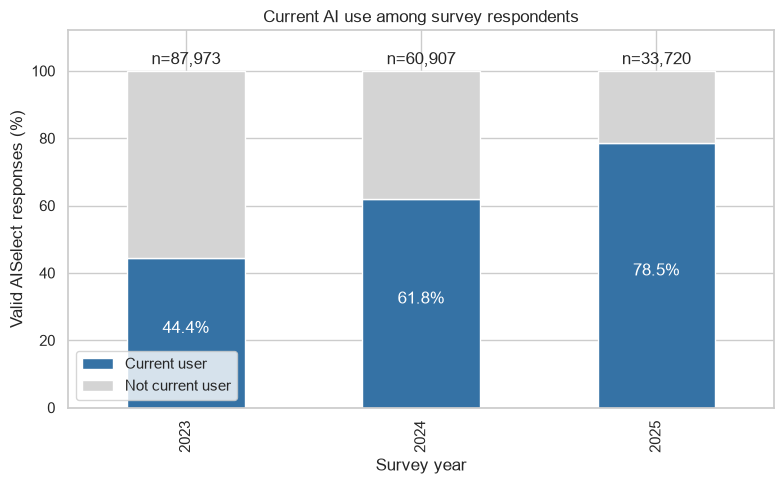

,SurveyYear,n,current_users,current_use_pct
0,2023,87973,39042.0,44.379526
1,2024,60907,37662.0,61.835257
2,2025,33720,26469.0,78.496441


**Interpretation.** 2023: 44.38% current users (n=87,973); 2024: 61.84% current users (n=60,907); 2025: 78.50% current users (n=33,720). Planning-only responses are included as noncurrent users. These are repeated respondent samples; changes do not estimate individual adoption or a population rate.

In [15]:
display(Markdown('### 9.1 Current AI use by year (RQ1)'))
adoption_summary=(df.dropna(subset=['ai_use_binary']).groupby('SurveyYear')
    .agg(n=('ai_use_binary','size'),current_users=('ai_use_binary','sum')).reset_index())
adoption_summary['current_use_pct']=100*adoption_summary.current_users/adoption_summary.n
stack=pd.DataFrame({'Current user':adoption_summary.set_index('SurveyYear').current_use_pct,
                    'Not current user':100-adoption_summary.set_index('SurveyYear').current_use_pct})
ax=stack.plot(kind='bar',stacked=True,figsize=(8,5),color=['#3572A5','#d4d4d4'])
for i,r in adoption_summary.iterrows():
    ax.text(i,102,f'n={int(r.n):,}',ha='center')
    ax.text(i,r.current_use_pct/2,f'{r.current_use_pct:.1f}%',ha='center',color='white')
ax.set(title='Current AI use among survey respondents',xlabel='Survey year',ylabel='Valid AISelect responses (%)',ylim=(0,112))
finish_figure('adoption_year')
display(adoption_summary)
interpret('**Interpretation.** '+ '; '.join(f'{int(r.SurveyYear)}: {r.current_use_pct:.2f}% current users (n={int(r.n):,})' for _,r in adoption_summary.iterrows())+
          '. Planning-only responses are included as noncurrent users. These are repeated respondent samples; changes do not estimate individual adoption or a population rate.')

**Adoption definition.** Current AI use excludes future plans. The n on the year chart is the denominator of all valid AISelect responses, not the current-user count.


### 9.2 AI use by experience (RQ2)

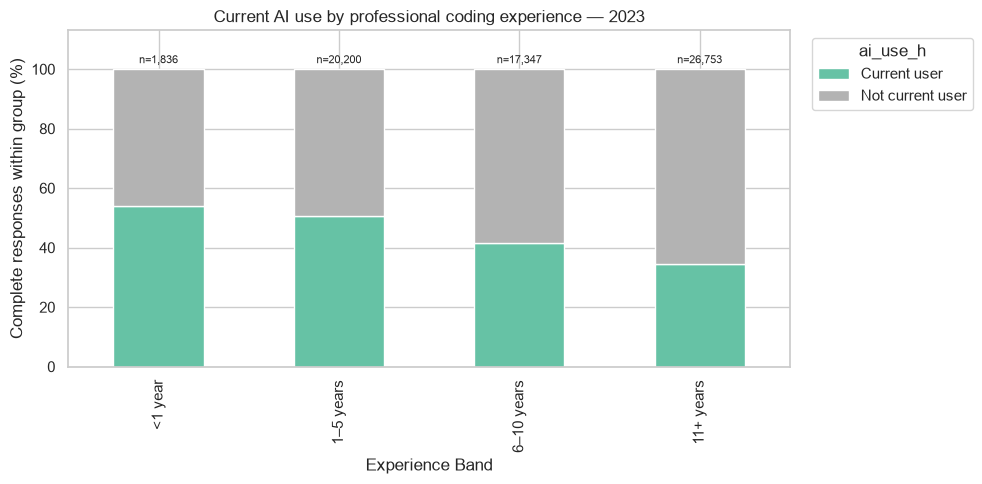

**Interpretation.** Current-use rates span 34.6% (11+ years, n=26,753) to 53.9% (<1 year, n=1,836). This panel uses professional coding experience; compare the groups within 2023, given the changed 2025 experience wording and blank-zero instruction.

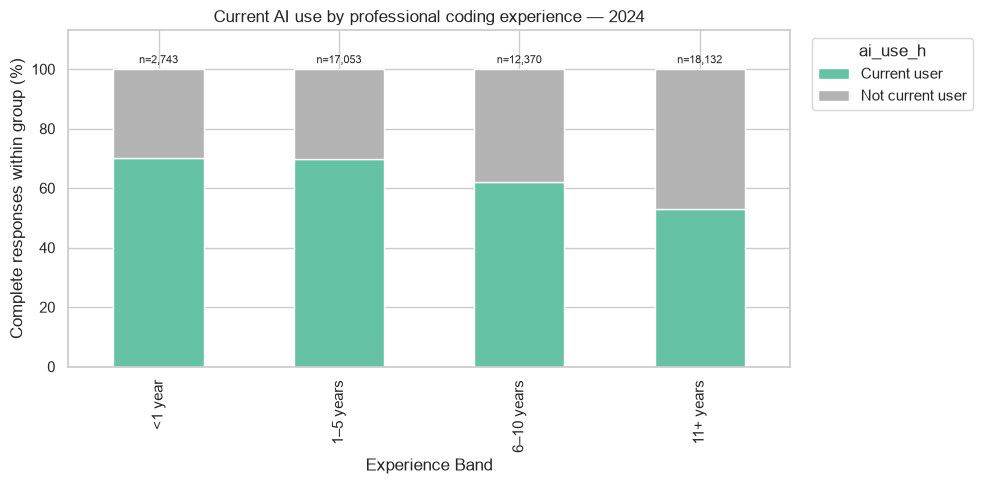

**Interpretation.** Current-use rates span 53.1% (11+ years, n=18,132) to 70.1% (<1 year, n=2,743). This panel uses professional coding experience; compare the groups within 2024, given the changed 2025 experience wording and blank-zero instruction.

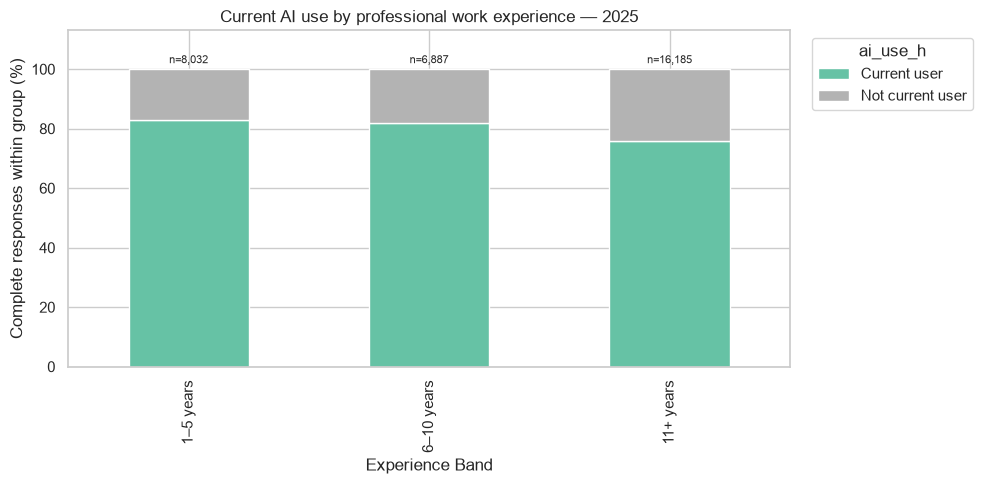

**Interpretation.** Current-use rates span 75.7% (11+ years, n=16,185) to 83.1% (1–5 years, n=8,032). This panel uses professional work experience; compare the groups within 2025, given the changed 2025 experience wording and blank-zero instruction.

In [16]:
display(Markdown('### 9.2 AI use by experience (RQ2)'))
def stacked_by_group(data,group,response,title,slug,order=None):
    """Plot complete-case within-group percentages, label each denominator, and return counts."""
    complete=data.dropna(subset=[group,response])
    counts=pd.crosstab(complete[group],complete[response])
    counts=counts.loc[counts.sum(axis=1)>0]
    if order is not None: counts=counts.reindex(columns=[c for c in order if c in counts])
    assert counts.to_numpy().sum()==len(complete)
    ns=counts.sum(axis=1)
    pct=counts.div(ns,axis=0)*100
    assert np.allclose(pct.sum(axis=1),100)
    ax=pct.plot(kind='bar',stacked=True,figsize=(10,5),colormap='Set2')
    for i,g in enumerate(pct.index): ax.text(i,102,f'n={int(ns[g]):,}',ha='center',fontsize=8)
    ax.set(title=title,xlabel=group.replace('_',' ').title(),ylabel='Complete responses within group (%)',ylim=(0,113))
    ax.legend(title=response,bbox_to_anchor=(1.02,1),loc='upper left')
    finish_figure(slug)
    return pct,ns
experience_tables=[]
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    kind=part.experience_source.iloc[0]
    tab,ns=stacked_by_group(part,'experience_band','ai_use_h',f'Current AI use by {kind.lower()} experience — {y}',f'use_experience_{y}', ['Current user','Not current user'])
    out=tab.copy(); out['n']=ns; out['year']=y; out['experience_source']=kind
    experience_tables.append(out.reset_index())
    low=tab['Current user'].idxmin(); high=tab['Current user'].idxmax()
    interpret(f'**Interpretation.** Current-use rates span {tab.loc[low,"Current user"]:.1f}% ({low}, n={int(ns[low]):,}) '
              f'to {tab.loc[high,"Current user"]:.1f}% ({high}, n={int(ns[high]):,}). '
              f'This panel uses {kind.lower()} experience; compare the groups within {y}, given the changed 2025 experience wording and blank-zero instruction.')
summary_exp=pd.concat(experience_tables,ignore_index=True)

**Reading the experience charts.** Each bar sums to 100%. Its n counts respondents with both an experience answer and a valid AI-use answer. Comparisons within a year are easier to interpret because the experience question changes in 2025.


### 9.3 Sentiment by experience: 100% stacked bars (RQ4)

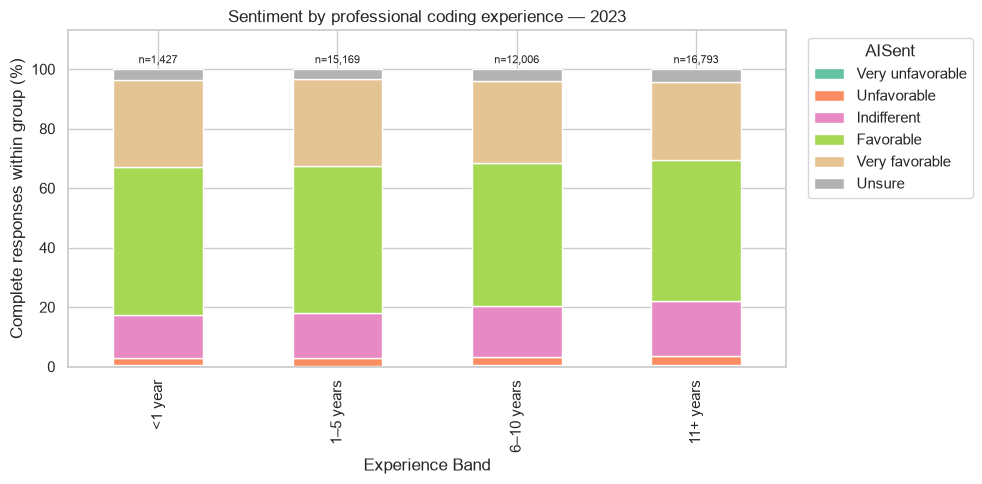

**Interpretation.** Favorable or very favorable responses range from 73.6% to 78.9% across observed experience bands (total complete-case n=45,395). Indifferent and unsure remain in the denominator; both were observed in all three releases.

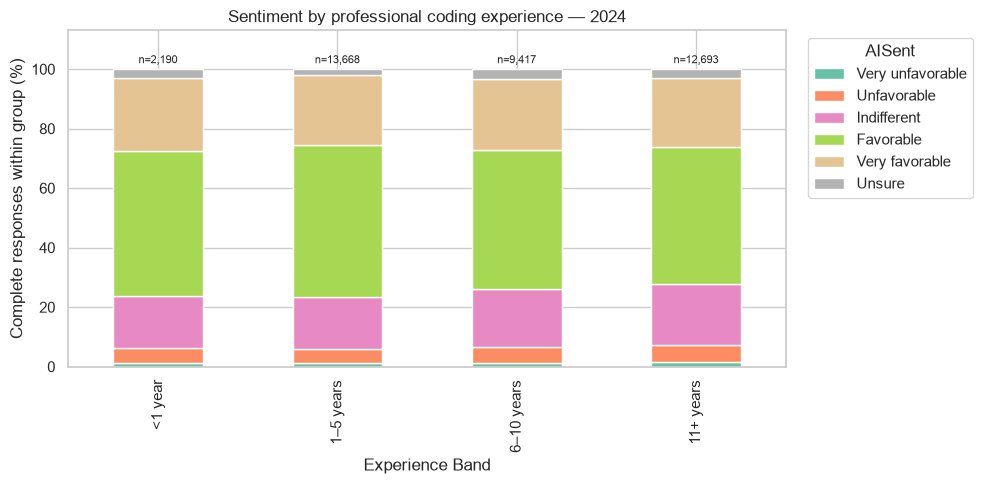

**Interpretation.** Favorable or very favorable responses range from 69.0% to 74.4% across observed experience bands (total complete-case n=37,968). Indifferent and unsure remain in the denominator; both were observed in all three releases.

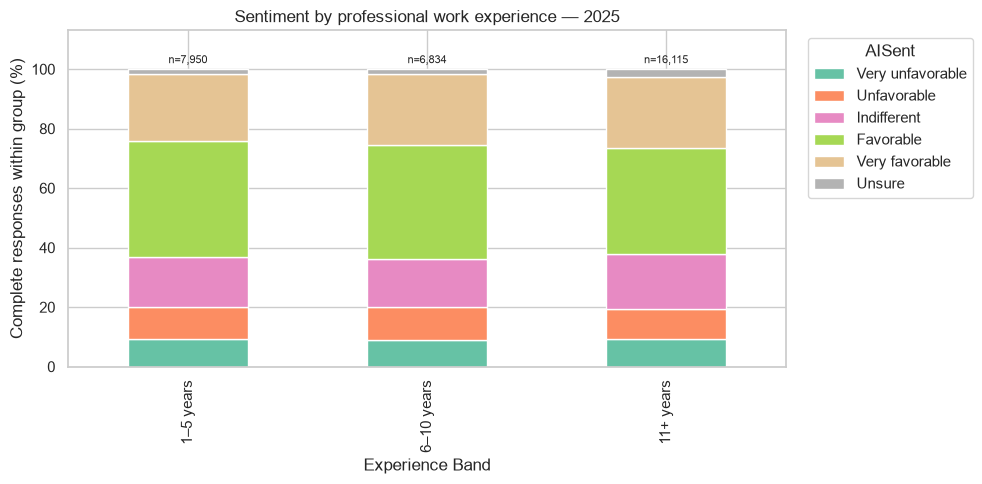

**Interpretation.** Favorable or very favorable responses range from 59.5% to 62.3% across observed experience bands (total complete-case n=30,899). Indifferent and unsure remain in the denominator; both were observed in all three releases.

In [17]:
display(Markdown('### 9.3 Sentiment by experience: 100% stacked bars (RQ4)'))
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    kind=part.experience_source.iloc[0]
    tab,ns=stacked_by_group(part,'experience_band','AISent',f'Sentiment by {kind.lower()} experience — {y}',f'sentiment_experience_{y}',sentiment_order)
    favourable=tab[[c for c in ['Favorable','Very favorable'] if c in tab]].sum(axis=1)
    interpret(f'**Interpretation.** Favorable or very favorable responses range from {favourable.min():.1f}% to {favourable.max():.1f}% '
              f'across observed experience bands (total complete-case n={int(ns.sum()):,}). '
              'Indifferent and unsure remain in the denominator; both were observed in all three releases.')

**Sentiment denominator.** Indifferent and Unsure are retained in full-distribution charts. The sensitivity table below also reports a denominator excluding Indifferent only.


### 9.4 Sentiment by year and denominator sensitivity (RQ4)

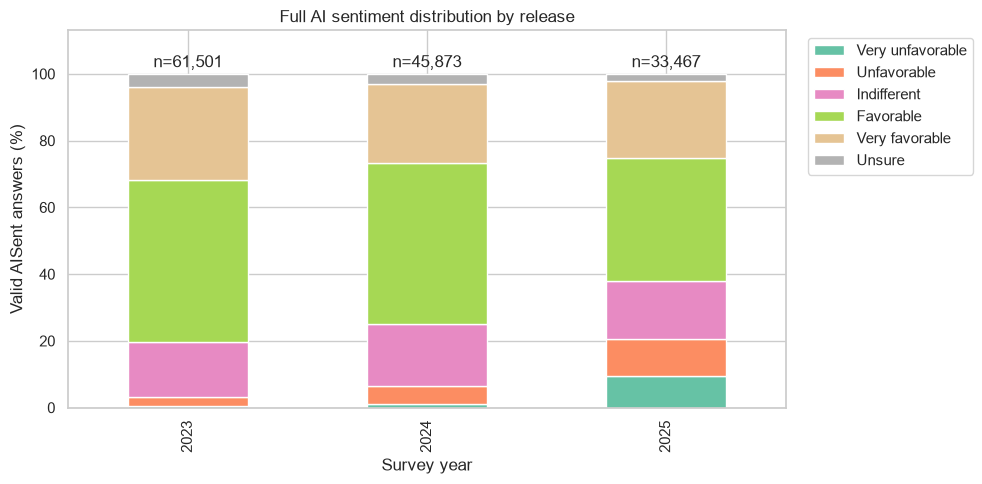

,year,n,favorable_pct,indifferent_n,without_indifferent_n,favorable_without_indifferent_pct
0,2023,61501,76.280060,10147,51354,91.352183
1,2024,45873,71.970440,8564,37309,88.490713
2,2025,33467,59.724505,5880,27587,72.454417


**Interpretation.** Favorable shares with Indifferent retained in the denominator are 2023: 76.28%, 2024: 71.97%, 2025: 59.72%. The sensitivity column excludes only Indifferent, retaining Unsure in its denominator. Observed answer categories agree across these files, but unchanged labels cannot establish identical survey routing.

In [18]:
display(Markdown('### 9.4 Sentiment by year and denominator sensitivity (RQ4)'))
sentiment_summary=[]; sentiment_counts=[]
for y in YEARS:
    vals=df.loc[df.SurveyYear.eq(y),'AISent'].dropna()
    counts=vals.value_counts().reindex(sentiment_order,fill_value=0)
    favourable=int(df.loc[df.SurveyYear.eq(y),'favorable_sentiment'].sum())
    assert favourable==int(vals.isin(['Favorable','Very favorable']).sum())
    without_indifferent=len(vals)-vals.eq('Indifferent').sum()
    sentiment_counts.append(counts.rename(y))
    sentiment_summary.append({'year':y,'n':len(vals),'favorable_pct':100*favourable/len(vals),
        'indifferent_n':int(vals.eq('Indifferent').sum()),'without_indifferent_n':without_indifferent,
        'favorable_without_indifferent_pct':100*favourable/without_indifferent})
sentiment_summary=pd.DataFrame(sentiment_summary)
sent_plot=pd.DataFrame(sentiment_counts).div(pd.DataFrame(sentiment_counts).sum(axis=1),axis=0)*100
ax=sent_plot.plot(kind='bar',stacked=True,figsize=(10,5),colormap='Set2')
for i,r in sentiment_summary.iterrows(): ax.text(i,102,f'n={int(r.n):,}',ha='center')
ax.set(title='Full AI sentiment distribution by release',xlabel='Survey year',ylabel='Valid AISent answers (%)',ylim=(0,113))
ax.legend(bbox_to_anchor=(1.02,1),loc='upper left'); finish_figure('sentiment_year')
display(sentiment_summary)
interpret('**Interpretation.** Favorable shares with Indifferent retained in the denominator are '+', '.join(f'{int(r.year)}: {r.favorable_pct:.2f}%' for _,r in sentiment_summary.iterrows())+
          '. The sensitivity column excludes only Indifferent, retaining Unsure in its denominator. Observed answer categories agree across these files, but unchanged labels cannot establish identical survey routing.')

**Comparing sentiment across years.** The released files contain the same observed sentiment labels, including Indifferent. The decline in favorable answers cannot be explained simply by treating Indifferent as a new 2025 option. Survey routing and presentation may still have changed.


### 9.5 Top AI products/models (RQ3)

,choice,selected_n,question_n,respondent_pct,year,source
0,ChatGPT,52462,56328,93.136628,2023,AISearchHaveWorkedWith
1,Bing AI,12981,56328,23.045377,2023,AISearchHaveWorkedWith
2,WolframAlpha,8419,56328,14.946385,2023,AISearchHaveWorkedWith
3,Google Bard AI,6217,56328,11.037140,2023,AISearchHaveWorkedWith
4,Phind,2067,56328,3.669578,2023,AISearchHaveWorkedWith
5,You.com,1601,56328,2.842281,2023,AISearchHaveWorkedWith
6,Perplexity AI,739,56328,1.311959,2023,AISearchHaveWorkedWith
7,Quora Poe,643,56328,1.141528,2023,AISearchHaveWorkedWith


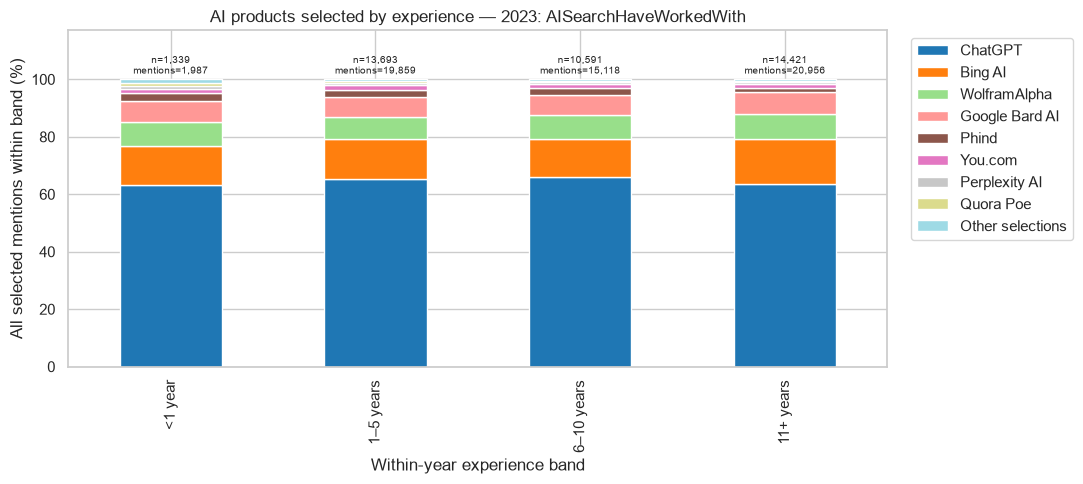

**Interpretation.** `ChatGPT` leads this question with 52,462 selections (93.1% of question answerers; n=56,328). The 100% stack shows shares of mentions, including Other selections, rather than developer adoption percentages. Questions are kept separate: an unanswered product question is never treated as an unselected tool.

,choice,selected_n,question_n,respondent_pct,year,source
0,GitHub Copilot,22078,25904,85.230080,2023,AIDevHaveWorkedWith
1,Tabnine,5193,25904,20.047097,2023,AIDevHaveWorkedWith
2,AWS CodeWhisperer,2071,25904,7.994904,2023,AIDevHaveWorkedWith
3,Synk Code,538,25904,2.076899,2023,AIDevHaveWorkedWith
4,Codeium,504,25904,1.945645,2023,AIDevHaveWorkedWith
5,Whispr AI,455,25904,1.756485,2023,AIDevHaveWorkedWith
6,Replit Ghostwriter,335,25904,1.293237,2023,AIDevHaveWorkedWith
7,Mintlify,211,25904,0.814546,2023,AIDevHaveWorkedWith


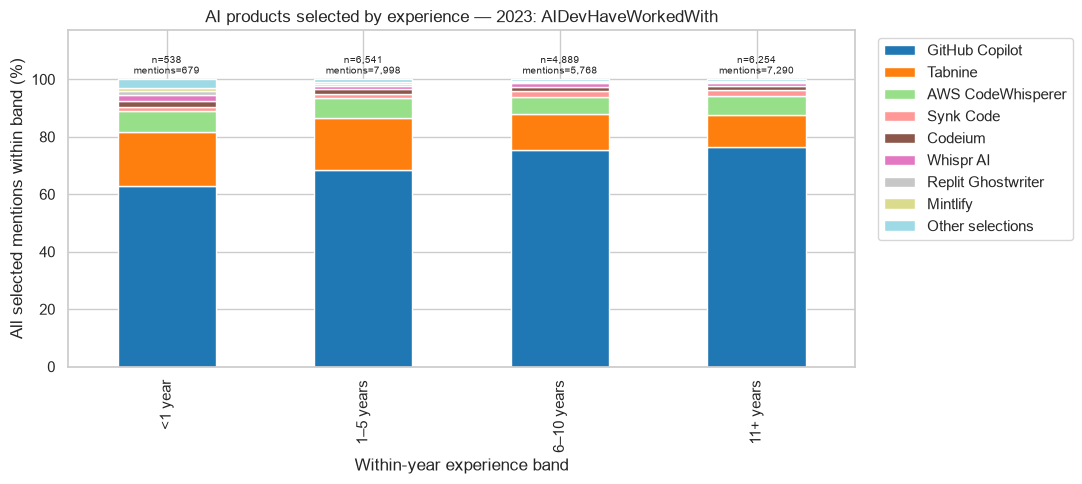

**Interpretation.** `GitHub Copilot` leads this question with 22,078 selections (85.2% of question answerers; n=25,904). The 100% stack shows shares of mentions, including Other selections, rather than developer adoption percentages. Questions are kept separate: an unanswered product question is never treated as an unselected tool.

,choice,selected_n,question_n,respondent_pct,year,source
0,ChatGPT,37923,44453,85.310328,2024,AISearchDevHaveWorkedWith
1,GitHub Copilot,19032,44453,42.813758,2024,AISearchDevHaveWorkedWith
2,Google Gemini,11056,44453,24.871212,2024,AISearchDevHaveWorkedWith
3,Bing AI,7305,44453,16.433087,2024,AISearchDevHaveWorkedWith
4,Visual Studio Intellicode,6296,44453,14.163274,2024,AISearchDevHaveWorkedWith
5,Claude,3760,44453,8.458372,2024,AISearchDevHaveWorkedWith
6,Codeium,2809,44453,6.319034,2024,AISearchDevHaveWorkedWith
7,WolframAlpha,2567,44453,5.774638,2024,AISearchDevHaveWorkedWith


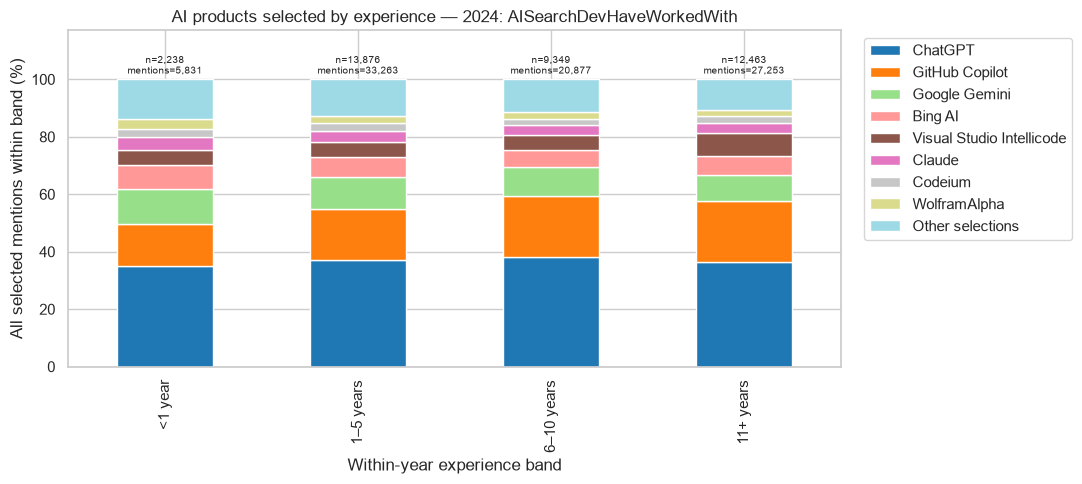

**Interpretation.** `ChatGPT` leads this question with 37,923 selections (85.3% of question answerers; n=44,453). The 100% stack shows shares of mentions, including Other selections, rather than developer adoption percentages. Questions are kept separate: an unanswered product question is never treated as an unselected tool.

,choice,selected_n,question_n,respondent_pct,year,source
0,openAI GPT (chatbot models),13424,16281,82.451938,2025,AIModelsHaveWorkedWith
1,Anthropic: Claude Sonnet,7063,16281,43.381856,2025,AIModelsHaveWorkedWith
2,Gemini (Flash general purpose models),5823,16281,35.765616,2025,AIModelsHaveWorkedWith
3,openAI Reasoning models,5716,16281,35.108409,2025,AIModelsHaveWorkedWith
4,openAI Image generating models,4395,16281,26.994656,2025,AIModelsHaveWorkedWith
5,Gemini (Pro Reasoning models),4221,16281,25.925926,2025,AIModelsHaveWorkedWith
6,DeepSeek (R- Reasoning models),3848,16281,23.634912,2025,AIModelsHaveWorkedWith
7,Meta Llama (all models),2941,16281,18.064001,2025,AIModelsHaveWorkedWith


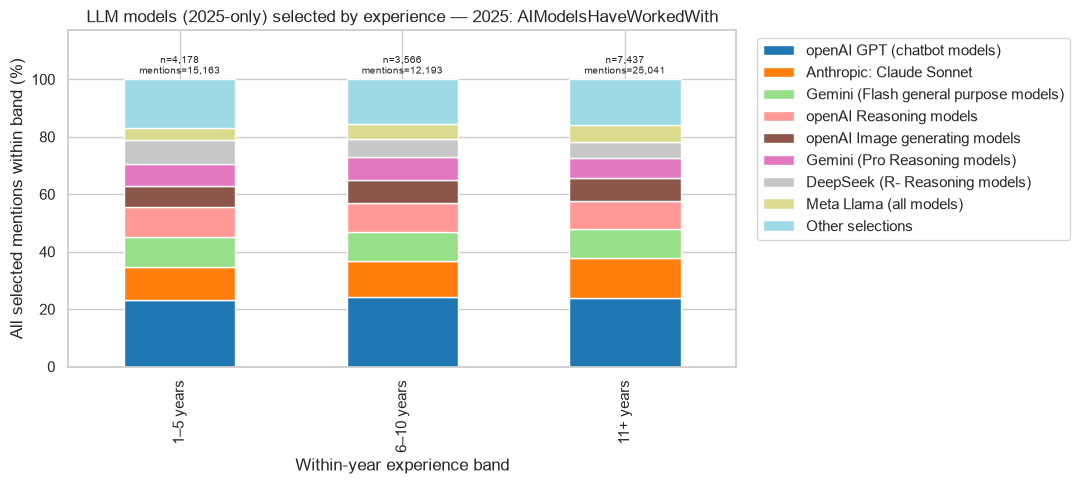

**Interpretation.** `openAI GPT (chatbot models)` leads this question with 13,424 selections (82.5% of question answerers; n=16,281). The 100% stack shows shares of mentions, including Other selections, rather than developer adoption percentages. Questions are kept separate: an unanswered product question is never treated as an unselected tool.

In [19]:
display(Markdown('### 9.5 Top AI products/models (RQ3)'))
top_tool_tables=[]
for (y,source),flags in tool_blocks.items():
    part=df[df.SurveyYear.eq(y)]
    answered=part[source].notna()
    choice_cols=[c for c in flags if not c.endswith('__answered')]
    counts=flags.loc[answered,choice_cols].sum().astype(int).sort_values(ascending=False)
    n=int(answered.sum())
    top=counts.head(8)
    table=pd.DataFrame({'choice':[c.split('__',1)[1] for c in top.index],'selected_n':top.values,
                        'question_n':n,'respondent_pct':100*top.values/n,'year':y,'source':source})
    top_tool_tables.append(table)
    display(table)
    # Compose mentions for experience complete cases; make top-N vs all-choice denominator explicit.
    valid=answered & part.experience_band.notna()
    data=pd.concat([part.loc[valid,['experience_band']],flags.loc[valid,choice_cols]],axis=1)
    group_counts=data.groupby('experience_band',observed=True)[choice_cols].sum()
    mention_n=group_counts.sum(axis=1)
    plot_counts=group_counts[top.index].rename(columns={c:c.split('__',1)[1] for c in top.index})
    plot_counts['Other selections']=mention_n-plot_counts.sum(axis=1)
    plot_pct=plot_counts.div(mention_n,axis=0)*100
    group_n=data.groupby('experience_band',observed=True).size()
    assert np.allclose(plot_pct.sum(axis=1),100)
    ax=plot_pct.plot(kind='bar',stacked=True,figsize=(11,5),colormap='tab20')
    for i,g in enumerate(plot_pct.index):
        ax.text(i,102,f'n={int(group_n[g]):,}\nmentions={int(mention_n[g]):,}',ha='center',fontsize=7)
    label='LLM models (2025-only)' if y==2025 else 'AI products'
    ax.set(title=f'{label} selected by experience — {y}: {source}',xlabel='Within-year experience band',ylabel='All selected mentions within band (%)',ylim=(0,117))
    ax.legend(bbox_to_anchor=(1.02,1),loc='upper left'); finish_figure(f'tools_{y}_{source}')
    leader=table.iloc[0]
    interpret(f'**Interpretation.** `{leader.choice}` leads this question with {int(leader.selected_n):,} selections '
              f'({leader.respondent_pct:.1f}% of question answerers; n={n:,}). '
              'The 100% stack shows shares of mentions, including Other selections, rather than developer adoption percentages. '
              'Questions are kept separate: an unanswered product question is never treated as an unselected tool.')
top_tools=pd.concat(top_tool_tables,ignore_index=True)

**Tool interpretation.** Each source question and release is kept separate, including both 2023 questions. Stacked shares sum across all selected mentions, with Other selections for choices outside the displayed top eight.


### 9.6 Main-role comparisons (RQ5)

,year,DevType,n,current_use_pct
15,2023,"Developer, full-stack",25735,47.857004
11,2023,"Developer, back-end",13745,40.007275
14,2023,"Developer, front-end",5071,51.705778
12,2023,"Developer, desktop or enterprise applications",3904,27.843238
24,2023,Other (please specify):,3080,39.642857
17,2023,"Developer, mobile",2597,43.357720
21,2023,Engineering manager,2033,40.482046
31,2023,Student,1996,55.410822
13,2023,"Developer, embedded applications or devices",1845,26.341463
4,2023,Data scientist or machine learning specialist,1588,60.012594


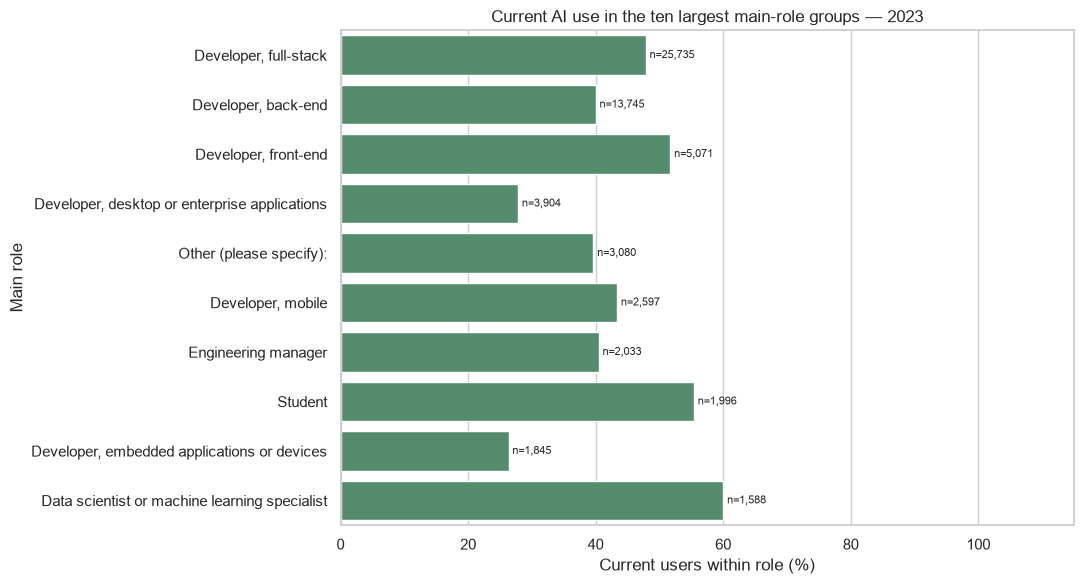

**Interpretation.** Among these ten roles, `Data scientist or machine learning specialist` reports 60.0% current use (n=1,588). Roles are single-choice in these releases; the displayed groups are mutually exclusive, but selection of large groups and different role lists limit generalization.

,year,DevType,n,current_use_pct
17,2024,"Developer, full-stack",17847,65.299490
13,2024,"Developer, back-end",9680,61.973140
32,2024,Student,5030,61.510934
16,2024,"Developer, front-end",3248,69.057882
14,2024,"Developer, desktop or enterprise applications",2445,44.989775
25,2024,Other (please specify):,2416,51.324503
19,2024,"Developer, mobile",1968,65.193089
15,2024,"Developer, embedded applications or devices",1590,43.459119
22,2024,Engineering manager,1253,62.490024
0,2024,Academic researcher,1199,57.798165


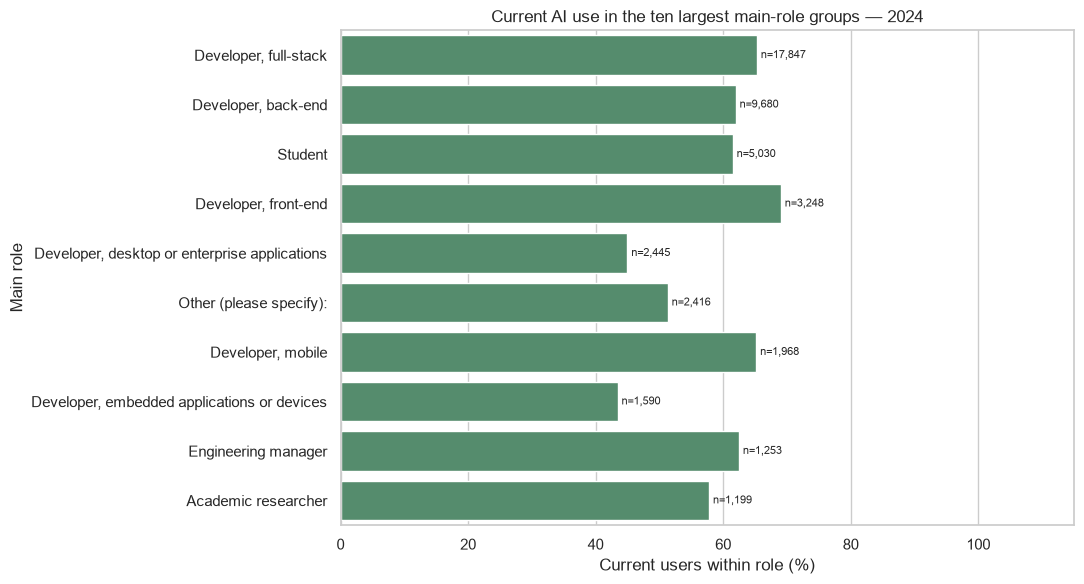

**Interpretation.** Among these ten roles, `Developer, front-end` reports 69.1% current use (n=3,248). Roles are single-choice in these releases; the displayed groups are mutually exclusive, but selection of large groups and different role lists limit generalization.

,year,DevType,n,current_use_pct
17,2025,"Developer, full-stack",9554,82.447143
13,2025,"Developer, back-end",4936,81.239870
28,2025,Student,2265,72.803532
3,2025,"Architect, software or solutions",2152,82.295539
14,2025,"Developer, desktop or enterprise applications",1554,68.468468
16,2025,"Developer, front-end",1484,86.859838
23,2025,Other (please specify):,1379,67.077592
19,2025,"Developer, mobile",1045,85.358852
15,2025,"Developer, embedded applications or devices",1016,65.157480
1,2025,Academic researcher,872,69.036697


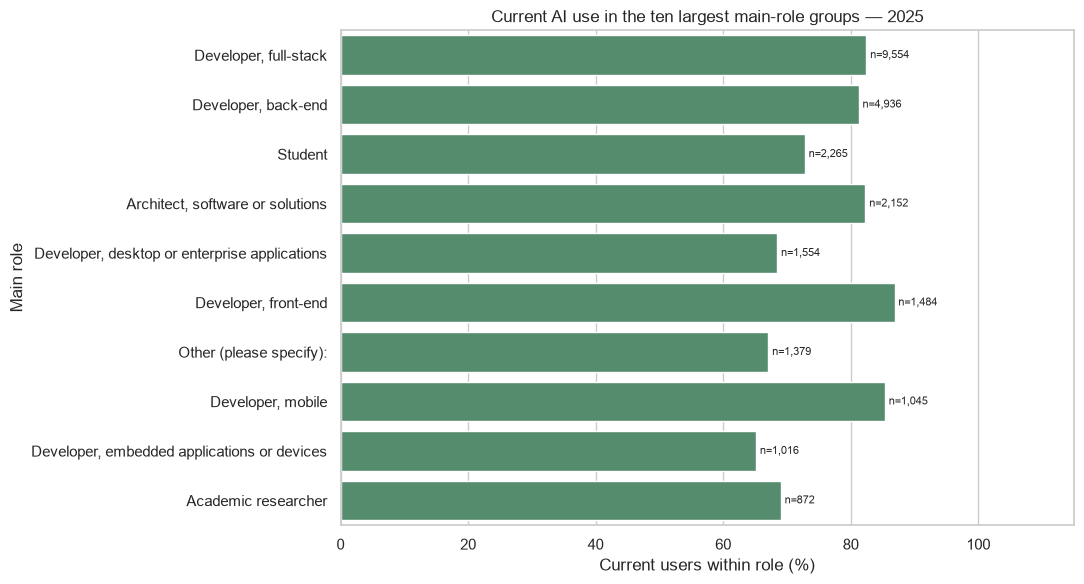

**Interpretation.** Among these ten roles, `Developer, front-end` reports 86.9% current use (n=1,484). Roles are single-choice in these releases; the displayed groups are mutually exclusive, but selection of large groups and different role lists limit generalization.

In [20]:
display(Markdown('### 9.6 Main-role comparisons (RQ5)'))
role_tables=[]
for y in YEARS:
    part=df[df.SurveyYear.eq(y)].dropna(subset=['DevType','ai_use_binary'])
    out=part.groupby('DevType').ai_use_binary.agg(n='size',rate='mean').reset_index()
    out['current_use_pct']=100*out['rate']; out['year']=y
    out=out.nlargest(10,'n'); role_tables.append(out)
    display(out[['year','DevType','n','current_use_pct']])
    plt.figure(figsize=(11,6)); ax=sns.barplot(data=out,x='current_use_pct',y='DevType',color='#4C956C')
    for i,r in out.reset_index(drop=True).iterrows(): ax.text(r.current_use_pct+0.6,i,f'n={int(r.n):,}',va='center',fontsize=8)
    ax.set(title=f'Current AI use in the ten largest main-role groups — {y}',xlabel='Current users within role (%)',ylabel='Main role',xlim=(0,115))
    finish_figure(f'role_{y}')
    leader=out.loc[out.current_use_pct.idxmax()]
    interpret(f'**Interpretation.** Among these ten roles, `{leader.DevType}` reports {leader.current_use_pct:.1f}% current use '
              f'(n={int(leader.n):,}). Roles are single-choice in these releases; the displayed groups are mutually exclusive, '
              'but selection of large groups and different role lists limit generalization.')
role_summary=pd.concat(role_tables,ignore_index=True)

**Role interpretation.** These releases ask for one main role. Group rates are mutually exclusive descriptions of that reported role, with different role lists across years.


### 9.7 Bangladesh versus Global (RQ6)

,year,sample,n,users,pct,lower_pct,upper_pct
0,2023,Global,87973,39042,44.379526,44.051470,44.708072
1,2023,Bangladesh,490,284,57.959184,53.543206,62.251337
2,2024,Global,60907,37662,61.835257,61.448721,62.220301
3,2024,Bangladesh,324,233,71.913580,66.785184,76.528435
4,2025,Global,33720,26469,78.496441,78.054693,78.931697
5,2025,Bangladesh,194,171,88.144330,82.838672,91.968702


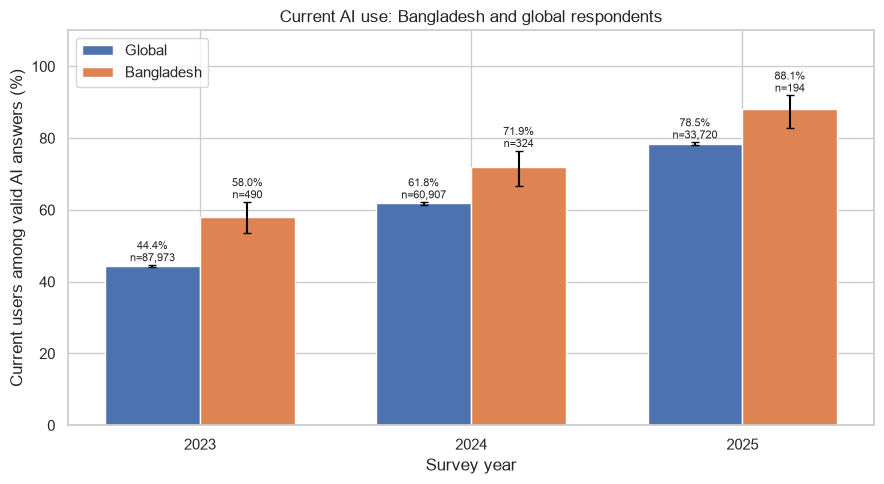

**Interpretation.** Bangladesh reports 2023: 57.96% (n=490), 2024: 71.91% (n=324), 2025: 88.14% (n=194). Wilson intervals indicate sampling variability under a simple independent-binomial model; they cannot correct self-selection or coverage bias. Global includes Bangladesh; these are overlapping descriptive series.

In [21]:
display(Markdown('### 9.7 Bangladesh versus Global (RQ6)'))
bd_rows=[]
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    # Global adoption uses all valid AI answers, independent of whether country was answered.
    global_part=part.dropna(subset=['ai_use_binary'])
    bd_part=part[part.Country.eq('Bangladesh')].dropna(subset=['ai_use_binary'])
    for sample,z in [('Global',global_part),('Bangladesh',bd_part)]:
        n=len(z); users=int(z.ai_use_binary.sum())
        lo,hi=proportion_confint(users,n,method='wilson')
        bd_rows.append({'year':y,'sample':sample,'n':n,'users':users,'pct':100*users/n,'lower_pct':100*lo,'upper_pct':100*hi})
bd=pd.DataFrame(bd_rows)
display(bd)
# Threshold is descriptive; no inferential country test or sparse Bangladesh subgroups.
shown=bd[bd.n.ge(100)]
fig,ax=plt.subplots(figsize=(9,5))
for j,sample in enumerate(['Global','Bangladesh']):
    part=shown[shown['sample'].eq(sample)].set_index('year').reindex(YEARS)
    x=np.arange(len(YEARS))+(j-0.5)*0.35
    ax.bar(x,part.pct,width=0.35,label=sample)
    ax.errorbar(x,part.pct,yerr=np.vstack([part.pct-part.lower_pct,part.upper_pct-part.pct]),fmt='none',color='black',capsize=3)
    for pos,(_,r) in zip(x,part.iterrows()):
        if pd.notna(r.n): ax.text(pos,r.upper_pct+1,f'{r.pct:.1f}%\nn={int(r.n):,}',ha='center',fontsize=8)
ax.set(xticks=np.arange(len(YEARS)),xticklabels=YEARS,title='Current AI use: Bangladesh and global respondents',xlabel='Survey year',ylabel='Current users among valid AI answers (%)',ylim=(0,110)); ax.legend()
finish_figure('bangladesh_global')
interpret('**Interpretation.** Bangladesh reports '+', '.join(f'{int(r.year)}: {r.pct:.2f}% (n={int(r.n):,})' for _,r in bd[bd['sample'].eq('Bangladesh')].iterrows())+
          '. Wilson intervals indicate sampling variability under a simple independent-binomial model; they cannot correct self-selection or coverage bias. Global includes Bangladesh; these are overlapping descriptive series.')

**Country interpretation.** Global uses all valid AISelect answers; Bangladesh additionally requires the country answer. The country-specific estimates are descriptive, and the global sample includes Bangladesh.


In [22]:
display(Markdown('### 9.7.1 Robustness: Bangladesh versus Rest of World'))
# Keep the required overlapping Global comparison; use disjoint groups here.
geography_rows=[]
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    eligible=part.dropna(subset=['Country','ai_use_binary'])
    is_bd=eligible.Country.eq('Bangladesh')
    groups={'Bangladesh':eligible.loc[is_bd], 'Rest of World':eligible.loc[~is_bd]}
    assert groups['Bangladesh'].index.intersection(groups['Rest of World'].index).empty
    assert sum(len(g) for g in groups.values())==len(eligible)
    for group,g in groups.items():
        n=len(g); count=int(g.ai_use_binary.sum())
        lo,hi=proportion_confint(count,n,alpha=ALPHA,method='wilson')
        geography_rows.append({'analysis':'Geography','year':y,'group':group,'n':n,'users':count,
            'pct':100*count/n,'lower_pct':100*lo,'upper_pct':100*hi,'eligible_n':len(eligible),
            'missing_country_among_AI_answers':int((part.Country.isna() & part.ai_use_binary.notna()).sum())})
geography_robustness=pd.DataFrame(geography_rows)
display(geography_robustness.drop(columns='analysis'))
geo_rates=geography_robustness.pivot(index='year',columns='group',values='pct')
geo_outcome=('Higher Bangladesh estimate in every release' if
             geo_rates.Bangladesh.gt(geo_rates['Rest of World']).all() else
             'Direction varies across releases; review the yearly estimates')
geography_robustness['outcome']=geo_outcome
interpret('**Interpretation.** '+ '; '.join(
    f'{y}: Bangladesh {r.Bangladesh:.2f}% versus Rest of World {r["Rest of World"]:.2f}%'
    for y,r in geo_rates.iterrows())+'. '+geo_outcome+'. '
    'The table gives each group’s valid n and Wilson interval; the Bangladesh samples are much smaller, '
    'and these estimates describe survey respondents, not all Bangladeshi developers.')
g24=geography_robustness[geography_robustness.year.eq(2024)]
country_global_24=100*g24.users.sum()/g24.n.sum()
full_global_24=bd[bd.year.eq(2024) & bd['sample'].eq('Global')].iloc[0]
interpret(f'**Denominator check.** Required Global includes Bangladesh and all valid AI answers, including '
          f'{int(g24.missing_country_among_AI_answers.iloc[0]):,} missing-country answers in 2024. '
          f'For 2024, Country+AI-valid Global is {country_global_24:.2f}% (n={int(g24.n.sum()):,}), '
          f'whereas the required Global estimate is {full_global_24.pct:.2f}% (n={int(full_global_24.n):,}). '
          'Thus the Global-to-Rest-of-World difference also reflects country availability. '
          'The disjoint comparison needs no new hypothesis test; Wilson intervals cannot remove participation bias.')

### 9.7.1 Robustness: Bangladesh versus Rest of World

,year,group,n,users,pct,lower_pct,upper_pct,eligible_n,missing_country_among_AI_answers
0,2023,Bangladesh,490,284,57.959184,53.543206,62.251337,87973,0
1,2023,Rest of World,87483,38758,44.303465,43.974553,44.632877,87973,0
2,2024,Bangladesh,324,233,71.913580,66.785184,76.528435,58443,2464
3,2024,Rest of World,58119,35471,61.031676,60.634479,61.427416,58443,2464
4,2025,Bangladesh,194,171,88.144330,82.838672,91.968702,33720,0
5,2025,Rest of World,33526,26298,78.440613,77.997172,78.877538,33720,0


**Interpretation.** 2023: Bangladesh 57.96% versus Rest of World 44.30%; 2024: Bangladesh 71.91% versus Rest of World 61.03%; 2025: Bangladesh 88.14% versus Rest of World 78.44%. Higher Bangladesh estimate in every release. The table gives each group’s valid n and Wilson interval; the Bangladesh samples are much smaller, and these estimates describe survey respondents, not all Bangladeshi developers.

**Denominator check.** Required Global includes Bangladesh and all valid AI answers, including 2,464 missing-country answers in 2024. For 2024, Country+AI-valid Global is 61.09% (n=58,443), whereas the required Global estimate is 61.84% (n=60,907). Thus the Global-to-Rest-of-World difference also reflects country availability. The disjoint comparison needs no new hypothesis test; Wilson intervals cannot remove participation bias.

### 9.8 Experience distributions

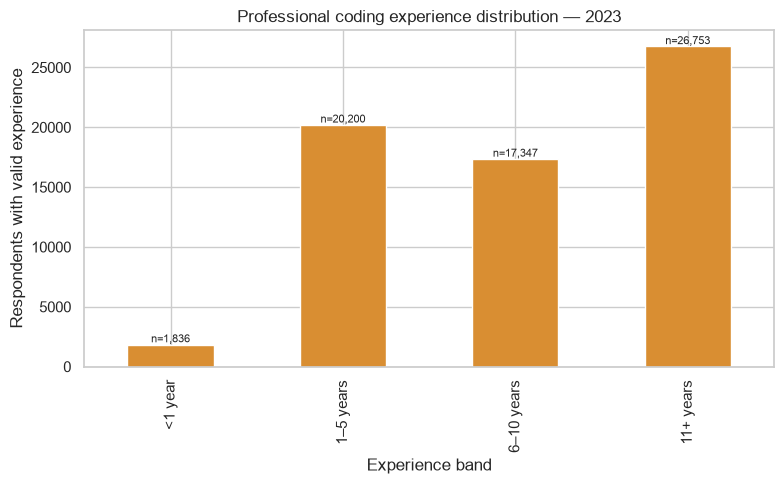

**Interpretation.** The largest band in 2023 is 11+ years with 26,753 respondents out of n=66,136. 2025 blanks may include zero-experience respondents and cannot be recoded to zero; its observed experience distribution is selected.

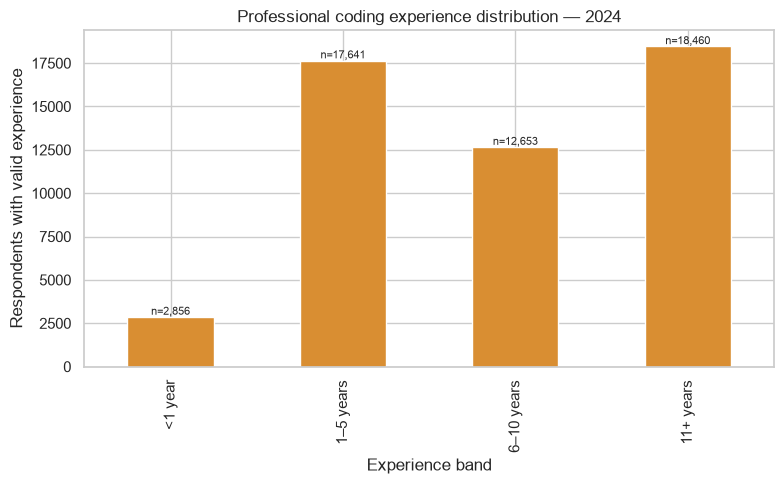

**Interpretation.** The largest band in 2024 is 11+ years with 18,460 respondents out of n=51,610. 2025 blanks may include zero-experience respondents and cannot be recoded to zero; its observed experience distribution is selected.

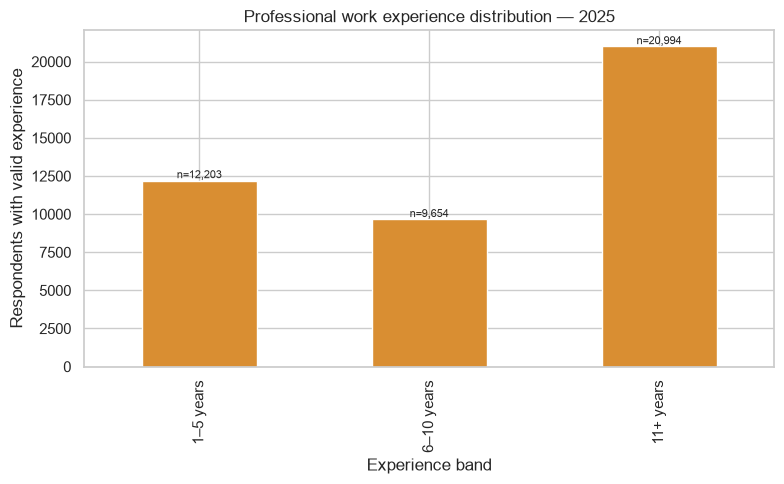

**Interpretation.** The largest band in 2025 is 11+ years with 20,994 respondents out of n=42,851. 2025 blanks may include zero-experience respondents and cannot be recoded to zero; its observed experience distribution is selected.

In [23]:
display(Markdown('### 9.8 Experience distributions'))
for y in YEARS:
    part=df[df.SurveyYear.eq(y)].dropna(subset=['experience_band'])
    counts=part.experience_band.value_counts().sort_index()
    counts=counts[counts>0]
    ax=counts.plot(kind='bar',figsize=(8,5),color='#D98E32')
    for i,(g,n) in enumerate(counts.items()): ax.text(i,n,f'n={int(n):,}',ha='center',va='bottom',fontsize=8)
    ax.set(title=f'{part.experience_source.iloc[0]} experience distribution — {y}',xlabel='Experience band',ylabel='Respondents with valid experience')
    finish_figure(f'experience_distribution_{y}')
    interpret(f'**Interpretation.** The largest band in {y} is {counts.idxmax()} with {int(counts.max()):,} respondents '
              f'out of n={int(counts.sum()):,}. 2025 blanks may include zero-experience respondents and cannot be recoded to zero; its observed experience distribution is selected.')

**Reading the experience distributions.** These charts show who contributes to each year’s experience comparisons. A change in the mix of respondents may help explain differences in adoption or sentiment across releases.


### 9.9 Trust in AI output by experience

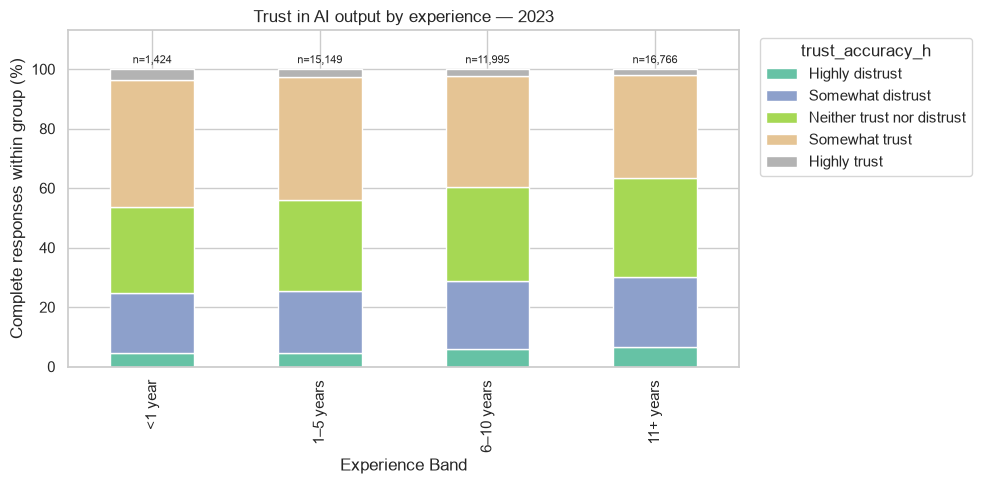

**Interpretation.** Overall trust is 42.15% and distrust is 27.17% among n=61,396 trust answerers; the chart subset also requires valid experience (n=45,334). The 2023 trust responses come from AIBen, as confirmed by the schema, rather than its benefits field AIAcc.

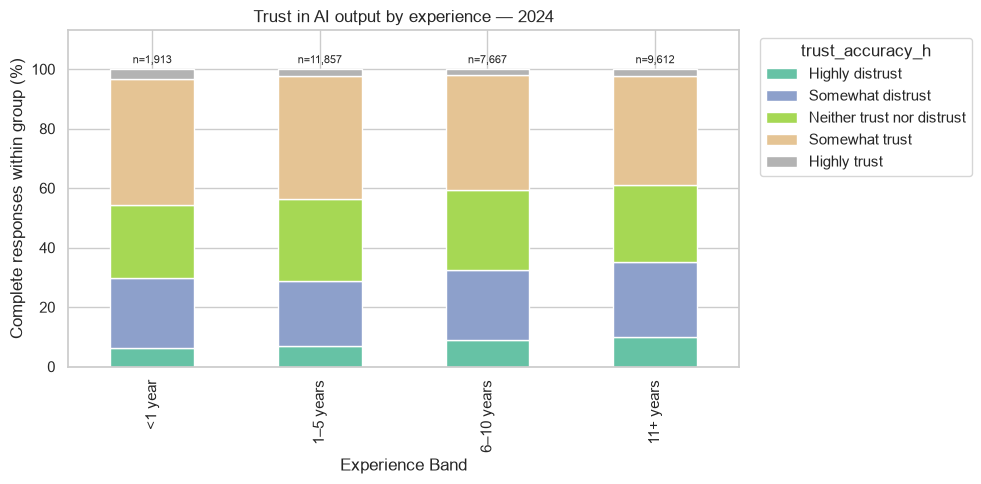

**Interpretation.** Overall trust is 43.04% and distrust is 30.37% among n=37,302 trust answerers; the chart subset also requires valid experience (n=31,049). The 2023 trust responses come from AIBen, as confirmed by the schema, rather than its benefits field AIAcc.

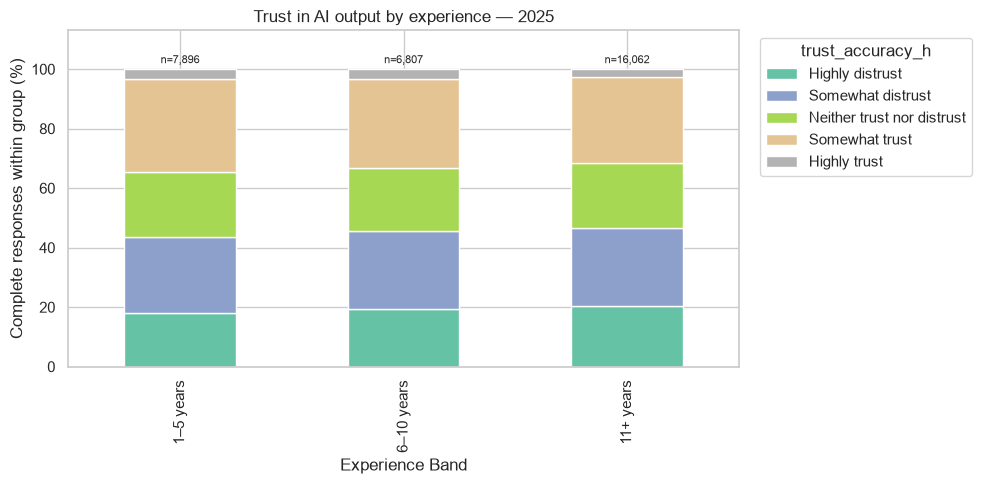

**Interpretation.** Overall trust is 32.79% and distrust is 45.70% among n=33,297 trust answerers; the chart subset also requires valid experience (n=30,765). The 2023 trust responses come from AIBen, as confirmed by the schema, rather than its benefits field AIAcc.

In [24]:
display(Markdown('### 9.9 Trust in AI output by experience'))
trust_summary=[]
trust_order=['Highly distrust','Somewhat distrust','Neither trust nor distrust','Somewhat trust','Highly trust']
for y in YEARS:
    part=df[df.SurveyYear.eq(y)]
    tab,ns=stacked_by_group(part,'experience_band','trust_accuracy_h',f'Trust in AI output by experience — {y}',f'trust_experience_{y}',trust_order)
    vals=part.trust_accuracy_h.dropna()
    positive=100*vals.isin(['Somewhat trust','Highly trust']).mean()
    negative=100*vals.isin(['Somewhat distrust','Highly distrust']).mean()
    trust_summary.append({'year':y,'n':len(vals),'trust_pct':positive,'distrust_pct':negative})
    interpret(f'**Interpretation.** Overall trust is {positive:.2f}% and distrust is {negative:.2f}% among '
              f'n={len(vals):,} trust answerers; the chart subset also requires valid experience (n={int(ns.sum()):,}). '
              'The 2023 trust responses come from AIBen, as confirmed by the schema, rather than its benefits field AIAcc.')
trust_summary=pd.DataFrame(trust_summary)

**Reading the trust charts.** The categories show respondents’ confidence in AI output. They measure reported trust, rather than the accuracy of the tools themselves.


### 9.10 Current AI use by age

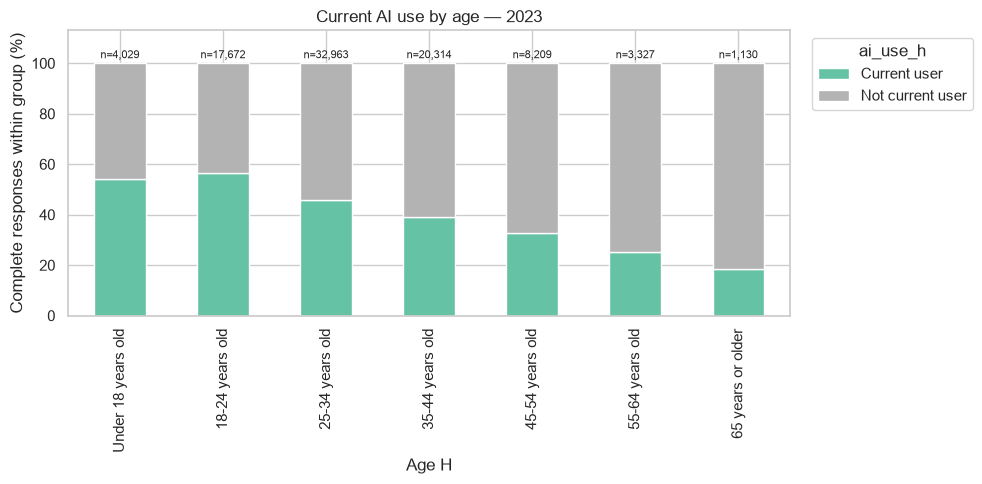

**Interpretation.** Among age/use complete cases, current use ranges from 18.3% to 56.5% (n=87,644). Refused or missing age answers are excluded; age-group differences describe this respondent pool.

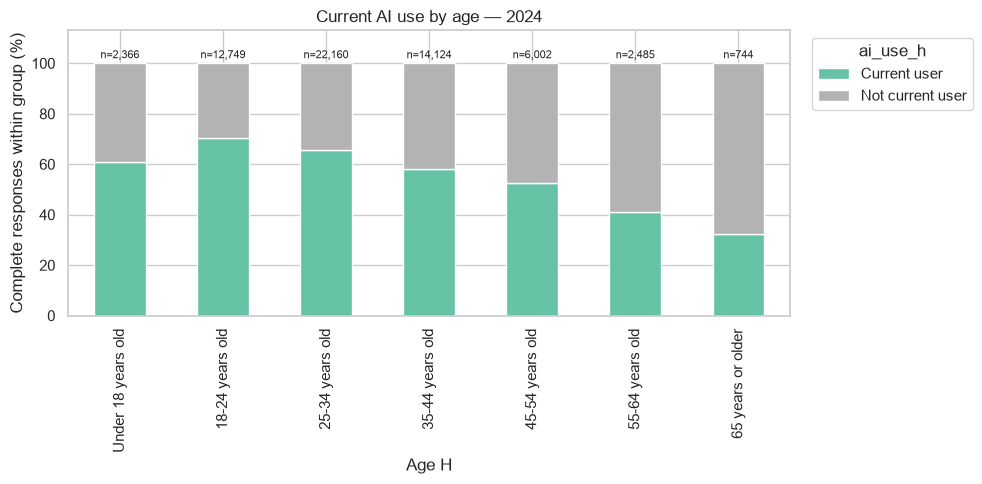

**Interpretation.** Among age/use complete cases, current use ranges from 32.3% to 70.4% (n=60,630). Refused or missing age answers are excluded; age-group differences describe this respondent pool.

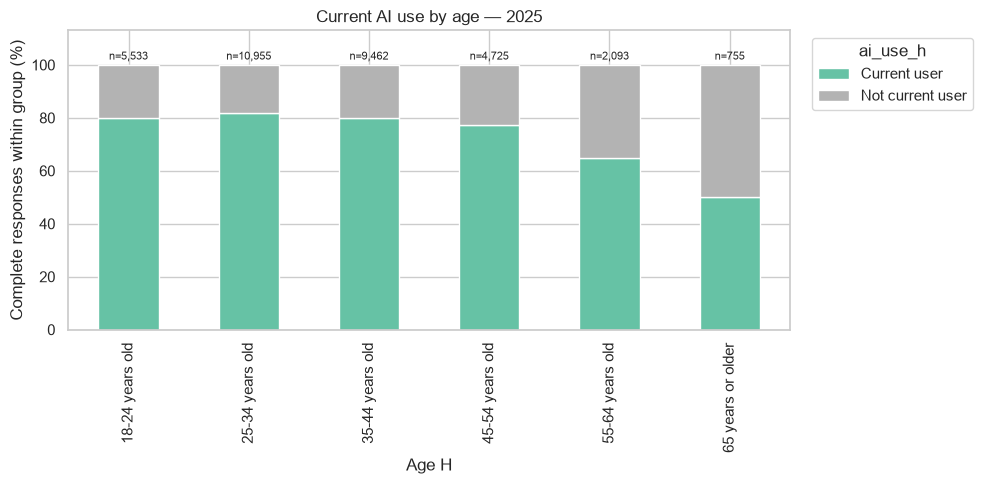

**Interpretation.** Among age/use complete cases, current use ranges from 50.1% to 81.8% (n=33,523). Refused or missing age answers are excluded; age-group differences describe this respondent pool.

In [25]:
for y in YEARS:
    part=df[df.SurveyYear.eq(y)].copy()
    part['age_h']=pd.Categorical(part.age_h,categories=age_order,ordered=True)
    tab,ns=stacked_by_group(part,'age_h','ai_use_h',f'Current AI use by age — {y}',f'use_age_{y}', ['Current user','Not current user'])
    interpret(f'**Interpretation.** Among age/use complete cases, current use ranges from {tab["Current user"].min():.1f}% '
              f'to {tab["Current user"].max():.1f}% (n={int(ns.sum()):,}). '
              'Refused or missing age answers are excluded; age-group differences describe this respondent pool.')


### 9.11 Grouped summary tables

In [26]:
# Reuse annual Wilson intervals already calculated for Global in Section 9.7.
annual_intervals=bd[bd['sample'].eq('Global')][['year','lower_pct','upper_pct']].rename(columns={'year':'SurveyYear'})
adoption_summary=adoption_summary.merge(annual_intervals,on='SurveyYear',validate='one_to_one')
display(adoption_summary)
# These tables retain the same scope and denominators as their charts.
display(summary_exp)
display(sentiment_summary)
display(bd)
display(top_tools)
for name,table in [('adoption_summary',adoption_summary),('experience_summary',summary_exp),
                   ('sentiment_summary',sentiment_summary),('bangladesh_summary',bd),('top_tools',top_tools),
                   ('trust_summary',trust_summary),('role_summary',role_summary)]:
    table.to_csv(RESULTS/f'{name}.csv',index=False)


,SurveyYear,n,current_users,current_use_pct,lower_pct,upper_pct
0,2023,87973,39042.0,44.379526,44.051470,44.708072
1,2024,60907,37662.0,61.835257,61.448721,62.220301
2,2025,33720,26469.0,78.496441,78.054693,78.931697


ai_use_h,experience_band,Current user,Not current user,n,year,experience_source
0,<1 year,53.867102,46.132898,1836,2023,Professional coding
1,1–5 years,50.603960,49.396040,20200,2023,Professional coding
2,6–10 years,41.667147,58.332853,17347,2023,Professional coding
3,11+ years,34.635368,65.364632,26753,2023,Professional coding
4,<1 year,70.105724,29.894276,2743,2024,Professional coding
5,1–5 years,69.758987,30.241013,17053,2024,Professional coding
6,6–10 years,62.206952,37.793048,12370,2024,Professional coding
7,11+ years,53.121553,46.878447,18132,2024,Professional coding
8,1–5 years,83.067729,16.932271,8032,2025,Professional work
9,6–10 years,81.922463,18.077537,6887,2025,Professional work


,year,n,favorable_pct,indifferent_n,without_indifferent_n,favorable_without_indifferent_pct
0,2023,61501,76.280060,10147,51354,91.352183
1,2024,45873,71.970440,8564,37309,88.490713
2,2025,33467,59.724505,5880,27587,72.454417


,year,sample,n,users,pct,lower_pct,upper_pct
0,2023,Global,87973,39042,44.379526,44.051470,44.708072
1,2023,Bangladesh,490,284,57.959184,53.543206,62.251337
2,2024,Global,60907,37662,61.835257,61.448721,62.220301
3,2024,Bangladesh,324,233,71.913580,66.785184,76.528435
4,2025,Global,33720,26469,78.496441,78.054693,78.931697
5,2025,Bangladesh,194,171,88.144330,82.838672,91.968702


,choice,selected_n,question_n,respondent_pct,year,source
0,ChatGPT,52462,56328,93.136628,2023,AISearchHaveWorkedWith
1,Bing AI,12981,56328,23.045377,2023,AISearchHaveWorkedWith
2,WolframAlpha,8419,56328,14.946385,2023,AISearchHaveWorkedWith
3,Google Bard AI,6217,56328,11.037140,2023,AISearchHaveWorkedWith
4,Phind,2067,56328,3.669578,2023,AISearchHaveWorkedWith
5,You.com,1601,56328,2.842281,2023,AISearchHaveWorkedWith
6,Perplexity AI,739,56328,1.311959,2023,AISearchHaveWorkedWith
7,Quora Poe,643,56328,1.141528,2023,AISearchHaveWorkedWith
8,GitHub Copilot,22078,25904,85.230080,2023,AIDevHaveWorkedWith
9,Tabnine,5193,25904,20.047097,2023,AIDevHaveWorkedWith


## 10. Correlation Analysis

For the correlation analysis, we use 2025 alone. Pooling years would mix different experience and product questions with the adoption trend.

We use **Spearman’s rank correlation** because sentiment is ordinal, work years are skewed and discrete, and tool_count is a discrete selection count. We are interested in monotonic associations rather than a required linear relationship. This method does not assume normally distributed values or equally spaced sentiment categories. All four heatmap variables use the same complete-case sample, giving the chart one denominator. The sample is limited to respondents who answered every included question, including the LLM model item. The binary use indicator has a meaningful two-state coding, experience is a quantity, sentiment is ordered, and tool_count counts selections in one 2025 question. We do not encode country or role labels numerically. These correlations describe associations and do not show cause and effect.

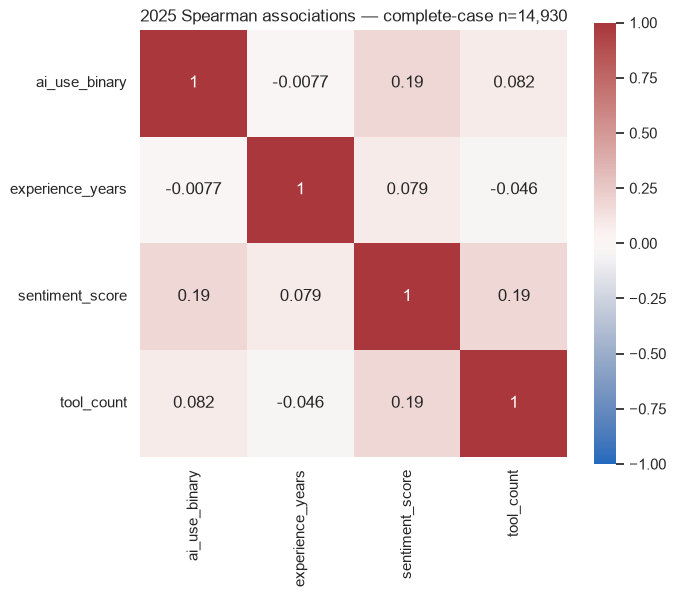

**Heatmap interpretation.** This heatmap compares four defined numeric/ordinal measures in one 2025 complete-case sample (n=14,930). AI use and sentiment have rho=0.186, while use and work experience have rho=-0.008. Requiring an answered model question selects this subset; the correlations do not establish causation.

,pair,n,spearman_rho,p_raw,p_adjusted
0,ai_use_binary vs experience_years,14930,-0.007718,3.456784e-01,3.456784e-01
1,ai_use_binary vs sentiment_score,14930,0.186475,6.570949e-117,1.971285e-116
2,experience_years vs sentiment_score,14930,0.078530,7.288285e-22,1.457657e-21


**Pair interpretation.** `ai_use_binary vs experience_years`: rho=-0.008 (n=14,930; Holm-adjusted p=0.3457). The association is near-zero negative among model-question complete cases; this selected subset differs from the larger experience-test sample. Self-selection and complete-case exclusions prevent a causal interpretation.

**Pair interpretation.** `ai_use_binary vs sentiment_score`: rho=0.186 (n=14,930; Holm-adjusted p=1.971e-116). Current users tend to give more favorable ordered responses, with a positive rank association well below perfect alignment. Self-selection and complete-case exclusions prevent a causal interpretation.

**Pair interpretation.** `experience_years vs sentiment_score`: rho=0.079 (n=14,930; Holm-adjusted p=1.458e-21). More work years correspond to slightly more favorable ordered sentiment; the positive rank association is close to zero. Self-selection and complete-case exclusions prevent a causal interpretation.

In [27]:
corr_cols=['ai_use_binary','experience_years','sentiment_score','tool_count']
corr_data=df[df.SurveyYear.eq(2025)][corr_cols].dropna().astype(float)
assert corr_data.nunique().gt(1).all(), 'Constant correlation field.'
rho=corr_data.corr(method='spearman')
plt.figure(figsize=(7,6)); ax=sns.heatmap(rho,annot=True,vmin=-1,vmax=1,cmap='vlag',center=0,square=True)
ax.set(title=f'2025 Spearman associations — complete-case n={len(corr_data):,}')
finish_figure('correlation_2025')
interpret(f'**Heatmap interpretation.** This heatmap compares four defined numeric/ordinal measures in one 2025 complete-case sample (n={len(corr_data):,}). '
          f'AI use and sentiment have rho={rho.loc["ai_use_binary","sentiment_score"]:.3f}, while use and work experience have rho={rho.loc["ai_use_binary","experience_years"]:.3f}. '
          'Requiring an answered model question selects this subset; the correlations do not establish causation.')
cor_results=[]
for a,b in [('ai_use_binary','experience_years'),('ai_use_binary','sentiment_score'),('experience_years','sentiment_score')]:
    r,p=stats.spearmanr(corr_data[a],corr_data[b])
    cor_results.append({'pair':f'{a} vs {b}','n':len(corr_data),'spearman_rho':float(r),'p_raw':float(p)})
p_adj=multipletests([r['p_raw'] for r in cor_results],method='holm')[1]
for row,p in zip(cor_results,p_adj): row['p_adjusted']=float(p)
corr_table=pd.DataFrame(cor_results)
display(corr_table)
pair_meanings={
    'ai_use_binary vs experience_years':'The association is near-zero negative among model-question complete cases; this selected subset differs from the larger experience-test sample.',
    'ai_use_binary vs sentiment_score':'Current users tend to give more favorable ordered responses, with a positive rank association well below perfect alignment.',
    'experience_years vs sentiment_score':'More work years correspond to slightly more favorable ordered sentiment; the positive rank association is close to zero.'}
for _,r in corr_table.iterrows():
    interpret(f'**Pair interpretation.** `{r["pair"]}`: rho={r.spearman_rho:.3f} '
              f'(n={int(r.n):,}; Holm-adjusted p={p_text(r.p_adjusted)}). '
              +pair_meanings[r['pair']]+' Self-selection and complete-case exclusions prevent a causal interpretation.')
corr_table.to_csv(RESULTS/'correlation_pairs.csv',index=False)

In [28]:
display(Markdown('### 10.1 Complete-case selection diagnostic (2025 correlation)'))
part_2025=df[df.SurveyYear.eq(2025)]
correlation_complete=part_2025[corr_cols].notna().all(axis=1)
source_joint=part_2025[['AISelect','WorkExp','AISent','AIModelsHaveWorkedWith']].notna().all(axis=1)
assert part_2025.loc[correlation_complete].index.equals(corr_data.index)
assert (source_joint | ~correlation_complete).all()
eligibility_rows=[{'analysis':'Correlation eligibility','year':2025,'group':label,'n':int(count)}
    for label,count in [('Total survey records',len(part_2025)),
                        ('Four source questions nonmissing',source_joint.sum()),
                        ('Analytical complete cases',correlation_complete.sum())]]
display(pd.DataFrame(eligibility_rows).drop(columns='analysis'))
display(pd.DataFrame({'Source':['AISelect','WorkExp','AISent','AIModelsHaveWorkedWith'],
                     'Nonmissing n':[int(part_2025[c].count()) for c in ['AISelect','WorkExp','AISent','AIModelsHaveWorkedWith']]}))
# Age, country and role availability do not define the correlation selection rule.
profile_rows=[]
for label,selected in [('Included / complete',correlation_complete),('Excluded / incomplete',~correlation_complete)]:
    sample=part_2025.loc[selected]
    characteristics={
        'Age band':sample.age_h.astype('string').where(sample.age_h.notna(),'Missing/refused'),
        'Country availability':sample.Country.notna().map({True:'Available',False:'Missing'}),
        'Role availability':sample.DevType.notna().map({True:'Available',False:'Missing'}),
        'AI use among valid answers':sample.ai_use_h.dropna()}
    for variable,values in characteristics.items():
        for category,count in values.value_counts().items():
            profile_rows.append({'year':2025,'analysis':'Correlation','group':label,'variable':variable,
                                 'category':category,'count':int(count),'denominator':len(values),
                                 'pct':100*count/len(values)})
complete_case_profiles=pd.DataFrame(profile_rows)
display(complete_case_profiles)
complete_case_profiles.to_csv(RESULTS/'complete_case_profiles.csv',index=False)
age_profile=complete_case_profiles[complete_case_profiles.variable.eq('Age band') &
    complete_case_profiles.category.eq('18-24 years old')].set_index('group')
use_profile=complete_case_profiles[complete_case_profiles.variable.eq('AI use among valid answers') &
    complete_case_profiles.category.eq('Current user')].set_index('group')
interpret(f'**Interpretation.** The correlation uses {int(correlation_complete.sum()):,} analytical complete cases '
          f'from {len(part_2025):,} records, compared with {int(source_joint.sum()):,} joint nonmissing source responses. '
          f'Age 18–24 represents {age_profile.loc["Included / complete","pct"]:.2f}% of included records '
          f'versus {age_profile.loc["Excluded / incomplete","pct"]:.2f}% of incomplete records. '
          f'Among valid AI answers, current use is {use_profile.loc["Included / complete","pct"]:.2f}% '
          f'(n={int(use_profile.loc["Included / complete","denominator"]):,}) versus '
          f'{use_profile.loc["Excluded / incomplete","pct"]:.2f}% '
          f'(n={int(use_profile.loc["Excluded / incomplete","denominator"]):,}).')
interpret('**Selection assessment.** Profiles are systematically different on observed characteristics; '
          'the correlations should be read as conditional on this selected model-question subset. '
          'Differences indicate possible complete-case/nonresponse selection bias, without establishing the missingness mechanism. '
          'Even observed similarity would not prove missingness random. These exclusions do not remove records from df.')
interpret('**Additional correlation sensitivity — NOT ADDED, JUSTIFIED.** A professional-developer restriction '
          'is identifiable from 2025 MainBranch, but changes the target group and does not resolve the observed item-selection issue. '
          'The existing selected-sample correlation and this descriptive profile expose the current concern '
          'without another correlation test family.')

### 10.1 Complete-case selection diagnostic (2025 correlation)

,year,group,n
0,2025,Total survey records,49191
1,2025,Four source questions nonmissing,15076
2,2025,Analytical complete cases,14930


,Source,Nonmissing n
0,AISelect,33720
1,WorkExp,42893
2,AISent,33467
3,AIModelsHaveWorkedWith,16281


,year,analysis,group,variable,category,count,denominator,pct
0,2025,Correlation,Included / complete,Age band,25-34 years old,5478,14930,36.691226
1,2025,Correlation,Included / complete,Age band,35-44 years old,4664,14930,31.239116
2,2025,Correlation,Included / complete,Age band,45-54 years old,2079,14930,13.924983
3,2025,Correlation,Included / complete,Age band,18-24 years old,1846,14930,12.364367
4,2025,Correlation,Included / complete,Age band,55-64 years old,676,14930,4.527796
5,2025,Correlation,Included / complete,Age band,65 years or older,161,14930,1.078366
6,2025,Correlation,Included / complete,Age band,Missing/refused,26,14930,0.174146
7,2025,Correlation,Included / complete,Country availability,Available,14930,14930,100.000000
8,2025,Correlation,Included / complete,Role availability,Available,14930,14930,100.000000
9,2025,Correlation,Included / complete,AI use among valid answers,Current user,14460,14930,96.851976


**Interpretation.** The correlation uses 14,930 analytical complete cases from 49,191 records, compared with 15,076 joint nonmissing source responses. Age 18–24 represents 12.36% of included records versus 21.49% of incomplete records. Among valid AI answers, current use is 96.85% (n=14,930) versus 63.91% (n=18,790).

**Selection assessment.** Profiles are systematically different on observed characteristics; the correlations should be read as conditional on this selected model-question subset. Differences indicate possible complete-case/nonresponse selection bias, without establishing the missingness mechanism. Even observed similarity would not prove missingness random. These exclusions do not remove records from df.

**Additional correlation sensitivity — NOT ADDED, JUSTIFIED.** A professional-developer restriction is identifiable from 2025 MainBranch, but changes the target group and does not resolve the observed item-selection issue. The existing selected-sample correlation and this descriptive profile expose the current concern without another correlation test family.

### Reading the three association pairs

Below the heatmap, we examine AI use with work experience, AI use with sentiment, and work experience with sentiment. We report the direction, magnitude and n for each pair. All three comparisons refer to the same selected 2025 sample.


## 11. Statistical Testing

**Test 1: AI use × experience band.** H0: current AI use is independent of experience band within a release. H1: an association exists. Pearson chi-square is appropriate for categorical counts; remove unobserved bands and check every expected cell count ≥5 before interpreting. Respondent independence is assumed within each year, not established by the data. Report Cramér's V first because large samples detect small associations.

**Test 2: 2025 experience distributions.** H0: the professional work-experience distribution is the same for current users and nonusers. H1: the distributions differ. Mann–Whitney U handles skewed, tied year counts without a normality/equal-variance requirement. Its effect is a rank-biserial correlation; a distributional difference need not be a pure median difference.

Use α=0.05. Apply Holm correction across all four prespecified hypothesis tests (three annual chi-square tests and one Mann–Whitney test). Exploratory Spearman p-values are corrected within their separate three-pair family; they remain exploratory.

In [29]:
chi_rows=[]
for y in YEARS:
    z=df[df.SurveyYear.eq(y)].dropna(subset=['ai_use_h','experience_band'])
    table=pd.crosstab(z.experience_band,z.ai_use_h)
    table=table.loc[table.sum(axis=1)>0,table.sum(axis=0)>0]
    chi2,p,dof,expected=stats.chi2_contingency(table,correction=False)
    assert (expected>=5).all(), 'Merge bands or use an exact method before interpreting chi-square.'
    n=int(table.to_numpy().sum())
    v=float(np.sqrt(chi2/(n*min(table.shape[0]-1,table.shape[1]-1))))
    chi_rows.append({'test':f'Chi-square {y}','year':y,'n':n,'statistic':float(chi2),'df':int(dof),
        'p_raw':float(p),'min_expected':float(expected.min()),'effect_name':"Cramer's V",'effect_size':v})
    display(table)
    interpret(f'**Assumptions.** {y}: n={n:,}, minimum expected count={expected.min():.2f}; all expected counts ≥5. '
              'Each respondent contributes once within this year; independence and self-selection cannot be verified from the CSV.')
chi_results=pd.DataFrame(chi_rows)


ai_use_h,Current user,Not current user
experience_band,,
<1 year,989,847
1–5 years,10222,9978
6–10 years,7228,10119
11+ years,9266,17487


**Assumptions.** 2023: n=66,136, minimum expected count=769.12; all expected counts ≥5. Each respondent contributes once within this year; independence and self-selection cannot be verified from the CSV.

ai_use_h,Current user,Not current user
experience_band,,
<1 year,1923,820
1–5 years,11896,5157
6–10 years,7695,4675
11+ years,9632,8500


**Assumptions.** 2024: n=50,298, minimum expected count=1044.45; all expected counts ≥5. Each respondent contributes once within this year; independence and self-selection cannot be verified from the CSV.

ai_use_h,Current user,Not current user
experience_band,,
1–5 years,6672,1360
6–10 years,5642,1245
11+ years,12253,3932


**Assumptions.** 2025: n=31,104, minimum expected count=1447.41; all expected counts ≥5. Each respondent contributes once within this year; independence and self-selection cannot be verified from the CSV.

### Distribution checks and the rank comparison

We report each group’s n, median, quartiles, variance and skewness, followed by normality and variance checks. With large samples, even small departures can produce significant diagnostic results. We use the prespecified Mann–Whitney test because the outcome is skewed and contains many ties, and interpret it as a comparison of distributions.


In [30]:
z=df[df.SurveyYear.eq(2025)].dropna(subset=['experience_years','ai_use_binary'])
users=z.loc[z.ai_use_binary.eq(1),'experience_years'].to_numpy(dtype=float)
nonusers=z.loc[z.ai_use_binary.eq(0),'experience_years'].to_numpy(dtype=float)
assert len(users)>1 and len(nonusers)>1
# Diagnostics: tests can flag tiny deviations at large n; report distributions and do not assume normality.
diagnostics=[]
for label,values in [('Current users',users),('Nonusers',nonusers)]:
    normal=stats.normaltest(values)
    diagnostics.append({'group':label,'n':len(values),'median':float(np.median(values)),
        'q25':float(np.quantile(values,.25)),'q75':float(np.quantile(values,.75)),
        'variance':float(np.var(values,ddof=1)),'skewness':float(stats.skew(values)),
        'normality_statistic':float(normal.statistic),'normality_p':float(normal.pvalue)})
variance_check=stats.levene(users,nonusers,center='median')
diagnostics=pd.DataFrame(diagnostics); display(diagnostics)
interpret('**Diagnostic precision.** A stored p-value of 0 means floating-point underflow, not zero probability. '
          'For current users the normality p-value is '+p_text(diagnostics.iloc[0].normality_p)+
          '; n='+str(int(diagnostics.iloc[0].n))+'. Diagnostics do not change the prespecified rank test.')
print(f'Brown–Forsythe variance check: statistic={variance_check.statistic:.4f}, p={p_text(variance_check.pvalue)}, n={len(z):,}')
U,p=stats.mannwhitneyu(users,nonusers,alternative='two-sided',method='asymptotic')
rb=float(2*U/(len(users)*len(nonusers))-1)
mw_result={'test':'Mann–Whitney 2025','year':2025,'n':len(z),'statistic':float(U),'df':np.nan,
           'p_raw':float(p),'min_expected':np.nan,'effect_name':'Rank-biserial (users > nonusers)','effect_size':rb}
# One prespecified family: three annual chi-square tests and one user/nonuser comparison.
test_results=pd.DataFrame(chi_rows+[mw_result])
test_results['p_adjusted']=multipletests(test_results.p_raw,alpha=ALPHA,method='holm')[1]
test_results['reject_H0']=test_results.p_adjusted.lt(ALPHA)
display(test_results)
for _,r in test_results.iterrows():
    is_chi=r.test.startswith('Chi')
    question=(f'RQ7: Is current AI use associated with experience band in {int(r.year)}?' if is_chi else
              'RQ8: Do current users and nonusers have different work-experience distributions in 2025?')
    null=('Current AI use is independent of experience band within this release.' if is_chi else
          'The two groups have the same professional work-experience distribution.')
    alternative=('An association exists.' if is_chi else 'The distributions differ.')
    why=('Categorical frequency counts form an experience × use contingency table.' if is_chi else
         'Work years are skewed and tied; ranks compare distributions without requiring normality.')
    assumptions=(f'One record per within-year ID; all expected cells ≥5 (minimum {r.min_expected:.2f}); respondent independence assumed.' if is_chi else
                 f'Independent groups assumed; numeric/ordered outcome; ties corrected asymptotically; group n={len(users):,} and {len(nonusers):,}; normality/equal variance not required. Diagnostics shown above.')
    interpretation=(f'Use varies by experience band among these respondents; V={r.effect_size:.4f} quantifies the association. Statistical evidence does not by itself establish practical importance; no universal magnitude threshold is applied.' if is_chi else
                    f'Users tend to report fewer work years: medians {np.median(users):.1f} versus {np.median(nonusers):.1f}; IQRs {np.quantile(users,.25):.1f}–{np.quantile(users,.75):.1f} versus {np.quantile(nonusers,.25):.1f}–{np.quantile(nonusers,.75):.1f}; rank-biserial={rb:.4f}. The test concerns distributions, not only medians, and statistical significance alone does not establish practical importance.')
    limitation=('Self-selection and coding/work construct changes limit generalization and comparisons across years.' if is_chi else
                'Self-selection, missing experience and potentially unequal distribution shapes limit interpretation; no causal claim.')
    interpret(f'### {r.test} — n={int(r.n):,}\n\n'
              f'- **Research Question:** {question}\n'
              f'- **H0:** {null}\n- **H1:** {alternative}\n'
              f'- **Why this test:** {why}\n- **Assumptions:** {assumptions}\n'
              f'- **Alpha:** {ALPHA}; Holm correction across the four primary tests.\n'
              f'- **Effect size:** {r.effect_name}={r.effect_size:.4f}.\n'
              f'- **Test statistic:** {r.statistic:.3f}.\n'
              f'- **Degrees of freedom:** {int(r["df"]) if is_chi else "Not applicable"}.\n'
              f'- **p-value:** raw {p_text(r.p_raw)}; Holm-adjusted {p_text(r.p_adjusted)}.\n'
              f'- **Decision:** {"Reject" if r.reject_H0 else "Do not reject"} H0.\n'
              f'- **Plain-language interpretation:** {interpretation}\n'
              f'- **Limitation:** {limitation}')
interpret(f'**Mann–Whitney interpretation.** Median professional work experience is {np.median(users):.1f} years for '
          f'users (n={len(users):,}) and {np.median(nonusers):.1f} years for nonusers (n={len(nonusers):,}). '
          f'Rank-biserial={rb:.4f}; negative values indicate users tend to report fewer years. '
          'The test compares ranks/distributions; unequal shapes prevent reading it solely as a median test. '
          'Normality and equal variance are not required. Repeated integer years create ties, handled by the asymptotic correction.')
# Sensitivity to the analyst-selected upper range limit: include every finite nonnegative whole-year value.
sensitivity=df[df.SurveyYear.eq(2025)].copy()
sensitivity['all_years']=parsed.loc[sensitivity.index].where(parsed.loc[sensitivity.index].ge(0)&valid_fraction.loc[sensitivity.index])
sensitivity=sensitivity.dropna(subset=['all_years','ai_use_binary'])
x=sensitivity.loc[sensitivity.ai_use_binary.eq(1),'all_years']; yy=sensitivity.loc[sensitivity.ai_use_binary.eq(0),'all_years']
su=stats.mannwhitneyu(x,yy,alternative='two-sided',method='asymptotic')
sensitivity_result={'n':len(sensitivity),'rank_biserial':float(2*su.statistic/(len(x)*len(yy))-1),'p_raw':float(su.pvalue)}
print('Sensitivity (no 70-year upper cap; same substantive question, not a new primary test):',sensitivity_result)
test_results.to_csv(RESULTS/'statistical_tests.csv',index=False)
diagnostics.to_csv(RESULTS/'distribution_diagnostics.csv',index=False)

,group,n,median,q25,q75,variance,skewness,normality_statistic,normality_p
0,Current users,24567,10.0,5.0,20.0,102.550866,1.044748,3476.626855,0.000000e+00
1,Nonusers,6537,14.0,7.0,25.0,148.051081,0.798305,546.592932,2.036352e-119


**Diagnostic precision.** A stored p-value of 0 means floating-point underflow, not zero probability. For current users the normality p-value is < 1e-300 (numerical underflow); n=24567. Diagnostics do not change the prespecified rank test.

Brown–Forsythe variance check: statistic=346.3399, p=6.954e-77, n=31,104


,test,year,n,statistic,df,p_raw,min_expected,effect_name,effect_size,p_adjusted,reject_H0
0,Chi-square 2023,2023,66136,1.317078e+03,3.0,2.898929e-285,769.117878,Cramer's V,0.141119,1.159572e-284,True
1,Chi-square 2024,2024,50298,1.118125e+03,3.0,4.253756e-242,1044.453775,Cramer's V,0.149097,1.276127e-241,True
2,Chi-square 2025,2025,31104,2.212928e+02,2.0,8.848738e-49,1447.412519,Cramer's V,0.084348,8.848738e-49,True
3,Mann–Whitney 2025,2025,31104,6.803264e+07,NaN,1.043747e-80,NaN,Rank-biserial (users > nonusers),-0.152740,2.087494e-80,True


### Chi-square 2023 — n=66,136

- **Research Question:** RQ7: Is current AI use associated with experience band in 2023?
- **H0:** Current AI use is independent of experience band within this release.
- **H1:** An association exists.
- **Why this test:** Categorical frequency counts form an experience × use contingency table.
- **Assumptions:** One record per within-year ID; all expected cells ≥5 (minimum 769.12); respondent independence assumed.
- **Alpha:** 0.05; Holm correction across the four primary tests.
- **Effect size:** Cramer's V=0.1411.
- **Test statistic:** 1317.078.
- **Degrees of freedom:** 3.
- **p-value:** raw 2.899e-285; Holm-adjusted 1.16e-284.
- **Decision:** Reject H0.
- **Plain-language interpretation:** Use varies by experience band among these respondents; V=0.1411 quantifies the association. Statistical evidence does not by itself establish practical importance; no universal magnitude threshold is applied.
- **Limitation:** Self-selection and coding/work construct changes limit generalization and comparisons across years.

### Chi-square 2024 — n=50,298

- **Research Question:** RQ7: Is current AI use associated with experience band in 2024?
- **H0:** Current AI use is independent of experience band within this release.
- **H1:** An association exists.
- **Why this test:** Categorical frequency counts form an experience × use contingency table.
- **Assumptions:** One record per within-year ID; all expected cells ≥5 (minimum 1044.45); respondent independence assumed.
- **Alpha:** 0.05; Holm correction across the four primary tests.
- **Effect size:** Cramer's V=0.1491.
- **Test statistic:** 1118.125.
- **Degrees of freedom:** 3.
- **p-value:** raw 4.254e-242; Holm-adjusted 1.276e-241.
- **Decision:** Reject H0.
- **Plain-language interpretation:** Use varies by experience band among these respondents; V=0.1491 quantifies the association. Statistical evidence does not by itself establish practical importance; no universal magnitude threshold is applied.
- **Limitation:** Self-selection and coding/work construct changes limit generalization and comparisons across years.

### Chi-square 2025 — n=31,104

- **Research Question:** RQ7: Is current AI use associated with experience band in 2025?
- **H0:** Current AI use is independent of experience band within this release.
- **H1:** An association exists.
- **Why this test:** Categorical frequency counts form an experience × use contingency table.
- **Assumptions:** One record per within-year ID; all expected cells ≥5 (minimum 1447.41); respondent independence assumed.
- **Alpha:** 0.05; Holm correction across the four primary tests.
- **Effect size:** Cramer's V=0.0843.
- **Test statistic:** 221.293.
- **Degrees of freedom:** 2.
- **p-value:** raw 8.849e-49; Holm-adjusted 8.849e-49.
- **Decision:** Reject H0.
- **Plain-language interpretation:** Use varies by experience band among these respondents; V=0.0843 quantifies the association. Statistical evidence does not by itself establish practical importance; no universal magnitude threshold is applied.
- **Limitation:** Self-selection and coding/work construct changes limit generalization and comparisons across years.

### Mann–Whitney 2025 — n=31,104

- **Research Question:** RQ8: Do current users and nonusers have different work-experience distributions in 2025?
- **H0:** The two groups have the same professional work-experience distribution.
- **H1:** The distributions differ.
- **Why this test:** Work years are skewed and tied; ranks compare distributions without requiring normality.
- **Assumptions:** Independent groups assumed; numeric/ordered outcome; ties corrected asymptotically; group n=24,567 and 6,537; normality/equal variance not required. Diagnostics shown above.
- **Alpha:** 0.05; Holm correction across the four primary tests.
- **Effect size:** Rank-biserial (users > nonusers)=-0.1527.
- **Test statistic:** 68032635.000.
- **Degrees of freedom:** Not applicable.
- **p-value:** raw 1.044e-80; Holm-adjusted 2.087e-80.
- **Decision:** Reject H0.
- **Plain-language interpretation:** Users tend to report fewer work years: medians 10.0 versus 14.0; IQRs 5.0–20.0 versus 7.0–25.0; rank-biserial=-0.1527. The test concerns distributions, not only medians, and statistical significance alone does not establish practical importance.
- **Limitation:** Self-selection, missing experience and potentially unequal distribution shapes limit interpretation; no causal claim.

**Mann–Whitney interpretation.** Median professional work experience is 10.0 years for users (n=24,567) and 14.0 years for nonusers (n=6,537). Rank-biserial=-0.1527; negative values indicate users tend to report fewer years. The test compares ranks/distributions; unequal shapes prevent reading it solely as a median test. Normality and equal variance are not required. Repeated integer years create ties, handled by the asymptotic correction.

Sensitivity (no 70-year upper cap; same substantive question, not a new primary test): {'n': 31122, 'rank_biserial': -0.1531304159941077, 'p_raw': 3.4752589604040546e-81}


In [31]:
display(Markdown('### 11.1 Sensitivity to 2025 experience-band boundaries'))
interpret('The main bands remain unchanged. The [official 2025 AI page](https://survey.stackoverflow.co/2025/ai) '
          'labels career groups 1–5, 5–10 and 10+, without resolving the shared endpoints. '
          'Our nonoverlapping sensitivity uses [1,5), [5,10), [10,71): integer years 1–4, 5–9 and 10+. '
          'Exactly 5 belongs to the middle group and 10 to the highest. [0,1) is retained if observed. '
          'This approximates the published structure; it does not reproduce an undocumented boundary rule.')
band_data=part_2025.dropna(subset=['experience_years','ai_use_binary']).copy()
alternative_bands=pd.cut(band_data.experience_years,[0,1,5,10,71],right=False,
                         labels=['<1 year','1–4 years','5–9 years','10+ years'])
assert alternative_bands.notna().all()
assert pd.cut(pd.Series([0,.5,1,4,5,9,10,70]),[0,1,5,10,71],right=False,
    labels=['<1 year','1–4 years','5–9 years','10+ years']).astype(str).tolist()==[
    '<1 year','<1 year','1–4 years','1–4 years','5–9 years','5–9 years','10+ years','10+ years']
band_rows=[];band_rates={}
for grouping,bands in [('Main',band_data.experience_band),('Alternative',alternative_bands)]:
    tab=pd.crosstab(bands,band_data.ai_use_binary)
    tab=tab.loc[tab.sum(axis=1).gt(0)]
    chi,_,dof,expected=stats.chi2_contingency(tab,correction=False)
    assert expected.min()>=5 and int(tab.to_numpy().sum())==len(band_data)
    v=float(np.sqrt(chi/(len(band_data)*min(tab.shape[0]-1,tab.shape[1]-1))))
    band_rates[grouping]=100*tab[1]/tab.sum(axis=1)
    for band,row in tab.iterrows():
        band_rows.append({'analysis':'Experience banding','year':2025,'group':grouping,'band':str(band),
            'n':int(row.sum()),'users':int(row[1]),'pct':100*row[1]/row.sum(),
            'analysis_n':len(band_data),'chi_square':chi,'df':dof,'min_expected':float(expected.min()),'cramers_v':v})
band_robustness=pd.DataFrame(band_rows)
# STABLE concerns the ordered direction only; exact rates and V need not agree.
descending={name:rates.is_monotonic_decreasing for name,rates in band_rates.items()}
same_extremes=all(rates.iloc[0]==rates.max() and rates.iloc[-1]==rates.min() for rates in band_rates.values())
band_outcome=('STABLE' if all(descending.values()) else
              'PARTIALLY STABLE' if same_extremes else 'SENSITIVE TO BANDING')
band_robustness['outcome']=band_outcome
display(band_robustness.drop(columns='analysis'))
main_v=band_robustness[band_robustness.group.eq('Main')].cramers_v.iloc[0]
alternative_v=band_robustness[band_robustness.group.eq('Alternative')].cramers_v.iloc[0]
interpret(f'**Banding result: {band_outcome}.** Both groupings use n={len(band_data):,}; '
          f'Cramér’s V is {main_v:.4f} with the main bands and {alternative_v:.4f} with the alternative. '
          f'The ordered descending pattern is present in main={descending["Main"]} and alternative={descending["Alternative"]}. '
          'The classification concerns direction, not identical percentages or effect magnitude. '
          'This within-year diagnostic cannot resolve the coding/work construct difference or missing zero-year answers; '
          'no new p-value claim is added to the primary Holm family.')
robustness_checks=pd.concat([geography_robustness,band_robustness,pd.DataFrame(eligibility_rows)],ignore_index=True)
robustness_checks.to_csv(RESULTS/'robustness_checks.csv',index=False)

### 11.1 Sensitivity to 2025 experience-band boundaries

The main bands remain unchanged. The [official 2025 AI page](https://survey.stackoverflow.co/2025/ai) labels career groups 1–5, 5–10 and 10+, without resolving the shared endpoints. Our nonoverlapping sensitivity uses [1,5), [5,10), [10,71): integer years 1–4, 5–9 and 10+. Exactly 5 belongs to the middle group and 10 to the highest. [0,1) is retained if observed. This approximates the published structure; it does not reproduce an undocumented boundary rule.

,year,group,band,n,users,pct,analysis_n,chi_square,df,min_expected,cramers_v,outcome
0,2025,Main,1–5 years,8032,6672,83.067729,31104,221.292790,2,1447.412519,0.084348,STABLE
1,2025,Main,6–10 years,6887,5642,81.922463,31104,221.292790,2,1447.412519,0.084348,STABLE
2,2025,Main,11+ years,16185,12253,75.705901,31104,221.292790,2,1447.412519,0.084348,STABLE
3,2025,Alternative,1–4 years,6326,5268,83.275371,31104,185.337377,2,1329.509452,0.077192,STABLE
4,2025,Alternative,5–9 years,6562,5390,82.139592,31104,185.337377,2,1329.509452,0.077192,STABLE
5,2025,Alternative,10+ years,18216,13909,76.355951,31104,185.337377,2,1329.509452,0.077192,STABLE


**Banding result: STABLE.** Both groupings use n=31,104; Cramér’s V is 0.0843 with the main bands and 0.0772 with the alternative. The ordered descending pattern is present in main=True and alternative=True. The classification concerns direction, not identical percentages or effect magnitude. This within-year diagnostic cannot resolve the coding/work construct difference or missing zero-year answers; no new p-value claim is added to the primary Holm family.

### Scope of the analysis

We focus on describing survey patterns and testing associations. The handbook’s optional baseline comparison requires instructor approval, which has not been supplied. Prediction remains outside scope.

## 12. Communication and Responsible Interpretation

The summary below brings together the main results. Each finding uses numbers calculated in the notebook. We interpret the size of an association alongside its p-value and sample size.

In [32]:
summary=adoption_summary.copy()
display(summary)
first=summary.iloc[0]; last=summary.iloc[-1]
primary_tool_findings=[]
for y in YEARS:
    leader=top_tools[top_tools.year.eq(y) & top_tools.source.eq(PRIMARY_TOOL[y])].iloc[0]
    primary_tool_findings.append(f'{y} {leader.choice}: {leader.respondent_pct:.2f}% '
                                 f'({int(leader.selected_n):,}/{int(leader.question_n):,} question answerers)')
findings=[f'Current AI use increased from {first.current_use_pct:.2f}% (2023; n={int(first.n):,}) '
          f'to {last.current_use_pct:.2f}% (2025; n={int(last.n):,}), a {last.current_use_pct-first.current_use_pct:.2f}-point difference among valid answers.',
          'Bangladesh current-use estimates: '+', '.join(f'{int(r.year)} {r.pct:.2f}% (n={int(r.n):,})' for _,r in bd[bd["sample"].eq('Bangladesh')].iterrows())+'.',
          'Favorable sentiment with Indifferent and Unsure retained in the denominator: '+', '.join(f'{int(r.year)} {r.favorable_pct:.2f}% (n={int(r.n):,})' for _,r in sentiment_summary.iterrows())+'.',
          'Trust in AI output: '+', '.join(f'{int(r.year)} {r.trust_pct:.2f}% (n={int(r.n):,})' for _,r in trust_summary.iterrows())+'.',
          'Experience/use associations: '+', '.join(f'{int(r.year)} V={r.effect_size:.4f} (n={int(r.n):,})' for _,r in test_results[test_results.test.str.startswith('Chi')].iterrows())+'.',
          f'2025 user/nonuser work experience: rank-biserial={rb:.4f}; medians {np.median(users):.1f} vs {np.median(nonusers):.1f} years (n={len(z):,}).',
          'Most selected primary product/model per year: '+', '.join(primary_tool_findings)+'. Prompts differ, so this is not a like-for-like product trend.']
assert pd.util.hash_pandas_object(raw_df,index=True).sum()==raw_fingerprint, 'raw_df was changed.'

# Seven rows map the findings to the research questions; all numerical text comes from computed tables.
role_2025=role_summary[role_summary.year.eq(2025)]
high_role=role_2025.loc[role_2025.current_use_pct.idxmax()]
low_role=role_2025.loc[role_2025.current_use_pct.idxmin()]
role_finding=(f'Among the ten largest 2025 roles, {high_role.DevType}: {high_role.current_use_pct:.2f}% '
              f'(n={int(high_role.n):,}); {low_role.DevType}: {low_role.current_use_pct:.2f}% (n={int(low_role.n):,}).')
findings=[findings[0],findings[1],findings[2]+' '+findings[3],findings[4],findings[5],findings[6],role_finding]
summary_results=pd.DataFrame([
    {'Research Question':'RQ1 — Current use by year','Key Result':findings[0],'Statistical Evidence':'Descriptive proportions; see annual denominators','Interpretation':'Differences between annual respondent samples; not within-person change'},
    {'Research Question':'RQ6 — Bangladesh vs Global','Key Result':findings[1],'Statistical Evidence':'Wilson intervals under a binomial model; no country test','Interpretation':'Bangladesh overlaps Global; small voluntary country samples'},
    {'Research Question':'RQ4 — Sentiment by year/experience; supporting trust','Key Result':findings[2],'Statistical Evidence':'Full 100% distributions and denominator sensitivity','Interpretation':'Favorable uses all valid sentiment answers; trust measures reported confidence'},
    {'Research Question':'RQ2 / RQ7 — Experience and current use','Key Result':findings[3],'Statistical Evidence':f'{len(chi_results)} chi-square tests; {int(test_results[test_results.test.str.startswith("Chi")].reject_H0.sum())} reject H0 after Holm correction at alpha={ALPHA}; expected counts ≥5','Interpretation':'Within-year V reported numerically; significance is not practical importance; experience constructs differ'},
    {'Research Question':'RQ8 — User/nonuser experience','Key Result':findings[4],'Statistical Evidence':f'U={U:,.0f}; Holm-adjusted p={p_text(test_results.iloc[-1].p_adjusted)}','Interpretation':'Rank/distribution difference; no causal direction established'},
    {'Research Question':'RQ3 — Top products/models','Key Result':findings[5],'Statistical Evidence':'Top-N selection counts and question-specific n','Interpretation':'Different prompts; mention shares differ from respondent percentages'},
    {'Research Question':'RQ5 — Main-role comparisons','Key Result':findings[6],'Statistical Evidence':'Descriptive rates within the ten largest role groups','Interpretation':'Role lists and respondent composition differ; no isolated role effect'},
])
assert len(summary_results)==7
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(summary_results)
summary_results.to_csv(RESULTS/'summary_results.csv',index=False)
for i,finding in enumerate(findings,1): interpret(f'{i}. {finding}')

,SurveyYear,n,current_users,current_use_pct,lower_pct,upper_pct
0,2023,87973,39042.0,44.379526,44.051470,44.708072
1,2024,60907,37662.0,61.835257,61.448721,62.220301
2,2025,33720,26469.0,78.496441,78.054693,78.931697


,Research Question,Key Result,Statistical Evidence,Interpretation
0,RQ1 — Current use by year,"Current AI use increased from 44.38% (2023; n=87,973) to 78.50% (2025; n=33,720), a 34.12-point difference among valid answers.",Descriptive proportions; see annual denominators,Differences between annual respondent samples; not within-person change
1,RQ6 — Bangladesh vs Global,"Bangladesh current-use estimates: 2023 57.96% (n=490), 2024 71.91% (n=324), 2025 88.14% (n=194).",Wilson intervals under a binomial model; no country test,Bangladesh overlaps Global; small voluntary country samples
2,RQ4 — Sentiment by year/experience; supporting trust,"Favorable sentiment with Indifferent and Unsure retained in the denominator: 2023 76.28% (n=61,501), 2024 71.97% (n=45,873), 2025 59.72% (n=33,467). Trust in AI output: 2023 42.15% (n=61,396), 2024 43.04% (n=37,302), 2025 32.79% (n=33,297).",Full 100% distributions and denominator sensitivity,Favorable uses all valid sentiment answers; trust measures reported confidence
3,RQ2 / RQ7 — Experience and current use,"Experience/use associations: 2023 V=0.1411 (n=66,136), 2024 V=0.1491 (n=50,298), 2025 V=0.0843 (n=31,104).",3 chi-square tests; 3 reject H0 after Holm correction at alpha=0.05; expected counts ≥5,Within-year V reported numerically; significance is not practical importance; experience constructs differ
4,RQ8 — User/nonuser experience,"2025 user/nonuser work experience: rank-biserial=-0.1527; medians 10.0 vs 14.0 years (n=31,104).","U=68,032,635; Holm-adjusted p=2.087e-80",Rank/distribution difference; no causal direction established
5,RQ3 — Top products/models,"Most selected primary product/model per year: 2023 GitHub Copilot: 85.23% (22,078/25,904 question answerers), 2024 ChatGPT: 85.31% (37,923/44,453 question answerers), 2025 openAI GPT (chatbot models): 82.45% (13,424/16,281 question answerers). Prompts differ, so this is not a like-for-like product trend.",Top-N selection counts and question-specific n,Different prompts; mention shares differ from respondent percentages
6,RQ5 — Main-role comparisons,"Among the ten largest 2025 roles, Developer, front-end: 86.86% (n=1,484); Developer, embedded applications or devices: 65.16% (n=1,016).",Descriptive rates within the ten largest role groups,Role lists and respondent composition differ; no isolated role effect


1. Current AI use increased from 44.38% (2023; n=87,973) to 78.50% (2025; n=33,720), a 34.12-point difference among valid answers.

2. Bangladesh current-use estimates: 2023 57.96% (n=490), 2024 71.91% (n=324), 2025 88.14% (n=194).

3. Favorable sentiment with Indifferent and Unsure retained in the denominator: 2023 76.28% (n=61,501), 2024 71.97% (n=45,873), 2025 59.72% (n=33,467). Trust in AI output: 2023 42.15% (n=61,396), 2024 43.04% (n=37,302), 2025 32.79% (n=33,297).

4. Experience/use associations: 2023 V=0.1411 (n=66,136), 2024 V=0.1491 (n=50,298), 2025 V=0.0843 (n=31,104).

5. 2025 user/nonuser work experience: rank-biserial=-0.1527; medians 10.0 vs 14.0 years (n=31,104).

6. Most selected primary product/model per year: 2023 GitHub Copilot: 85.23% (22,078/25,904 question answerers), 2024 ChatGPT: 85.31% (37,923/44,453 question answerers), 2025 openAI GPT (chatbot models): 82.45% (13,424/16,281 question answerers). Prompts differ, so this is not a like-for-like product trend.

7. Among the ten largest 2025 roles, Developer, front-end: 86.86% (n=1,484); Developer, embedded applications or devices: 65.16% (n=1,016).

In [33]:
display(Markdown('### Methodological robustness summary'))
robustness_summary=pd.DataFrame([
    ['Bangladesh overlaps Global','PARTIALLY REDUCIBLE','Retain required descriptive comparison',
     'Bangladesh vs Rest of World with Wilson intervals',geo_outcome,
     'Small self-selected Bangladesh sample; 2024 missing country changes the eligible universe'],
    ['Experience construct and bands','PARTIALLY REDUCIBLE','Within-year main bands; source labels',
     'One explicit alternative 2025 grouping',f'{band_outcome} direction; V {main_v:.4f} → {alternative_v:.4f}',
     'Coding/work constructs differ; zero-year WorkExp blanks cannot be recovered'],
    ['Complete-case selection','PARTIALLY REDUCIBLE','Item-specific complete cases, no imputation',
     '2025 correlation included vs excluded profiles','Observed age, availability and use profiles differ',
     'Unobserved missingness mechanism and nonresponse bias remain'],
    ['Self-selection','INTRINSIC','Claims restricted to survey respondents',
     'Recruitment documentation; no invented weights','Cannot be removed by increasing n',
     'No probability-based population generalization'],
    ['Changing tool questions','PARTIALLY REDUCIBLE','Four question-specific indicator blocks/rankings',
     'Schema-backed question-universe table; every nullable indicator validated',
     f'{tool_indicator_n} choices preserved; no missing-to-zero conversion',
     'Products/models and routing are not fully longitudinally comparable'],
    ['Large-N significance','REDUCIBLE','Holm p-values plus effect sizes',
     'Numeric V/rank-biserial; MW quartiles; no automatic V thresholds',
     'Primary numerical results unchanged; interpretation emphasizes magnitude',
     'Practical importance still requires substantive context'],
    ['Repeated cross-sectional design','INTRINSIC','Associations and annual respondent distributions',
     'Causal/panel language review','No affirmative causal or person-level change claims',
     'No individual longitudinal inference or causal identification'],
    ['Sentiment denominator','PARTIALLY REDUCIBLE','All valid categories retained',
     'Existing without-Indifferent sensitivity; favorable mapping check',
     'Denominators and shares unchanged; zero means not classified favorable',
     'Identical labels do not establish identical routing'],
    ['Archive/profile discrepancy','INTRINSIC','Use verified archive without guessed filtering',
     'Existing byte/hash checks and documented count differences','Source records unchanged',
     'Cause of published-total differences is not established'],
],columns=['Concern','Type','Main treatment','Robustness / diagnostic check','Outcome','Remaining limitation'])
with pd.option_context('display.max_colwidth',None,'display.max_columns',None):
    display(robustness_summary)
interpret('Reducible checks test analysis choices. Partially reducible concerns can be exposed or bounded, '
          'but the diagnostic does not eliminate their underlying bias. Intrinsic survey-design limitations remain; '
          'a larger respondent count cannot turn self-selected recruitment into a probability sample.')

### Methodological robustness summary

,Concern,Type,Main treatment,Robustness / diagnostic check,Outcome,Remaining limitation
0,Bangladesh overlaps Global,PARTIALLY REDUCIBLE,Retain required descriptive comparison,Bangladesh vs Rest of World with Wilson intervals,Higher Bangladesh estimate in every release,Small self-selected Bangladesh sample; 2024 missing country changes the eligible universe
1,Experience construct and bands,PARTIALLY REDUCIBLE,Within-year main bands; source labels,One explicit alternative 2025 grouping,STABLE direction; V 0.0843 → 0.0772,Coding/work constructs differ; zero-year WorkExp blanks cannot be recovered
2,Complete-case selection,PARTIALLY REDUCIBLE,"Item-specific complete cases, no imputation",2025 correlation included vs excluded profiles,"Observed age, availability and use profiles differ",Unobserved missingness mechanism and nonresponse bias remain
3,Self-selection,INTRINSIC,Claims restricted to survey respondents,Recruitment documentation; no invented weights,Cannot be removed by increasing n,No probability-based population generalization
4,Changing tool questions,PARTIALLY REDUCIBLE,Four question-specific indicator blocks/rankings,Schema-backed question-universe table; every nullable indicator validated,63 choices preserved; no missing-to-zero conversion,Products/models and routing are not fully longitudinally comparable
5,Large-N significance,REDUCIBLE,Holm p-values plus effect sizes,Numeric V/rank-biserial; MW quartiles; no automatic V thresholds,Primary numerical results unchanged; interpretation emphasizes magnitude,Practical importance still requires substantive context
6,Repeated cross-sectional design,INTRINSIC,Associations and annual respondent distributions,Causal/panel language review,No affirmative causal or person-level change claims,No individual longitudinal inference or causal identification
7,Sentiment denominator,PARTIALLY REDUCIBLE,All valid categories retained,Existing without-Indifferent sensitivity; favorable mapping check,Denominators and shares unchanged; zero means not classified favorable,Identical labels do not establish identical routing
8,Archive/profile discrepancy,INTRINSIC,Use verified archive without guessed filtering,Existing byte/hash checks and documented count differences,Source records unchanged,Cause of published-total differences is not established


Reducible checks test analysis choices. Partially reducible concerns can be exposed or bounded, but the diagnostic does not eliminate their underlying bias. Intrinsic survey-design limitations remain; a larger respondent count cannot turn self-selected recruitment into a probability sample.

### Limitations and ethics

1. Voluntary participation produces coverage and self-selection bias; estimates describe survey respondents. Recruitment through Stack Overflow channels is not random; increasing n cannot remove this selection mechanism.
2. Annual files contain different respondents rather than a tracked panel; overlap across years is unknown.
3. Question wording, options, routing and release filtering can change. The official profile and archive totals differ.
4. 2025 professional work experience is broader than professional coding experience in 2023–24, with blank answers requested for zero. Within-year experience comparisons are primary.
5. Detailed tool products, combined tools and LLM models are different question constructs. Mention counts cannot be compared as a common time series.
6. Bangladesh has small, self-selected samples and overlaps the global series. Simple Wilson intervals cannot correct this bias; no small country subgroups or inferential country tests are used.
7. Missing answers may reflect routing and voluntary skips. Complete-case analysis can select respondents with different attitudes.
8. The analysis range (0–70 years) and approximate <1/>50 conversions affect experience summaries; sensitivity is reported.
9. Large samples make small effects significant. Lead with effect sizes, and avoid causal or AI-productivity claims.
10. Agent-impact productivity items in 2025 have a selected answer universe. Nonmissing impact answers do not by themselves establish agent use; any future agent-user analysis needs an explicit verified agent-use restriction and routing review. No general AI→productivity comparison is attempted.
11. Respect attribution and ODbL share-alike terms for adapted databases; analyze aggregate patterns without attempting re-identification.


## 13. Exporting the Cleaned Data

Export the core harmonized measures plus nullable main-role and per-question multi-select indicators. The dictionary describes every exported column. Read back both files and verify schema, IDs, values and missingness. Raw files remain unchanged.

In [34]:
processed=ROOT/'data'/'processed'; processed.mkdir(parents=True,exist_ok=True)
export_cols=['SurveyYear','ResponseId','Country','Age','DevType','AISelect','AISent','trust_accuracy_h',
             'experience_input','experience_source','experience_years','experience_band','ai_use_h','ai_use_binary','sentiment_score','favorable_sentiment','tool_count']
# Nullable role and per-question tool indicators are actual deliverables, not just temporary chart variables.
all_tool_flags=pd.concat([block.reindex(df.index) for block in tool_blocks.values()],axis=1)
clean_export=pd.concat([df[export_cols],role_flags,all_tool_flags],axis=1)
clean_export.to_csv(processed/'cleaned_survey.csv',index=False)
base_definitions={
 'SurveyYear':('Source release year','Assigned from source file','Independent releases; not a panel'),
 'ResponseId':('Released record ID','Retained from source','Unique only together with SurveyYear'),
 'Country':('Country of residence','Whitespace trimmed','Self-reported; unavailable for some released records.'),
 'Age':('Source age category','Whitespace trimmed','Prefer-not-to-say retained here; excluded from age chart'),
 'DevType':('Main job or role','Source single-choice label','Role options evolve'),
 'AISelect':('Source current-use answer','Exact source category','2025 frequency split'),
 'AISent':('Source AI sentiment','Exact source category','Observed Indifferent in all years'),
 'trust_accuracy_h':('Trust in output accuracy','AIBen (2023); AIAcc (2024–25)','Name meanings differ'),
 'experience_input':('Year-specific source experience response','YearsCodePro (2023–24); WorkExp (2025)','Different wording'),
 'experience_source':('Meaning of experience source','Professional coding vs Professional work','Broader 2025 construct'),
 'experience_years':('Within-year experience estimate','<1=0.5; >50=51; numeric values; analysis range 0–70','Censored phrases approximated; missing retained'),
 'experience_band':('Within-year experience category','[0,1),[1,6),[6,11),[11,71)','2025 blank-zero instruction'),
 'ai_use_h':('Current-use status','Exact AISelect year-specific map','Plans counted noncurrent'),
 'ai_use_binary':('Current-use indicator','Current=1; noncurrent=0; missing unchanged','Does not retain frequency'),
 'sentiment_score':('Ordinal sentiment score','Very unfavorable=1 through Very favorable=5','Unsure stays missing; not interval scale'),
 'favorable_sentiment':('Favorable sentiment indicator','Favorable/Very favorable=1; all other valid AISent=0; unanswered=NA','0 means not classified favorable, not unfavorable; Indifferent and Unsure retained in valid denominator'),
 'tool_count':('Count of primary-question selections','Unique tokens: AIDev (2023), combined products (2024), models (2025)','Do not compare over time')}
dict_rows=[]
for col in clean_export:
    if col in base_definitions: definition,formula,limitation=base_definitions[col]
    elif col.startswith('role__'):
        definition=f'Main-role indicator: {col.split("__",1)[1]}'
        formula='1 selected, 0 unselected among answered rows; missing if unanswered'
        limitation='Single-choice main-role question'
    else:
        definition=f'Year/question-specific indicator: {col}'
        formula='Semicolon token membership; missing if skipped or outside source year'
        limitation='Product/model lists differ; answered flag records whether source had a response'
    if col.endswith('__answered'):
        formula='1 source answered; 0 skipped within the source year; missing outside source year'
    dict_rows.append({'column':col,'definition':definition,'formula':formula,'limitation':limitation})
dictionary=pd.DataFrame(dict_rows)
dictionary.to_csv(processed/'data_dictionary.csv',index=False)
# Verify columns, missing positions, IDs and numeric values after CSV readback.
check_df=pd.read_csv(processed/'cleaned_survey.csv',dtype='string',keep_default_na=False)
check_df=check_df.apply(as_clean_strings)
check_dict=pd.read_csv(processed/'data_dictionary.csv',keep_default_na=False)
assert check_df.shape==clean_export.shape
assert check_df.columns.tolist()==clean_export.columns.tolist()
assert check_df.isna().equals(clean_export.isna())
pd.testing.assert_frame_equal(check_dict,dictionary,check_dtype=False)
assert not check_df.duplicated(['SurveyYear','ResponseId']).any()
assert check_dict.column.tolist()==clean_export.columns.tolist()
# CSV has no dtype metadata: validate by converting each numeric column back to numbers.
numeric_cols=clean_export.select_dtypes(include='number').columns
for col in numeric_cols:
    actual=pd.to_numeric(check_df[col],errors='raise').to_numpy(dtype=float,na_value=np.nan)
    expected=clean_export[col].to_numpy(dtype=float,na_value=np.nan)
    assert np.allclose(actual,expected,equal_nan=True), col
for col in clean_export.columns.difference(numeric_cols):
    assert check_df[col].equals(clean_export[col].astype('string')), col
assert check_df[['SurveyYear','ResponseId']].astype(str).equals(clean_export[['SurveyYear','ResponseId']].astype(str))
for col in ['ai_use_binary','experience_years','sentiment_score','favorable_sentiment','tool_count']:
    actual=pd.to_numeric(check_df[col],errors='coerce').to_numpy(dtype=float,na_value=np.nan)
    expected=clean_export[col].to_numpy(dtype=float,na_value=np.nan)
    assert np.allclose(actual,expected,equal_nan=True)
print('Verified export:',check_df.shape,'; dictionary:',len(check_dict),'rows; values/missingness match.')
# Small reproducible summaries are tracked; respondent exports are ignored by Git.
metrics={'adoption':adoption_summary.to_dict('records'),'bangladesh':bd.to_dict('records'),
         'sentiment':sentiment_summary.to_dict('records'),'trust':trust_summary.to_dict('records'),
         'tests':test_results.where(pd.notna(test_results),None).to_dict('records'),
         'diagnostics':diagnostics.to_dict('records'),'invalid':invalid_table.to_dict('records'),
         'sensitivity':sensitivity_result,'findings':findings,'versions':versions,
         'export_shape':list(clean_export.shape),'raw_rows':len(raw_df),'raw_unchanged':True}
# Convert NaN metadata to JSON null (never replacing missing survey values).
metrics_json=json.loads(json.dumps(metrics,default=lambda v: v.item() if hasattr(v,'item') else str(v)))
def nullify(value):
    if isinstance(value,list): return [nullify(v) for v in value]
    if isinstance(value,dict): return {k:nullify(v) for k,v in value.items()}
    if isinstance(value,float) and not np.isfinite(value): return None
    return value
(ROOT/'results'/'metrics.json').write_text(json.dumps(nullify(metrics_json),indent=2,allow_nan=False)+'\n')

Verified export: (203812, 134) ; dictionary: 134 rows; values/missingness match.


7152

## 14. Reusable Function

The `inspect_frame` function summarizes dimensions, missing values and duplicates. We apply it to both `raw_df` and the prepared `df` to review the data without changing either frame.

In [35]:
def inspect_frame(frame,name):
    """Inspect a DataFrame without changing it.

    Parameters: frame is the DataFrame; name is its printed label.
    Returns: a per-column missingness table, sorted by missing percentage.
    Also prints shape and exact duplicate count.
    """
    report=[]
    for col in frame:
        missing=as_clean_strings(frame[col]).isna() if pd.api.types.is_string_dtype(frame[col]) else frame[col].isna()
        report.append({'column':col,'missing_n':int(missing.sum()),'missing_pct':100*missing.mean()})
    print(f'{name}: shape={frame.shape}; exact duplicate rows={frame.duplicated().sum():,}')
    return pd.DataFrame(report).sort_values('missing_pct',ascending=False)
display(inspect_frame(raw_df,'raw_df (untouched)').head(15))
display(inspect_frame(df,'df (prepared)').head(15))
assert pd.util.hash_pandas_object(raw_df,index=True).sum()==raw_fingerprint

raw_df (untouched): shape=(203812, 246); exact duplicate rows=0


,column,missing_n,missing_pct
241,AIAgentObsWrite,203542,99.867525
187,SOTagsWant Entry,203379,99.787549
186,SOTagsHaveEntry,203351,99.773811
200,AIModelsWantEntry,203334,99.765470
239,AIAgentOrchWrite,203332,99.764489
161,JobSatPoints_15_TEXT,203147,99.673719
237,AIAgentKnowWrite,203045,99.623673
199,AIModelsHaveEntry,203033,99.617785
213,SO_Actions_15_TEXT,202986,99.594725
243,AIAgentExtWrite,202951,99.577552


df (prepared): shape=(203812, 257); exact duplicate rows=0


,column,missing_n,missing_pct
241,AIAgentObsWrite,203542,99.867525
187,SOTagsWant Entry,203379,99.787549
186,SOTagsHaveEntry,203351,99.773811
200,AIModelsWantEntry,203334,99.765470
239,AIAgentOrchWrite,203332,99.764489
161,JobSatPoints_15_TEXT,203147,99.673719
237,AIAgentKnowWrite,203045,99.623673
199,AIModelsHaveEntry,203033,99.617785
213,SO_Actions_15_TEXT,202986,99.594725
243,AIAgentExtWrite,202951,99.577552


## 15. Final Summary

We began by defining the research question and checking the three official releases. The schemas helped us identify comparable questions and record where their meanings changed. We inspected rows, types, missing values and duplicates, then prepared a separate analysis copy while keeping the raw data unchanged.

We harmonized current AI use and trust, retained the source of each experience measure, and retained experience bands, ordinal sentiment scores and all tool/model and role indicators. We added a favorable-sentiment indicator that preserves every valid response in its denominator and validated the full feature inventory. Charts and tables describe adoption, sentiment, trust, age, roles, tools and the Bangladesh comparison. Chi-square and Mann–Whitney tests assess experience differences, while Spearman correlations explore associations in a selected 2025 sample. We checked disjoint country groups, an alternative 2025 experience grouping and the selected correlation sample’s observed profile. Finally, we exported the cleaned data and its dictionary and checked both files after reading them back.

### Answer to the research question

Current AI use rose by **34.12 percentage points** from 2023 to 2025 among respondents who answered that question. Favorable sentiment fell from **76.28% to 59.72%**, and reported trust was lower in 2025. Bangladesh’s current-use rates were **57.96%, 71.91% and 88.14%**, above the global rate in each release. Those smaller, self-selected samples do not support estimates for all developers in Bangladesh.

Experience and use were associated within each year, with Cramér’s V of 0.1411, 0.1491 and 0.0843; significance alone does not establish practical importance. Changes in experience wording and product questions limit direct comparisons over time.

> **KEY LESSON:** Higher current-use shares coexist with lower favorable sentiment in these samples. A survey percentage depends on the question, the people who answered it and the denominator. Checking those details matters as much as calculating the percentage. Large samples can detect small associations, and statistical significance does not establish causation.

Responsible interpretation connects each result to its denominator, effect size and sampling limits. Reproduction uses recorded source sizes/hashes, seed 42, an unchanged raw frame, saved intermediate tables and CSV readback checks; the independent audit recomputes the principal results.

## 16. Next Steps

1. Review the source questions and labels manually before presenting trend claims.
2. Analyze consistent professional-developer subpopulations with clearly documented status definitions.
3. Explore missingness by age, role and country without imputing outcomes as zero.
4. Consider official weighting guidance only if an appropriate documented scheme exists.
5. Study agent productivity separately within the 2025 agent-user sample, including its selection bias.
6. Extend the demonstrated banding sensitivity to other releases and review future model selection-list changes.
7. Use country comparisons to motivate local follow-up research rather than population-level rankings.

### References and license

- [2023 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2023/)
- [2024 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2024/)
- [2025 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2025/)
- [2025 Developer profile](https://survey.stackoverflow.co/2025/developers)
- [2024 Developer profile](https://survey.stackoverflow.co/2024/developer-profile)
- [2025 survey press release](https://stackoverflow.co/company/press/archive/stack-overflow-2025-developer-survey/)
- [Diving into the results of the 2025 Developer Survey](https://stackoverflow.blog/2025/08/01/diving-into-the-results-of-the-2025-developer-survey/)
- [Verified official retrospective, 30 September 2026](https://stackoverflow.blog/2026/09/30/getting-ready-for-2026-results-a-look-back-on-developer-survey-findings/)
- [Requested retrospective URL](https://stackoverflow.blog/2026/10/01/a-look-back-before-we-look-forward-a-developer-survey-retrospective): unavailable during audit; the verified official page above is used instead. No 2026 survey response data are used.
- [Official survey archive and licensing](https://github.com/StackExchange/Survey/tree/main/packages/archive)

Database: ODbL 1.0; individual cell contents: DbCL 1.0. Attribution: Stack Overflow Developer Survey, Stack Exchange Inc. Follow the ODbL share-alike terms when redistributing adapted databases.
- [2025 AI results: published experience labels](https://survey.stackoverflow.co/2025/ai)
- [2024 methodology: survey recruitment](https://survey.stackoverflow.co/2024/methodology)
- [2025 methodology: survey recruitment](https://survey.stackoverflow.co/2025/methodology)
